# 🎓 Datathon FIAP — Passos Mágicos

## Da análise do desenvolvimento educacional à identificação antecipada de risco de defasagem

### Pós Tech — Data Analytics | Fase 5

---

## Contexto

A Associação Passos Mágicos utiliza a educação como instrumento de transformação
social para crianças e jovens em situação de vulnerabilidade.

A Pesquisa Extensiva do Desenvolvimento Educacional (PEDE) acompanha diferentes
dimensões da trajetória dos alunos por meio dos indicadores:

- **IAN** — Indicador de Adequação de Nível
- **IDA** — Indicador de Desempenho Acadêmico
- **IEG** — Indicador de Engajamento
- **IAA** — Indicador de Autoavaliação
- **IPS** — Indicador Psicossocial
- **IPP** — Indicador Psicopedagógico
- **IPV** — Indicador de Ponto de Virada
- **INDE** — Índice do Desenvolvimento Educacional

Este trabalho utiliza os dados de **2022, 2023 e 2024** para avaliar a evolução
dos estudantes, identificar fatores associados ao desenvolvimento educacional
e construir uma solução preditiva capaz de estimar a probabilidade de um aluno
entrar em situação de risco de defasagem.

---

## Objetivos analíticos

A análise será desenvolvida em quatro grandes blocos:

1. **Auditoria e qualidade dos dados**
2. **Análise exploratória e respostas às perguntas de negócio**
3. **Construção de uma base longitudinal por aluno**
4. **Preparação dos dados para o modelo preditivo de risco**

> Antes de analisar resultados ou treinar modelos, os dados serão auditados.
> Valores inconsistentes não serão alterados silenciosamente: a base original
> será preservada e eventuais correções serão documentadas em novas variáveis.

In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## 1. Preparação do ambiente

Nesta etapa são definidos os caminhos, bibliotecas e diretórios utilizados
durante o projeto.

A base original será mantida exclusivamente na pasta `data/raw`.

Dados tratados serão posteriormente gravados em `data/processed`.

Essa separação permite:

- preservar a fonte original;
- reproduzir todas as transformações;
- evitar alterações manuais não documentadas;
- utilizar a mesma base tratada posteriormente na EDA e no modelo preditivo.

In [4]:
from pathlib import Path
import sys
import platform
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# ============================================================
# CONFIGURAÇÃO DO PROJETO
# ============================================================

PROJECT_DIR = Path(
    "/content/drive/MyDrive/FIAP/Datathon_Passos_Magicos"
)

RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
OUTPUTS_DIR = PROJECT_DIR / "outputs"
MODELS_DIR = PROJECT_DIR / "models"

DATA_FILE = (
    RAW_DIR /
    "BASE DE DADOS PEDE 2024 - DATATHON.xlsx"
)

# ============================================================
# GARANTIA DA ESTRUTURA
# ============================================================

for directory in [
    RAW_DIR,
    PROCESSED_DIR,
    OUTPUTS_DIR,
    MODELS_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

# ============================================================
# VALIDAÇÃO
# ============================================================

if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Base não encontrada:\n{DATA_FILE}"
    )

print("=" * 70)
print("AMBIENTE DO PROJETO")
print("=" * 70)

print(f"Python : {sys.version.split()[0]}")
print(f"Pandas : {pd.__version__}")
print(f"NumPy  : {np.__version__}")
print(f"Sistema: {platform.platform()}")

print("\n" + "=" * 70)
print("FONTE DE DADOS")
print("=" * 70)

print(f"Arquivo : {DATA_FILE.name}")
print(f"Caminho : {DATA_FILE}")
print(f"Existe  : {DATA_FILE.exists()}")
print(f"Tamanho : {DATA_FILE.stat().st_size / 1024**2:.2f} MB")

AMBIENTE DO PROJETO
Python : 3.12.13
Pandas : 2.2.2
NumPy  : 2.0.2
Sistema: Linux-6.6.122+-x86_64-with-glibc2.35

FONTE DE DADOS
Arquivo : BASE DE DADOS PEDE 2024 - DATATHON.xlsx
Caminho : /content/drive/MyDrive/FIAP/Datathon_Passos_Magicos/data/raw/BASE DE DADOS PEDE 2024 - DATATHON.xlsx
Existe  : True
Tamanho : 0.58 MB


# 2. Auditoria da fonte de dados

## Por que começar pela qualidade dos dados?

Antes de responder às perguntas de negócio, é necessário confirmar se os três
anos possuem estrutura compatível e se os indicadores apresentam consistência
suficiente para comparação longitudinal.

Esse cuidado é particularmente importante porque indicadores como **IAN,
Defasagem e INDE possuem relações matemáticas entre si**.

Uma inconsistência em uma variável de origem pode se propagar para outros
indicadores e alterar as conclusões da análise.

Por isso, esta etapa responderá inicialmente:

1. Quais anos estão disponíveis no arquivo?
2. Quantos registros existem em cada período?
3. Quais variáveis existem em cada ano?
4. Existe um identificador estável para acompanhar o mesmo aluno ao longo do tempo?
5. Há diferenças estruturais relevantes entre 2022, 2023 e 2024?

In [5]:
try:
    excel_file = pd.ExcelFile(
        DATA_FILE,
        engine="openpyxl"
    )
except Exception as exc:
    raise RuntimeError(
        f"Não foi possível abrir o workbook:\n{DATA_FILE}"
    ) from exc


print("=" * 70)
print("ABAS ENCONTRADAS")
print("=" * 70)

for i, sheet in enumerate(excel_file.sheet_names, start=1):
    print(f"{i:02d}. {sheet}")

print(f"\nTotal de abas: {len(excel_file.sheet_names)}")

ABAS ENCONTRADAS
01. PEDE2022
02. PEDE2023
03. PEDE2024

Total de abas: 3


In [6]:
EXPECTED_SHEETS = [
    "PEDE2022",
    "PEDE2023",
    "PEDE2024"
]

missing_sheets = [
    sheet
    for sheet in EXPECTED_SHEETS
    if sheet not in excel_file.sheet_names
]

if missing_sheets:
    raise ValueError(
        f"Abas obrigatórias ausentes: {missing_sheets}"
    )


dfs_raw = {}

for sheet in EXPECTED_SHEETS:

    try:
        dfs_raw[sheet] = pd.read_excel(
            DATA_FILE,
            sheet_name=sheet,
            engine="openpyxl"
        )

    except Exception as exc:
        raise RuntimeError(
            f"Erro durante a leitura da aba {sheet}"
        ) from exc


df_2022_raw = dfs_raw["PEDE2022"].copy()
df_2023_raw = dfs_raw["PEDE2023"].copy()
df_2024_raw = dfs_raw["PEDE2024"].copy()


print("=" * 70)
print("DIMENSÕES DAS BASES")
print("=" * 70)

for ano, df in [
    (2022, df_2022_raw),
    (2023, df_2023_raw),
    (2024, df_2024_raw)
]:

    print(
        f"{ano}: "
        f"{df.shape[0]:,} alunos/registros × "
        f"{df.shape[1]:,} variáveis"
    )

DIMENSÕES DAS BASES
2022: 860 alunos/registros × 42 variáveis
2023: 1,014 alunos/registros × 48 variáveis
2024: 1,156 alunos/registros × 50 variáveis


### Leitura inicial

As três pesquisas foram carregadas separadamente para preservar sua estrutura
original.

Neste momento ainda **não foram realizados tratamentos de valores ausentes,
duplicidades, tipagem ou correções de indicadores**.

A próxima etapa irá comparar os schemas dos três períodos para identificar
mudanças na forma de coleta e possíveis limitações de comparabilidade.

> **Decisão metodológica:** os DataFrames com sufixo `_raw` serão mantidos
> como cópias imutáveis da fonte original durante toda a análise.

In [7]:
def criar_schema(df: pd.DataFrame, ano: int) -> pd.DataFrame:
    """
    Cria um inventário estrutural do DataFrame sem alterar os dados.
    """

    registros = []

    for coluna in df.columns:

        registros.append({
            "ano": ano,
            "coluna": coluna,
            "dtype": str(df[coluna].dtype),
            "preenchidos": int(df[coluna].notna().sum()),
            "nulos": int(df[coluna].isna().sum()),
            "pct_nulos": round(df[coluna].isna().mean() * 100, 2),
            "valores_unicos": int(
                df[coluna].nunique(dropna=True)
            )
        })

    return pd.DataFrame(registros)


schema_2022 = criar_schema(df_2022_raw, 2022)
schema_2023 = criar_schema(df_2023_raw, 2023)
schema_2024 = criar_schema(df_2024_raw, 2024)

schema = pd.concat(
    [
        schema_2022,
        schema_2023,
        schema_2024
    ],
    ignore_index=True
)

display(schema)

,ano,coluna,dtype,preenchidos,nulos,pct_nulos,valores_unicos
0,2022,RA,object,860,0,0.00,860
1,2022,Fase,int64,860,0,0.00,8
2,2022,Turma,object,860,0,0.00,24
3,2022,Nome,object,860,0,0.00,860
4,2022,Ano nasc,int64,860,0,0.00,15
...,...,...,...,...,...,...,...
135,2024,Destaque IDA,float64,0,1156,100.00,0
136,2024,Destaque IPV,float64,0,1156,100.00,0
137,2024,Escola,object,1155,1,0.09,56
138,2024,Ativo/ Inativo,object,1156,0,0.00,1


In [8]:
KEYWORDS = [
    "RA",
    "IDADE",
    "NASC",
    "FASE",
    "TURMA",
    "IDEAL",
    "DEFAS",
    "IAN",
    "IDA",
    "IEG",
    "IAA",
    "IPS",
    "IPP",
    "IPV",
    "INDE",
    "PEDRA",
    "PONTO"
]


def localizar_colunas_relevantes(df):

    return [
        coluna
        for coluna in df.columns
        if any(
            termo in str(coluna).upper()
            for termo in KEYWORDS
        )
    ]


for ano, df in [
    (2022, df_2022_raw),
    (2023, df_2023_raw),
    (2024, df_2024_raw)
]:

    print("\n" + "=" * 70)
    print(f"VARIÁVEIS RELEVANTES — {ano}")
    print("=" * 70)

    for coluna in localizar_colunas_relevantes(df):
        print(coluna)


VARIÁVEIS RELEVANTES — 2022
RA
Fase
Turma
Ano nasc
Idade 22
Pedra 20
Pedra 21
Pedra 22
INDE 22
IAA
IEG
IPS
IDA
IPV
IAN
Fase ideal
Defas
Destaque IEG
Destaque IDA
Destaque IPV

VARIÁVEIS RELEVANTES — 2023
RA
Fase
INDE 2023
Pedra 2023
Turma
Data de Nasc
Idade
Pedra 20
Pedra 21
Pedra 22
Pedra 23
INDE 22
INDE 23
IAA
IEG
IPS
IPP
IDA
IPV
IAN
Fase Ideal
Defasagem
Destaque IEG
Destaque IDA
Destaque IPV
Destaque IPV.1

VARIÁVEIS RELEVANTES — 2024
RA
Fase
INDE 2024
Pedra 2024
Turma
Data de Nasc
Idade
Pedra 20
Pedra 21
Pedra 22
Pedra 23
INDE 22
INDE 23
IAA
IEG
IPS
IPP
IDA
IPV
IAN
Fase Ideal
Defasagem
Destaque IEG
Destaque IDA
Destaque IPV


In [9]:
def auditar_ra(df, ano):

    if "RA" not in df.columns:

        return {
            "ano": ano,
            "registros": len(df),
            "ra_preenchidos": np.nan,
            "ra_unicos": np.nan,
            "ra_duplicados": np.nan,
            "status": "RA AUSENTE"
        }

    ra = df["RA"]

    return {
        "ano": ano,
        "registros": len(df),
        "ra_preenchidos": int(ra.notna().sum()),
        "ra_unicos": int(ra.nunique(dropna=True)),
        "ra_duplicados": int(
            ra.duplicated(keep=False).sum()
        ),
        "status": "OK"
    }


auditoria_ra = pd.DataFrame([
    auditar_ra(df_2022_raw, 2022),
    auditar_ra(df_2023_raw, 2023),
    auditar_ra(df_2024_raw, 2024)
])

display(auditoria_ra)

,ano,registros,ra_preenchidos,ra_unicos,ra_duplicados,status
0,2022,860,860,860,0,OK
1,2023,1014,1014,1014,0,OK
2,2024,1156,1156,1156,0,OK


In [10]:
for ano, df in [
    (2022, df_2022_raw),
    (2023, df_2023_raw),
    (2024, df_2024_raw)
]:

    if "RA" not in df.columns:
        raise KeyError(
            f"A coluna RA não foi encontrada em {ano}."
        )


ra_2022 = set(
    df_2022_raw["RA"]
    .dropna()
    .astype(str)
    .str.strip()
)

ra_2023 = set(
    df_2023_raw["RA"]
    .dropna()
    .astype(str)
    .str.strip()
)

ra_2024 = set(
    df_2024_raw["RA"]
    .dropna()
    .astype(str)
    .str.strip()
)


resumo_longitudinal = pd.DataFrame({

    "População": [
        "Alunos em 2022",
        "Alunos em 2023",
        "Alunos em 2024",
        "Presentes em 2022 e 2023",
        "Presentes em 2023 e 2024",
        "Presentes nos três anos"
    ],

    "Quantidade": [
        len(ra_2022),
        len(ra_2023),
        len(ra_2024),
        len(ra_2022 & ra_2023),
        len(ra_2023 & ra_2024),
        len(ra_2022 & ra_2023 & ra_2024)
    ]
})

display(resumo_longitudinal)

,População,Quantidade
0,Alunos em 2022,860
1,Alunos em 2023,1014
2,Alunos em 2024,1156
3,Presentes em 2022 e 2023,600
4,Presentes em 2023 e 2024,765
5,Presentes nos três anos,468


## 2.1 Conclusão da auditoria estrutural

A inspeção inicial confirmou que o conjunto de dados possui três períodos independentes:

- **2022:** 860 registros e 42 variáveis;
- **2023:** 1.014 registros e 48 variáveis;
- **2024:** 1.156 registros e 50 variáveis.

A quantidade de registros avaliados cresceu aproximadamente **17,9% entre 2022 e
2023** e **14,0% entre 2023 e 2024**. No período completo, a base de 2024 possui
aproximadamente **34,4% mais registros que a base de 2022**.

### Identificação longitudinal

O identificador `RA` apresenta:

- 100% de preenchimento nos três anos;
- nenhuma duplicidade dentro de cada período;
- 600 alunos presentes simultaneamente em 2022 e 2023;
- 765 alunos presentes simultaneamente em 2023 e 2024;
- 468 alunos presentes nos três períodos.

Isso significa que aproximadamente **69,8% da população observada em 2022 também
aparece em 2023**, enquanto **75,4% da população de 2023 reaparece em 2024**.

Além disso, **54,4% dos alunos observados em 2022 possuem registros nos três anos**.

### Implicação metodológica

A existência de uma chave longitudinal estável torna possível analisar mudanças
individuais ao longo do tempo, em vez de comparar apenas médias de grupos diferentes.

Essa característica será fundamental para:

- investigar se IPS antecede quedas posteriores de IDA ou IEG;
- acompanhar evolução da defasagem;
- estudar mudança de fase por aluno;
- criar transições 2022→2023 e 2023→2024;
- construir posteriormente um modelo de risco verdadeiramente prospectivo.

### Diferenças de schema identificadas

A estrutura não é idêntica entre os períodos.

Alguns exemplos:

- 2022 utiliza `Ano nasc`, enquanto 2023 e 2024 possuem `Data de Nasc`;
- 2022 utiliza `Defas`, enquanto os demais períodos utilizam `Defasagem`;
- o indicador `IPP` não está disponível como coluna em 2022, mas aparece em 2023 e 2024;
- existem diferenças adicionais nos campos administrativos e de avaliação.

Por isso, os três datasets **não serão simplesmente concatenados**.

Primeiro será criada uma camada de padronização e auditoria, preservando os valores
originais de cada período.

> **Cuidado analítico:** a população longitudinal é uma subamostra dos alunos
> observados em cada ano. Portanto, análises de evolução individual serão diferenciadas
> das análises transversais com todos os alunos disponíveis em cada período.

#Objetivo da auditoria


# 3. Auditoria da cadeia Fase Ideal → Defasagem → IAN

O **IAN (Indicador de Adequação de Nível)** representa a adequação do aluno ao nível
educacional esperado.

Segundo a documentação metodológica da PEDE, a defasagem é definida por:

\[
Defasagem = Fase_{efetiva} - Fase_{ideal}
\]

A partir dessa diferença, o IAN diferencia alunos em fase, com defasagem moderada
e com defasagem severa.

Essa relação cria uma cadeia lógica:

**idade/data de nascimento → fase ideal → defasagem → IAN → INDE**

Como o IAN participa da composição do INDE, uma inconsistência na determinação da
fase ideal pode se propagar para outros indicadores e, consequentemente, alterar
a interpretação do desenvolvimento do estudante.

Nesta etapa, a estratégia será:

1. analisar os formatos de `Fase`, `Fase Ideal`, `Defasagem` e `IAN`;
2. reproduzir um caso individual conhecido;
3. testar a consistência matemática entre as variáveis;
4. somente depois avaliar possíveis correções.

> Nenhum valor original será sobrescrito durante a auditoria.

In [12]:
def mostrar_distribuicao_variaveis(
    df: pd.DataFrame,
    ano: int,
    colunas: list[str]
) -> None:
    """
    Exibe dtype, quantidade de valores únicos e distribuição
    das variáveis críticas sem modificar o DataFrame.
    """

    print("\n" + "=" * 80)
    print(f"AUDITORIA DE FORMATOS — {ano}")
    print("=" * 80)

    for coluna in colunas:

        if coluna not in df.columns:
            print(f"\n⚠️ Coluna ausente: {coluna}")
            continue

        serie = df[coluna]

        print(f"\nCOLUNA: {coluna}")
        print("-" * 60)
        print(f"dtype           : {serie.dtype}")
        print(f"preenchidos     : {serie.notna().sum():,}")
        print(f"nulos           : {serie.isna().sum():,}")
        print(f"valores únicos  : {serie.nunique(dropna=True):,}")

        print("\nDistribuição:")
        print(
            serie
            .value_counts(dropna=False)
            .sort_index()
            .to_string()
        )


mostrar_distribuicao_variaveis(
    df_2022_raw,
    2022,
    ["Fase", "Fase ideal", "Defas", "IAN"]
)

mostrar_distribuicao_variaveis(
    df_2023_raw,
    2023,
    ["Fase", "Fase Ideal", "Defasagem", "IAN"]
)

mostrar_distribuicao_variaveis(
    df_2024_raw,
    2024,
    ["Fase", "Fase Ideal", "Defasagem", "IAN"]
)


AUDITORIA DE FORMATOS — 2022

COLUNA: Fase
------------------------------------------------------------
dtype           : int64
preenchidos     : 860
nulos           : 0
valores únicos  : 8

Distribuição:
Fase
0    190
1    192
2    155
3    148
4     76
5     60
6     18
7     21

COLUNA: Fase ideal
------------------------------------------------------------
dtype           : object
preenchidos     : 860
nulos           : 0
valores únicos  : 9

Distribuição:
Fase ideal
ALFA  (2º e 3º ano)         71
Fase 1 (4º ano)             96
Fase 2 (5º e 6º ano)       218
Fase 3 (7º e 8º ano)       207
Fase 4 (9º ano)             85
Fase 5 (1º EM)              63
Fase 6 (2º EM)              52
Fase 7 (3º EM)              48
Fase 8 (Universitários)     20

COLUNA: Defas
------------------------------------------------------------
dtype           : int64
preenchidos     : 860
nulos           : 0
valores únicos  : 8

Distribuição:
Defas
-5      1
-4      4
-3     23
-2    163
-1    410
 0    247
 

TypeError: '<' not supported between instances of 'int' and 'str'

### Mudança de representação do campo `Fase` em 2024

A auditoria identificou uma mudança importante na estrutura do campo `Fase`
entre os anos analisados.

- Em 2022, a fase é representada numericamente (`0` a `7`);
- Em 2023, aparece de forma categórica (`ALFA`, `FASE 1`, ..., `FASE 8`);
- Em 2024, o campo passa a apresentar códigos como `1A`, `2K`, `3A`, `7E`,
  entre outros.

A inspeção da própria base mostra que, em 2024, esses códigos incorporam também
informação de turma. Portanto, os 72 valores distintos encontrados não
representam 72 níveis educacionais diferentes, mas diferentes combinações de
**fase + turma**.

Essa mudança de schema exige a criação de uma variável numérica padronizada
contendo somente o nível educacional.

A base original continuará preservada e a transformação será armazenada em uma
nova variável.

#Corrigir a função de auditoria

In [13]:
def mostrar_distribuicao_variaveis(
    df: pd.DataFrame,
    ano: int,
    colunas: list[str]
) -> None:
    """
    Exibe dtype, preenchimento e distribuição das variáveis críticas.

    A função preserva os valores originais e suporta colunas contendo
    tipos mistos, como números e strings.
    """

    print("\n" + "=" * 80)
    print(f"AUDITORIA DE FORMATOS — {ano}")
    print("=" * 80)

    for coluna in colunas:

        if coluna not in df.columns:
            print(f"\n⚠️ Coluna ausente: {coluna}")
            continue

        serie = df[coluna]

        print(f"\nCOLUNA: {coluna}")
        print("-" * 60)
        print(f"dtype           : {serie.dtype}")
        print(f"preenchidos     : {serie.notna().sum():,}")
        print(f"nulos           : {serie.isna().sum():,}")
        print(f"valores únicos  : {serie.nunique(dropna=True):,}")

        distribuicao = (
            serie
            .value_counts(dropna=False)
            .rename_axis("valor_original")
            .reset_index(name="quantidade")
        )

        distribuicao["tipo_python"] = (
            distribuicao["valor_original"]
            .map(lambda x: type(x).__name__)
        )

        distribuicao["valor_repr"] = (
            distribuicao["valor_original"]
            .map(repr)
        )

        display(
            distribuicao[
                ["valor_repr", "tipo_python", "quantidade"]
            ]
        )

In [14]:
mostrar_distribuicao_variaveis(
    df_2024_raw,
    2024,
    ["Fase", "Fase Ideal", "Defasagem", "IAN"]
)


AUDITORIA DE FORMATOS — 2024

COLUNA: Fase
------------------------------------------------------------
dtype           : object
preenchidos     : 1,156
nulos           : 0
valores únicos  : 72


,valor_repr,tipo_python,quantidade
0,'ALFA',str,196
1,9,int,38
2,'7E',str,25
3,'8E',str,23
4,'4M',str,18
...,...,...,...
67,'2C',str,8
68,'5G',str,6
69,'4R',str,6
70,'4H',str,4



COLUNA: Fase Ideal
------------------------------------------------------------
dtype           : object
preenchidos     : 1,156
nulos           : 0
valores únicos  : 9


,valor_repr,tipo_python,quantidade
0,'Fase 2 (5° e 6° ano)',str,281
1,'Fase 3 (7° e 8° ano)',str,233
2,'Fase 1 (3° e 4° ano)',str,182
3,'Fase 8 (Universitários)',str,102
4,'Fase 5 (1° EM)',str,96
5,'Fase 4 (9° ano)',str,90
6,'Fase 6 (2° EM)',str,70
7,'Fase 7 (3° EM)',str,53
8,'ALFA (1° e 2° ano)',str,49



COLUNA: Defasagem
------------------------------------------------------------
dtype           : int64
preenchidos     : 1,156
nulos           : 0
valores únicos  : 7


,valor_repr,tipo_python,quantidade
0,0,int,485
1,-1,int,441
2,1,int,119
3,-2,int,90
4,2,int,16
5,-3,int,3
6,3,int,2



COLUNA: IAN
------------------------------------------------------------
dtype           : float64
preenchidos     : 1,156
nulos           : 0
valores únicos  : 3


,valor_repr,tipo_python,quantidade
0,10.0,float,622
1,5.0,float,531
2,2.5,float,3


In [15]:
fase_2024 = df_2024_raw["Fase"]

auditoria_tipos_fase_2024 = (
    fase_2024
    .map(lambda x: type(x).__name__)
    .value_counts(dropna=False)
    .rename_axis("tipo_python")
    .reset_index(name="quantidade")
)

print("=" * 70)
print("TIPOS PRESENTES EM Fase — 2024")
print("=" * 70)

display(auditoria_tipos_fase_2024)

TIPOS PRESENTES EM Fase — 2024


,tipo_python,quantidade
0,str,1118
1,int,38


In [16]:
valores_fase_2024 = pd.DataFrame({
    "valor_original": fase_2024.drop_duplicates().tolist()
})

valores_fase_2024["tipo_python"] = (
    valores_fase_2024["valor_original"]
    .map(lambda x: type(x).__name__)
)

valores_fase_2024["valor_repr"] = (
    valores_fase_2024["valor_original"]
    .map(repr)
)

valores_fase_2024 = (
    valores_fase_2024
    .sort_values(
        ["tipo_python", "valor_repr"],
        na_position="last"
    )
    .reset_index(drop=True)
)

print(
    f"Quantidade de representações distintas: "
    f"{len(valores_fase_2024)}"
)

display(
    valores_fase_2024[
        ["valor_repr", "tipo_python"]
    ]
)

Quantidade de representações distintas: 72


,valor_repr,tipo_python
0,9,int
1,'1A',str
2,'1B',str
3,'1C',str
4,'1D',str
...,...,...
67,'8B',str
68,'8D',str
69,'8E',str
70,'8F',str


In [17]:
auditoria_fase_2024 = pd.DataFrame({
    "Fase_original": df_2024_raw["Fase"]
})

auditoria_fase_2024["tipo_python"] = (
    auditoria_fase_2024["Fase_original"]
    .map(lambda x: type(x).__name__)
)

auditoria_fase_2024["representacao"] = (
    auditoria_fase_2024["Fase_original"]
    .map(repr)
)

resumo_fase_2024 = (
    auditoria_fase_2024
    .groupby(
        ["tipo_python", "representacao"],
        dropna=False
    )
    .size()
    .reset_index(name="quantidade")
    .sort_values(
        ["tipo_python", "quantidade"],
        ascending=[True, False]
    )
)

display(resumo_fase_2024)

,tipo_python,representacao,quantidade
0,int,9,38
71,str,'ALFA',196
65,str,'7E',25
69,str,'8E',23
50,str,'4M',18
...,...,...,...
17,str,'2C',8
52,str,'4R',6
58,str,'5G',6
48,str,'4H',4


## 3.1 Padronização técnica da representação de fase

Como a representação da fase muda entre os anos, será criada uma função de
normalização exclusivamente para fins analíticos.

A transformação seguirá:

- `ALFA` → `0`;
- valores numéricos → preservados;
- `FASE 3` → `3`;
- `3A`, `3K`, `3M`, etc. → `3`.

A letra associada à turma não será utilizada no cálculo da defasagem.

A variável original `Fase` será preservada.

In [18]:
#função segura de conversão
import re
import numpy as np
import pandas as pd


def extrair_numero_fase(valor):
    """
    Converte diferentes representações de fase em um nível numérico.

    Exemplos:
        2         -> 2
        "FASE 2"  -> 2
        "2K"      -> 2
        "3A"      -> 3
        "ALFA"    -> 0

    Não modifica o valor original.
    """

    if pd.isna(valor):
        return np.nan

    # Tipos numéricos
    if isinstance(valor, (int, np.integer)):
        return int(valor)

    if isinstance(valor, (float, np.floating)):
        if float(valor).is_integer():
            return int(valor)

        return np.nan

    texto = str(valor).strip().upper()

    # Alfa representa fase 0
    if "ALFA" in texto:
        return 0

    # Primeiro número encontrado no texto
    match = re.search(r"\d+", texto)

    if match:
        return int(match.group())

    return np.nan

In [19]:
#testar a função antes de aplicá-la
testes = [
    2,
    "FASE 2",
    "Fase 3 (7° e 8° ano)",
    "2K",
    "3A",
    "7E",
    "ALFA",
    "ALFA (1° e 2° ano)",
    9
]

for valor in testes:
    print(
        f"{repr(valor):30} -> "
        f"{extrair_numero_fase(valor)}"
    )

2                              -> 2
'FASE 2'                       -> 2
'Fase 3 (7° e 8° ano)'         -> 3
'2K'                           -> 2
'3A'                           -> 3
'7E'                           -> 7
'ALFA'                         -> 0
'ALFA (1° e 2° ano)'           -> 0
9                              -> 9


O misterioso 9
A documentação histórica descreve a trajetória padrão até Fase 8 = Universitários.

In [20]:
#investigar Fase = 9

fase_9 = df_2024_raw.loc[
    df_2024_raw["Fase"].apply(
        lambda x: isinstance(x, (int, np.integer))
        and x == 9
    ),
    [
        "RA",
        "Fase",
        "Turma",
        "Data de Nasc",
        "Idade",
        "Instituição de ensino",
        "Fase Ideal",
        "Defasagem",
        "IAN"
    ]
].copy()

print("=" * 70)
print("AUDITORIA DOS REGISTROS COM FASE = 9")
print("=" * 70)

print(f"Quantidade: {len(fase_9)}")

display(fase_9.head(20))

AUDITORIA DOS REGISTROS COM FASE = 9
Quantidade: 38


,RA,Fase,Turma,Data de Nasc,Idade,Instituição de ensino,Fase Ideal,Defasagem,IAN
1118,RA-1637,9,9,2001-07-23 03:00:00,23,Privada,Fase 8 (Universitários),1,10.0
1119,RA-1638,9,9,2002-01-25 02:00:00,22,Bolsista Universitário *Formado (a),Fase 8 (Universitários),1,10.0
1120,RA-1268,9,9,2004-05-17 00:00:00,20,Privada,Fase 8 (Universitários),1,10.0
1121,RA-1260,9,9,2004-05-08 03:00:00,20,Privada,Fase 8 (Universitários),1,10.0
1122,RA-1639,9,9,2003-02-05 02:00:00,21,Bolsista Universitário *Formado (a),Fase 8 (Universitários),1,10.0
1123,RA-1640,9,9,2001-02-26 03:00:00,23,Privada,Fase 8 (Universitários),1,10.0
1124,RA-1641,9,9,2002-12-23 02:00:00,21,Privada,Fase 8 (Universitários),1,10.0
1125,RA-1266,9,9,2004-04-06 03:00:00,20,Privada,Fase 8 (Universitários),1,10.0
1126,RA-1642,9,9,2001-03-18 03:00:00,23,Bolsista Universitário *Formado (a),Fase 8 (Universitários),1,10.0
1127,RA-1258,9,9,1998-12-24 02:00:00,25,Privada,Fase 8 (Universitários),1,10.0


In [21]:
print("Distribuição de idade:")
display(
    fase_9["Idade"]
    .value_counts()
    .sort_index()
    .rename("quantidade")
    .to_frame()
)

print("\nDistribuição de Fase Ideal:")
display(
    fase_9["Fase Ideal"]
    .value_counts(dropna=False)
    .rename("quantidade")
    .to_frame()
)

print("\nInstituição de ensino:")
display(
    fase_9["Instituição de ensino"]
    .value_counts(dropna=False)
    .rename("quantidade")
    .to_frame()
)

Distribuição de idade:


,quantidade
Idade,
20,6
21,8
22,14
23,8
24,1
25,1



Distribuição de Fase Ideal:


,quantidade
Fase Ideal,
Fase 8 (Universitários),38



Instituição de ensino:


,quantidade
Instituição de ensino,
Privada,24
Bolsista Universitário *Formado (a),13
Privada *Parcerias com Bolsa 100%,1


Quero verificar se 9 representa algo como pós-universitário/formado.


# O teste matemático mais importante

FASE_NUM_AUDIT

FASE_IDEAL_NUM_AUDIT

DEFASAGEM_CALC_AUDIT


In [22]:
def auditar_defasagem(
    df: pd.DataFrame,
    ano: int,
    coluna_fase_ideal: str,
    coluna_defasagem: str
) -> pd.DataFrame:
    """
    Recalcula a defasagem exclusivamente para auditoria.

    Fórmula:
        fase efetiva - fase ideal
    """

    audit = df.copy()

    audit["FASE_NUM_AUDIT"] = (
        audit["Fase"]
        .apply(extrair_numero_fase)
    )

    audit["FASE_IDEAL_NUM_AUDIT"] = (
        audit[coluna_fase_ideal]
        .apply(extrair_numero_fase)
    )

    audit["DEFASAGEM_CALC_AUDIT"] = (
        audit["FASE_NUM_AUDIT"]
        - audit["FASE_IDEAL_NUM_AUDIT"]
    )

    audit["DEFASAGEM_CONSISTENTE"] = (
        audit["DEFASAGEM_CALC_AUDIT"]
        == audit[coluna_defasagem]
    )

    audit["ANO"] = ano

    return audit

In [23]:
audit_2022 = auditar_defasagem(
    df_2022_raw,
    ano=2022,
    coluna_fase_ideal="Fase ideal",
    coluna_defasagem="Defas"
)

audit_2023 = auditar_defasagem(
    df_2023_raw,
    ano=2023,
    coluna_fase_ideal="Fase Ideal",
    coluna_defasagem="Defasagem"
)

audit_2024 = auditar_defasagem(
    df_2024_raw,
    ano=2024,
    coluna_fase_ideal="Fase Ideal",
    coluna_defasagem="Defasagem"
)

Resumo das inconsistências

In [24]:
resumo_consistencia_defasagem = pd.DataFrame({
    "Ano": [2022, 2023, 2024],

    "Registros": [
        len(audit_2022),
        len(audit_2023),
        len(audit_2024)
    ],

    "Consistentes": [
        audit_2022["DEFASAGEM_CONSISTENTE"].sum(),
        audit_2023["DEFASAGEM_CONSISTENTE"].sum(),
        audit_2024["DEFASAGEM_CONSISTENTE"].sum()
    ],

    "Inconsistentes": [
        (~audit_2022["DEFASAGEM_CONSISTENTE"]).sum(),
        (~audit_2023["DEFASAGEM_CONSISTENTE"]).sum(),
        (~audit_2024["DEFASAGEM_CONSISTENTE"]).sum()
    ]
})

resumo_consistencia_defasagem["Pct_consistente"] = (
    resumo_consistencia_defasagem["Consistentes"]
    / resumo_consistencia_defasagem["Registros"]
    * 100
).round(2)

display(resumo_consistencia_defasagem)

,Ano,Registros,Consistentes,Inconsistentes,Pct_consistente
0,2022,860,860,0,100.00
1,2023,1014,1014,0,100.00
2,2024,1156,1154,2,99.83


inconsistências de 2024

In [25]:
inconsistencias_defasagem_2024 = audit_2024.loc[
    ~audit_2024["DEFASAGEM_CONSISTENTE"],
    [
        "RA",
        "Data de Nasc",
        "Idade",
        "Fase",
        "FASE_NUM_AUDIT",
        "Fase Ideal",
        "FASE_IDEAL_NUM_AUDIT",
        "Defasagem",
        "DEFASAGEM_CALC_AUDIT",
        "IAN"
    ]
]

print(
    "Inconsistências encontradas:",
    len(inconsistencias_defasagem_2024)
)

display(inconsistencias_defasagem_2024)

Inconsistências encontradas: 2


,RA,Data de Nasc,Idade,Fase,FASE_NUM_AUDIT,Fase Ideal,FASE_IDEAL_NUM_AUDIT,Defasagem,DEFASAGEM_CALC_AUDIT,IAN
570,RA-1516,2011-04-01,13,3A,3,Fase 3 (7° e 8° ano),3,3,0,10.0
578,RA-1519,2009-09-09,15,3A,3,Fase 3 (7° e 8° ano),3,3,0,10.0


Auditoria linha a linha do IAN

In [26]:
def calcular_ian_por_defasagem(defasagem):
    """
    Regra documentada do IAN.

    D >= 0      -> 10
    -2 <= D < 0 -> 5
    D < -2      -> 2.5
    """

    if pd.isna(defasagem):
        return np.nan

    if defasagem >= 0:
        return 10.0

    if defasagem >= -2:
        return 5.0

    return 2.5

In [27]:
#Aplciar aos tres anos

for audit in [
    audit_2022,
    audit_2023,
    audit_2024
]:

    coluna_defasagem = (
        "Defas"
        if audit["ANO"].iloc[0] == 2022
        else "Defasagem"
    )

    audit["IAN_CALC_AUDIT"] = (
        audit[coluna_defasagem]
        .apply(calcular_ian_por_defasagem)
    )

    audit["IAN_CONSISTENTE"] = (
        audit["IAN_CALC_AUDIT"]
        == audit["IAN"]
    )

In [28]:
#resumo

resumo_ian = pd.DataFrame({
    "Ano": [2022, 2023, 2024],

    "Registros": [
        len(audit_2022),
        len(audit_2023),
        len(audit_2024)
    ],

    "IAN_consistente": [
        audit_2022["IAN_CONSISTENTE"].sum(),
        audit_2023["IAN_CONSISTENTE"].sum(),
        audit_2024["IAN_CONSISTENTE"].sum()
    ],

    "IAN_inconsistente": [
        (~audit_2022["IAN_CONSISTENTE"]).sum(),
        (~audit_2023["IAN_CONSISTENTE"]).sum(),
        (~audit_2024["IAN_CONSISTENTE"]).sum()
    ]
})

resumo_ian["Pct_consistente"] = (
    resumo_ian["IAN_consistente"]
    / resumo_ian["Registros"]
    * 100
).round(2)

display(resumo_ian)

,Ano,Registros,IAN_consistente,IAN_inconsistente,Pct_consistente
0,2022,860,860,0,100.0
1,2023,1014,1014,0,100.0
2,2024,1156,1156,0,100.0


## 3.2 Conclusão da auditoria de consistência matemática

A validação da relação entre fase efetiva, fase ideal, defasagem e IAN mostrou
elevada consistência interna da base.

### Defasagem

A relação:

\[
Defasagem = Fase_{efetiva} - Fase_{ideal}
\]

foi confirmada em:

- **2022:** 860 de 860 registros (100%);
- **2023:** 1.014 de 1.014 registros (100%);
- **2024:** 1.154 de 1.156 registros (99,83%).

Em 2024 foram encontrados apenas dois registros matematicamente inconsistentes:
`RA-1516` e `RA-1519`.

Nos dois casos, a fase efetiva e a fase ideal são iguais a 3, portanto a
defasagem calculada deveria ser 0. Entretanto, a base registra defasagem igual a 3.

### IAN

A transformação da defasagem em IAN apresentou **100% de consistência nos três
anos**, segundo a regra documentada:

- defasagem >= 0 → IAN = 10;
- defasagem entre -1 e -2 → IAN = 5;
- defasagem < -2 → IAN = 2,5.

Isso indica que eventuais problemas no IAN não são provocados pela regra de
conversão em si.

O principal risco de qualidade está em uma etapa anterior da cadeia:

**idade/data de nascimento → fase ideal → defasagem → IAN → INDE**

Portanto, a próxima auditoria avaliará se a **fase ideal atribuída ao aluno é
compatível com sua idade**.

### Caso especial: Fase 9

Foram identificados 38 registros em 2024 com `Fase = 9`.

Esses alunos possuem entre 20 e 25 anos, apresentam fase ideal 8
(Universitários) e aparecem predominantemente vinculados ao ensino superior
ou como universitários formados.

Como a documentação metodológica publicada descreve formalmente as fases até a
Fase 8, a Fase 9 será mantida como uma categoria operacional observada na base,
sem ser recodificada ou eliminada neste momento.

## 3.3 A Fase Ideal é coerente com a idade do aluno?

A consistência matemática dos indicadores não garante que a informação utilizada
como entrada esteja conceitualmente correta.

Por exemplo, uma fase ideal incorreta pode produzir uma defasagem matematicamente
correta em relação a essa fase, e o IAN também poderá ser calculado corretamente
a partir da defasagem.

Nesse cenário, toda a cadeia seria matematicamente consistente, porém baseada em
uma classificação inicial incorreta.

Por isso, a fase ideal registrada será comparada com a equivalência idade-fase
documentada pela metodologia PEDE.

A idade de 8 anos será temporariamente excluída desta validação porque a tabela
metodológica apresenta sobreposição entre ALFA e Fase 1 nessa idade.

Essa decisão evita classificar como erro um caso cuja regra de transição ainda
precisa ser investigada.

In [29]:
#regra documental conservadora
def fase_ideal_documentada_por_idade(idade):
    """
    Retorna a fase ideal segundo a equivalência idade-fase
    documentada pela metodologia PEDE.

    A idade de 8 anos é deixada como NaN porque aparece
    simultaneamente nas faixas ALFA e Fase 1 na documentação.
    """

    if pd.isna(idade):
        return np.nan

    try:
        idade = int(idade)
    except (TypeError, ValueError):
        return np.nan

    if idade == 7:
        return 0

    if idade == 8:
        # Regra ambígua na documentação.
        return np.nan

    if idade == 9:
        return 1

    if idade in (10, 11):
        return 2

    if idade in (12, 13):
        return 3

    if idade == 14:
        return 4

    if idade == 15:
        return 5

    if idade == 16:
        return 6

    if idade == 17:
        return 7

    if idade >= 18:
        return 8

    # Idades abaixo da faixa documentada.
    return np.nan

In [30]:
#Teste rapido

for idade in range(7, 21):
    print(
        f"Idade {idade:2d} -> "
        f"Fase ideal: {fase_ideal_documentada_por_idade(idade)}"
    )

Idade  7 -> Fase ideal: 0
Idade  8 -> Fase ideal: nan
Idade  9 -> Fase ideal: 1
Idade 10 -> Fase ideal: 2
Idade 11 -> Fase ideal: 2
Idade 12 -> Fase ideal: 3
Idade 13 -> Fase ideal: 3
Idade 14 -> Fase ideal: 4
Idade 15 -> Fase ideal: 5
Idade 16 -> Fase ideal: 6
Idade 17 -> Fase ideal: 7
Idade 18 -> Fase ideal: 8
Idade 19 -> Fase ideal: 8
Idade 20 -> Fase ideal: 8


In [31]:
#auditoria da Fase Ideal nos três anos
def auditar_fase_ideal(
    df: pd.DataFrame,
    ano: int,
    coluna_idade: str,
    coluna_fase_ideal: str
) -> pd.DataFrame:
    """
    Compara a fase ideal registrada na base com a fase ideal
    esperada segundo a idade documentada.

    Não modifica o DataFrame original.
    """

    audit = df.copy()

    audit["ANO"] = ano

    audit["FASE_IDEAL_REG_NUM"] = (
        audit[coluna_fase_ideal]
        .apply(extrair_numero_fase)
    )

    audit["FASE_IDEAL_DOC"] = (
        audit[coluna_idade]
        .apply(fase_ideal_documentada_por_idade)
    )

    audit["FASE_IDEAL_AUDITAVEL"] = (
        audit["FASE_IDEAL_DOC"].notna()
    )

    audit["FASE_IDEAL_COHERENTE"] = np.where(
        audit["FASE_IDEAL_AUDITAVEL"],
        audit["FASE_IDEAL_REG_NUM"] == audit["FASE_IDEAL_DOC"],
        pd.NA
    )

    return audit

In [32]:
faseideal_2022 = auditar_fase_ideal(
    df_2022_raw,
    ano=2022,
    coluna_idade="Idade 22",
    coluna_fase_ideal="Fase ideal"
)

faseideal_2023 = auditar_fase_ideal(
    df_2023_raw,
    ano=2023,
    coluna_idade="Idade",
    coluna_fase_ideal="Fase Ideal"
)

faseideal_2024 = auditar_fase_ideal(
    df_2024_raw,
    ano=2024,
    coluna_idade="Idade",
    coluna_fase_ideal="Fase Ideal"
)

In [33]:
# RESUMO COMPARATIVO


def resumo_auditoria_fase_ideal(df_audit, ano):

    auditaveis = df_audit[
        df_audit["FASE_IDEAL_AUDITAVEL"]
    ].copy()

    consistentes = (
        auditaveis["FASE_IDEAL_COHERENTE"]
        .eq(True)
        .sum()
    )

    inconsistentes = (
        auditaveis["FASE_IDEAL_COHERENTE"]
        .eq(False)
        .sum()
    )

    return {
        "Ano": ano,
        "Registros": len(df_audit),
        "Auditáveis": len(auditaveis),
        "Consistentes": consistentes,
        "Inconsistentes": inconsistentes,
        "Pct_inconsistente": round(
            inconsistentes / len(auditaveis) * 100,
            2
        ) if len(auditaveis) > 0 else np.nan
    }


resumo_fase_ideal = pd.DataFrame([
    resumo_auditoria_fase_ideal(faseideal_2022, 2022),
    resumo_auditoria_fase_ideal(faseideal_2023, 2023),
    resumo_auditoria_fase_ideal(faseideal_2024, 2024)
])

display(resumo_fase_ideal)

,Ano,Registros,Auditáveis,Consistentes,Inconsistentes,Pct_inconsistente
0,2022,860,803,803,0,0.00
1,2023,1014,560,560,0,0.00
2,2024,1156,1088,826,262,24.08


In [34]:
#quais idades explicam os erros de 2024?

erros_fase_ideal_2024 = faseideal_2024.loc[
    faseideal_2024["FASE_IDEAL_COHERENTE"].eq(False)
].copy()

print("=" * 70)
print("INCONSISTÊNCIAS DE FASE IDEAL — 2024")
print("=" * 70)

print(f"Quantidade: {len(erros_fase_ideal_2024):,}")

resumo_erros_por_idade = (
    erros_fase_ideal_2024
    .groupby(
        [
            "Idade",
            "FASE_IDEAL_REG_NUM",
            "FASE_IDEAL_DOC"
        ],
        dropna=False
    )
    .size()
    .reset_index(name="Quantidade")
    .sort_values(
        ["Idade", "Quantidade"],
        ascending=[True, False]
    )
)

display(resumo_erros_por_idade)

INCONSISTÊNCIAS DE FASE IDEAL — 2024
Quantidade: 262


,Idade,FASE_IDEAL_REG_NUM,FASE_IDEAL_DOC,Quantidade
0,10,1,2.0,39
1,11,1,2.0,2
2,12,2,3.0,61
3,13,2,3.0,1
4,14,3,4.0,41
5,14,5,4.0,1
7,15,4,5.0,35
6,15,3,5.0,3
8,16,5,6.0,35
9,17,6,7.0,25


In [35]:
colunas_mostrar = [
    "RA",
    "Data de Nasc",
    "Idade",
    "Fase",
    "Fase Ideal",
    "FASE_IDEAL_REG_NUM",
    "FASE_IDEAL_DOC",
    "Defasagem",
    "IAN"
]

display(
    erros_fase_ideal_2024[
        colunas_mostrar
    ].head(30)
)

,RA,Data de Nasc,Idade,Fase,Fase Ideal,FASE_IDEAL_REG_NUM,FASE_IDEAL_DOC,Defasagem,IAN
16,RA-891,2014-10-03,10,ALFA,Fase 1 (3° e 4° ano),1,2.0,-1,5.0
23,RA-1289,2014-04-15,10,ALFA,Fase 1 (3° e 4° ano),1,2.0,-1,5.0
48,RA-1305,2014-09-17,10,ALFA,Fase 1 (3° e 4° ano),1,2.0,-1,5.0
51,RA-725,2014-09-30,10,ALFA,Fase 1 (3° e 4° ano),1,2.0,-1,5.0
67,RA-897,2014-08-02,10,ALFA,Fase 1 (3° e 4° ano),1,2.0,-1,5.0
82,RA-1320,2014-10-30,10,ALFA,Fase 1 (3° e 4° ano),1,2.0,-1,5.0
84,RA-729,2014-09-03,10,ALFA,Fase 1 (3° e 4° ano),1,2.0,-1,5.0
107,RA-938,2014-06-01,10,ALFA,Fase 1 (3° e 4° ano),1,2.0,-1,5.0
127,RA-1002,2014-07-13,10,ALFA,Fase 1 (3° e 4° ano),1,2.0,-1,5.0
128,RA-774,2014-09-09,10,ALFA,Fase 1 (3° e 4° ano),1,2.0,-1,5.0


In [36]:
#Teste unitário humano finalmente RA

ra332_2024 = faseideal_2024.loc[
    faseideal_2024["RA"].astype(str).str.strip() == "RA-332",
    [
        "RA",
        "Data de Nasc",
        "Idade",
        "Fase",
        "Fase Ideal",
        "FASE_IDEAL_REG_NUM",
        "FASE_IDEAL_DOC",
        "Defasagem",
        "IAN"
    ]
]

display(ra332_2024)

,RA,Data de Nasc,Idade,Fase,Fase Ideal,FASE_IDEAL_REG_NUM,FASE_IDEAL_DOC,Defasagem,IAN
783,RA-332,2009-05-06,15,4A,Fase 3 (7° e 8° ano),3,5.0,1,10.0


## 3.4 Evidência de uma possível defasagem na regra de idade em 2024

A comparação da `Fase Ideal` registrada com a equivalência idade-fase
documentada encontrou um comportamento distinto em 2024.

Entre 1.088 registros passíveis de comparação:

- 826 (75,92%) coincidem com a regra documental;
- 262 (24,08%) apresentam divergência.

Nenhuma divergência equivalente foi encontrada em 2022 e nos registros
auditáveis de 2023.

A análise por idade revelou um padrão sistemático: em grande parte dos casos,
a Fase Ideal registrada está exatamente uma fase abaixo daquela esperada pela
idade informada.

Dos 262 registros divergentes, 254 (96,9%) pertencem aos principais grupos em
que a fase registrada é compatível com uma idade aproximadamente um ano menor.

Esse comportamento levanta a hipótese de que parte da Fase Ideal de 2024 tenha
sido calculada utilizando uma referência etária defasada.

Entretanto, essa hipótese ainda não será utilizada para corrigir os dados.

Antes disso serão realizados três testes adicionais:

1. comparar a regra utilizando `idade` e `idade - 1`;
2. verificar se o mês de nascimento explica as divergências;
3. verificar a trajetória longitudinal da Fase Ideal entre 2023 e 2024.

In [37]:
comparacao_regra_idade_2024 = faseideal_2024.copy()

# ------------------------------------------------------------
# Fase esperada usando a idade registrada
# ------------------------------------------------------------

comparacao_regra_idade_2024["FASE_IDEAL_IDADE_ATUAL"] = (
    comparacao_regra_idade_2024["Idade"]
    .apply(fase_ideal_documentada_por_idade)
)


# ------------------------------------------------------------
# Fase esperada usando idade - 1
# ------------------------------------------------------------

comparacao_regra_idade_2024["FASE_IDEAL_IDADE_MENOS_1"] = (
    comparacao_regra_idade_2024["Idade"]
    .apply(
        lambda idade:
        fase_ideal_documentada_por_idade(idade - 1)
        if pd.notna(idade)
        else np.nan
    )
)


# ------------------------------------------------------------
# Comparações
# ------------------------------------------------------------

comparacao_regra_idade_2024["MATCH_IDADE_ATUAL"] = (
    comparacao_regra_idade_2024["FASE_IDEAL_REG_NUM"]
    == comparacao_regra_idade_2024["FASE_IDEAL_IDADE_ATUAL"]
)

comparacao_regra_idade_2024["MATCH_IDADE_MENOS_1"] = (
    comparacao_regra_idade_2024["FASE_IDEAL_REG_NUM"]
    == comparacao_regra_idade_2024["FASE_IDEAL_IDADE_MENOS_1"]
)


# Comparação somente onde as duas regras conseguem gerar fase
base_comparavel = comparacao_regra_idade_2024.loc[
    comparacao_regra_idade_2024[
        [
            "FASE_IDEAL_IDADE_ATUAL",
            "FASE_IDEAL_IDADE_MENOS_1"
        ]
    ].notna().all(axis=1)
].copy()


resultado_regras = pd.DataFrame({
    "Regra": [
        "Fase ideal pela idade atual",
        "Fase ideal pela idade - 1"
    ],
    "Acertos": [
        base_comparavel["MATCH_IDADE_ATUAL"].sum(),
        base_comparavel["MATCH_IDADE_MENOS_1"].sum()
    ],
    "Registros comparáveis": [
        len(base_comparavel),
        len(base_comparavel)
    ]
})

resultado_regras["Pct_acerto"] = (
    resultado_regras["Acertos"]
    / resultado_regras["Registros comparáveis"]
    * 100
).round(2)

display(resultado_regras)

,Regra,Acertos,Registros comparáveis,Pct_acerto
0,Fase ideal pela idade atual,704,966,72.88
1,Fase ideal pela idade - 1,580,966,60.04


In [38]:
#especificamente aos 262:
erros_comparacao = comparacao_regra_idade_2024.loc[
    comparacao_regra_idade_2024["FASE_IDEAL_COHERENTE"].eq(False)
].copy()

erros_comparacao["DELTA_FASE_IDEAL"] = (
    erros_comparacao["FASE_IDEAL_REG_NUM"]
    - erros_comparacao["FASE_IDEAL_DOC"]
)

print("=" * 70)
print("DISTÂNCIA ENTRE FASE REGISTRADA E DOCUMENTADA")
print("=" * 70)

display(
    erros_comparacao["DELTA_FASE_IDEAL"]
    .value_counts()
    .sort_index()
    .rename("Quantidade")
    .to_frame()
)

print("\n" + "=" * 70)
print("QUANTOS DOS DIVERGENTES BATEM COM IDADE - 1?")
print("=" * 70)

match_menos_1 = (
    erros_comparacao["MATCH_IDADE_MENOS_1"]
    .sum()
)

print(
    f"Compatíveis com idade - 1: "
    f"{match_menos_1:,} de {len(erros_comparacao):,}"
)

print(
    f"Percentual: "
    f"{match_menos_1 / len(erros_comparacao) * 100:.2f}%"
)

DISTÂNCIA ENTRE FASE REGISTRADA E DOCUMENTADA


,Quantidade
DELTA_FASE_IDEAL,
-2.0,3
-1.0,258
1.0,1



QUANTOS DOS DIVERGENTES BATEM COM IDADE - 1?
Compatíveis com idade - 1: 254 de 262
Percentual: 96.95%


In [39]:
#O semestre explica?
audit_mes_nascimento_2024 = faseideal_2024.copy()

audit_mes_nascimento_2024["DATA_NASCIMENTO"] = pd.to_datetime(
    audit_mes_nascimento_2024["Data de Nasc"],
    errors="coerce"
)

audit_mes_nascimento_2024["MES_NASCIMENTO"] = (
    audit_mes_nascimento_2024["DATA_NASCIMENTO"].dt.month
)

audit_mes_nascimento_2024["DIVERGENCIA_FASE_IDEAL"] = (
    audit_mes_nascimento_2024["FASE_IDEAL_COHERENTE"]
    .eq(False)
)


# Apenas registros auditáveis
audit_mes = audit_mes_nascimento_2024.loc[
    audit_mes_nascimento_2024["FASE_IDEAL_AUDITAVEL"]
].copy()


resumo_mes = (
    audit_mes
    .groupby("MES_NASCIMENTO")
    .agg(
        Alunos=("RA", "size"),
        Divergencias=("DIVERGENCIA_FASE_IDEAL", "sum")
    )
    .reset_index()
)

resumo_mes["Pct_divergencia"] = (
    resumo_mes["Divergencias"]
    / resumo_mes["Alunos"]
    * 100
).round(2)

display(resumo_mes)

,MES_NASCIMENTO,Alunos,Divergencias,Pct_divergencia
0,1,92,1,1.09
1,2,95,2,2.11
2,3,102,1,0.98
3,4,91,3,3.30
4,5,84,7,8.33
5,6,96,10,10.42
6,7,92,59,64.13
7,8,92,56,60.87
8,9,83,49,59.04
9,10,93,61,65.59


In [40]:
#agrupamos por semestre
audit_mes["SEMESTRE_NASCIMENTO"] = np.where(
    audit_mes["MES_NASCIMENTO"] <= 6,
    "1º semestre",
    "2º semestre"
)

resumo_semestre = (
    audit_mes
    .groupby("SEMESTRE_NASCIMENTO")
    .agg(
        Alunos=("RA", "size"),
        Divergencias=("DIVERGENCIA_FASE_IDEAL", "sum")
    )
    .reset_index()
)

resumo_semestre["Pct_divergencia"] = (
    resumo_semestre["Divergencias"]
    / resumo_semestre["Alunos"]
    * 100
).round(2)

display(resumo_semestre)


,SEMESTRE_NASCIMENTO,Alunos,Divergencias,Pct_divergencia
0,1º semestre,560,24,4.29
1,2º semestre,528,238,45.08


In [41]:
#Evolução longitudinal da Fase Ideal

fase_ideal_23_long = df_2023_raw[
    ["RA", "Idade", "Fase Ideal"]
].copy()

fase_ideal_23_long["FASE_IDEAL_2023_NUM"] = (
    fase_ideal_23_long["Fase Ideal"]
    .apply(extrair_numero_fase)
)

fase_ideal_23_long = fase_ideal_23_long.rename(
    columns={
        "Idade": "IDADE_2023",
        "Fase Ideal": "FASE_IDEAL_2023"
    }
)


fase_ideal_24_long = df_2024_raw[
    ["RA", "Data de Nasc", "Idade", "Fase Ideal"]
].copy()

fase_ideal_24_long["FASE_IDEAL_2024_NUM"] = (
    fase_ideal_24_long["Fase Ideal"]
    .apply(extrair_numero_fase)
)

fase_ideal_24_long = fase_ideal_24_long.rename(
    columns={
        "Idade": "IDADE_2024",
        "Fase Ideal": "FASE_IDEAL_2024"
    }
)


trajetoria_fase_ideal = fase_ideal_23_long.merge(
    fase_ideal_24_long,
    on="RA",
    how="inner"
)


trajetoria_fase_ideal["DELTA_FASE_IDEAL_23_24"] = (
    trajetoria_fase_ideal["FASE_IDEAL_2024_NUM"]
    - trajetoria_fase_ideal["FASE_IDEAL_2023_NUM"]
)


trajetoria_fase_ideal["STATUS_TRAJETORIA"] = np.select(
    [
        trajetoria_fase_ideal["DELTA_FASE_IDEAL_23_24"] < 0,
        trajetoria_fase_ideal["DELTA_FASE_IDEAL_23_24"] == 0,
        trajetoria_fase_ideal["DELTA_FASE_IDEAL_23_24"] > 0
    ],
    [
        "Retrocedeu",
        "Manteve",
        "Avançou"
    ],
    default="Indefinido"
)


print("=" * 70)
print("TRAJETÓRIA DA FASE IDEAL — 2023 → 2024")
print("=" * 70)

display(
    trajetoria_fase_ideal["STATUS_TRAJETORIA"]
    .value_counts()
    .rename("Quantidade")
    .to_frame()
)

TRAJETÓRIA DA FASE IDEAL — 2023 → 2024


,Quantidade
STATUS_TRAJETORIA,
Manteve,401
Avançou,360
Retrocedeu,4


In [42]:
# Os casos que retrocederam

retrocessos_fase_ideal = trajetoria_fase_ideal.loc[
    trajetoria_fase_ideal["DELTA_FASE_IDEAL_23_24"] < 0
].copy()

print(
    f"Alunos cuja Fase Ideal diminuiu: "
    f"{len(retrocessos_fase_ideal)}"
)

display(
    retrocessos_fase_ideal[
        [
            "RA",
            "Data de Nasc",
            "IDADE_2023",
            "IDADE_2024",
            "FASE_IDEAL_2023",
            "FASE_IDEAL_2024",
            "FASE_IDEAL_2023_NUM",
            "FASE_IDEAL_2024_NUM",
            "DELTA_FASE_IDEAL_23_24"
        ]
    ]
)

Alunos cuja Fase Ideal diminuiu: 4


,RA,Data de Nasc,IDADE_2023,IDADE_2024,FASE_IDEAL_2023,FASE_IDEAL_2024,FASE_IDEAL_2023_NUM,FASE_IDEAL_2024_NUM,DELTA_FASE_IDEAL_23_24
228,RA-1048,2013-07-20,10,11,Fase 2 (5° e 6° ano),Fase 1 (3° e 4° ano),2,1,-1
319,RA-497,2009-07-01,1900-01-14 00:00:00,15,Fase 4 (9° ano),Fase 3 (7° e 8° ano),4,3,-1
468,RA-332,2009-05-06,1900-01-14 00:00:00,15,Fase 4 (9° ano),Fase 3 (7° e 8° ano),4,3,-1
677,RA-78,2005-09-03,1900-01-18 00:00:00,19,Fase 8 (Universitários),Fase 7 (3° EM),8,7,-1


In [43]:
display(
    trajetoria_fase_ideal.loc[
        trajetoria_fase_ideal["RA"] == "RA-332"
    ]
)

,RA,IDADE_2023,FASE_IDEAL_2023,FASE_IDEAL_2023_NUM,Data de Nasc,IDADE_2024,FASE_IDEAL_2024,FASE_IDEAL_2024_NUM,DELTA_FASE_IDEAL_23_24,STATUS_TRAJETORIA
468,RA-332,1900-01-14 00:00:00,Fase 4 (9° ano),4,2009-05-06,15,Fase 3 (7° e 8° ano),3,-1,Retrocedeu


## 3.5 A hipótese não é simplesmente `idade - 1`

Os testes adicionais mostraram que substituir a idade registrada por `idade - 1`
não constitui uma regra geral adequada para 2024.

Entre os 966 registros comparáveis:

- a idade registrada reproduz 72,88% das Fases Ideais;
- a regra `idade - 1` reproduz apenas 60,04%.

Entretanto, entre os 262 registros previamente classificados como divergentes,
254 (96,95%) tornam-se compatíveis quando considerada uma idade um ano menor.

A distribuição por mês de nascimento trouxe uma evidência adicional.

As taxas de divergência foram especialmente elevadas entre julho e outubro,
superiores a 59%, enquanto no primeiro semestre permaneceram muito menores.

Considerando todos os registros auditáveis:

- nascidos no primeiro semestre: 4,29% de divergência;
- nascidos no segundo semestre: 45,08% de divergência.

Esse comportamento sugere que a Fase Ideal pode utilizar uma **idade de referência
calculada em uma data de corte específica**, enquanto a variável `Idade` pode ter
sido atualizada posteriormente.

A hipótese será testada diretamente utilizando a data de nascimento de cada aluno,
sem alterar os valores originais.

Em qual data de 2024, se calcularmos a idade de todos os alunos nessa data, conseguimos reproduzir melhor a Fase Ideal que está registrada?

In [44]:
from datetime import date

def calcular_idade_na_data(data_nascimento, data_referencia):
    """
    Calcula a idade completa de uma pessoa em uma data de referência.
    """

    if pd.isna(data_nascimento):
        return np.nan

    nascimento = pd.Timestamp(data_nascimento)
    referencia = pd.Timestamp(data_referencia)

    idade = referencia.year - nascimento.year

    aniversario_ainda_nao_ocorreu = (
        (referencia.month, referencia.day)
        <
        (nascimento.month, nascimento.day)
    )

    if aniversario_ainda_nao_ocorreu:
        idade -= 1

    return idade

In [45]:
# ------------------------------------------------------------
# Preparação
# ------------------------------------------------------------

teste_data_referencia = df_2024_raw[
    [
        "RA",
        "Data de Nasc",
        "Fase Ideal"
    ]
].copy()

teste_data_referencia["DATA_NASCIMENTO"] = pd.to_datetime(
    teste_data_referencia["Data de Nasc"],
    errors="coerce"
)

teste_data_referencia["FASE_IDEAL_REG_NUM"] = (
    teste_data_referencia["Fase Ideal"]
    .apply(extrair_numero_fase)
)


# ------------------------------------------------------------
# Todas as datas de 2024
# ------------------------------------------------------------

datas_2024 = pd.date_range(
    start="2024-01-01",
    end="2024-12-31",
    freq="D"
)

resultados_data_referencia = []


for data_ref in datas_2024:

    idade_ref = (
        teste_data_referencia["DATA_NASCIMENTO"]
        .apply(
            lambda nascimento:
            calcular_idade_na_data(
                nascimento,
                data_ref
            )
        )
    )

    fase_esperada = (
        idade_ref
        .apply(fase_ideal_documentada_por_idade)
    )

    # Apenas casos não ambíguos pela regra documental
    mascara_auditavel = (
        fase_esperada.notna()
        &
        teste_data_referencia[
            "FASE_IDEAL_REG_NUM"
        ].notna()
    )

    total = mascara_auditavel.sum()

    acertos = (
        fase_esperada[mascara_auditavel]
        ==
        teste_data_referencia.loc[
            mascara_auditavel,
            "FASE_IDEAL_REG_NUM"
        ]
    ).sum()

    percentual = (
        acertos / total * 100
        if total > 0
        else np.nan
    )

    resultados_data_referencia.append({
        "Data_referencia": data_ref,
        "Registros_auditaveis": total,
        "Acertos": acertos,
        "Pct_acerto": percentual
    })


resultado_data_corte = pd.DataFrame(
    resultados_data_referencia
)

In [46]:
melhores_datas = (
    resultado_data_corte
    .sort_values(
        "Pct_acerto",
        ascending=False
    )
    .head(15)
    .reset_index(drop=True)
)

display(melhores_datas)

,Data_referencia,Registros_auditaveis,Acertos,Pct_acerto
0,2024-06-29,1075,1041,96.837209
1,2024-06-30,1075,1041,96.837209
2,2024-06-28,1075,1040,96.744186
3,2024-07-01,1075,1039,96.651163
4,2024-06-27,1075,1039,96.651163
5,2024-07-03,1075,1038,96.558140
6,2024-07-02,1075,1038,96.558140
7,2024-06-26,1075,1037,96.465116
8,2024-06-25,1075,1036,96.372093
9,2024-07-04,1075,1036,96.372093


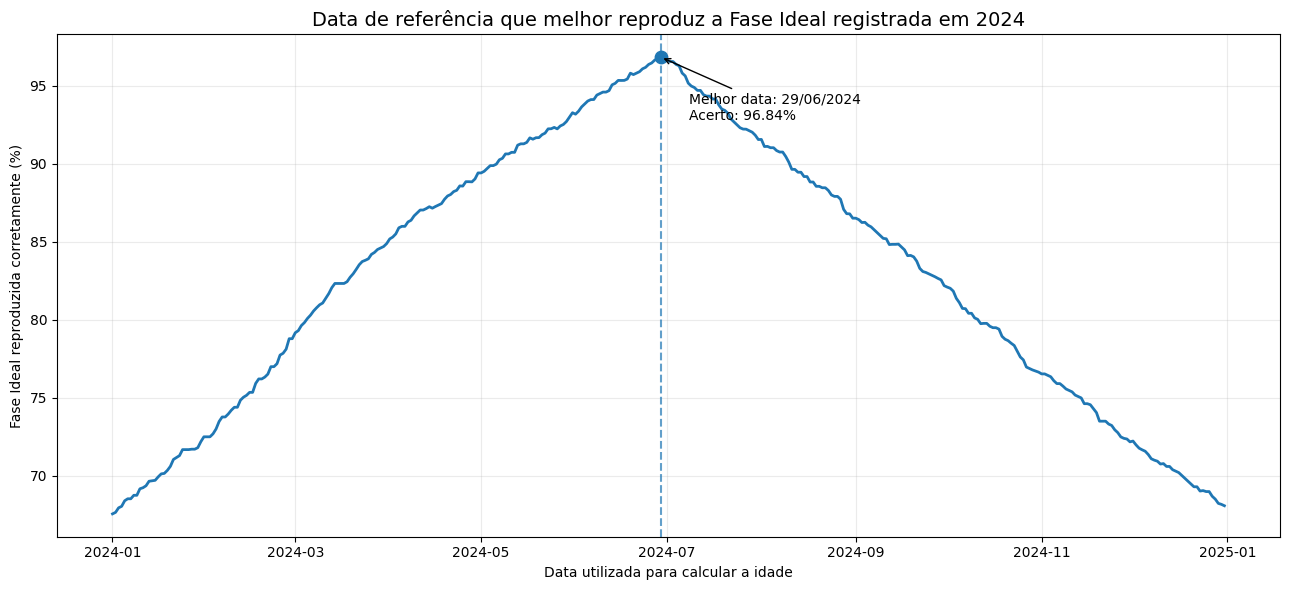

In [47]:
import matplotlib.pyplot as plt


melhor_linha = (
    resultado_data_corte
    .sort_values(
        "Pct_acerto",
        ascending=False
    )
    .iloc[0]
)

melhor_data = melhor_linha["Data_referencia"]
melhor_pct = melhor_linha["Pct_acerto"]


fig, ax = plt.subplots(
    figsize=(13, 6)
)

ax.plot(
    resultado_data_corte["Data_referencia"],
    resultado_data_corte["Pct_acerto"],
    linewidth=2
)

ax.axvline(
    melhor_data,
    linestyle="--",
    alpha=0.7
)

ax.scatter(
    [melhor_data],
    [melhor_pct],
    s=80,
    zorder=3
)

ax.annotate(
    (
        f"Melhor data: "
        f"{melhor_data:%d/%m/%Y}\n"
        f"Acerto: {melhor_pct:.2f}%"
    ),
    xy=(melhor_data, melhor_pct),
    xytext=(20, -45),
    textcoords="offset points",
    arrowprops={
        "arrowstyle": "->"
    }
)

ax.set_title(
    "Data de referência que melhor reproduz a Fase Ideal registrada em 2024",
    fontsize=14
)

ax.set_xlabel(
    "Data utilizada para calcular a idade"
)

ax.set_ylabel(
    "Fase Ideal reproduzida corretamente (%)"
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    OUTPUTS_DIR /
    "auditoria_data_referencia_fase_ideal_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretação — possível data de referência da Fase Ideal

A análise testou todas as datas de 2024 como possíveis referências para o cálculo
da idade utilizada na determinação da Fase Ideal.

O resultado apresentou um padrão bastante definido.

A concordância aumenta progressivamente durante o primeiro semestre, atinge seu
máximo no final de junho e começa a diminuir no segundo semestre.

As datas de **29/06/2024 e 30/06/2024** apresentaram a maior concordância:

- **1.041 classificações reproduzidas corretamente**
- **1.075 registros auditáveis**
- **96,84% de concordância**

Esse resultado reforça a hipótese de que a Fase Ideal de 2024 tenha sido determinada
utilizando uma idade de referência próxima ao **encerramento do primeiro semestre**,
em vez da idade registrada posteriormente na base.

Entretanto, a análise não permite afirmar que 30/06 seja formalmente a regra oficial
da instituição, pois essa data de corte não está explicitada na documentação disponível.

Por isso, `30/06/2024` será utilizada inicialmente como **hipótese operacional de
auditoria**, e não como correção definitiva.

O próximo passo será investigar os registros que permanecem divergentes mesmo após
a adoção dessa referência.

## 3.7 Casos não explicados pela hipótese de corte semestral

A utilização de 30/06/2024 como data de referência reproduz 96,84% das Fases Ideais
auditáveis.

Isso indica que grande parte das divergências inicialmente encontradas pode estar
relacionada ao momento em que a idade do estudante foi considerada.

Ainda assim, existem registros que permanecem incompatíveis com essa hipótese.

Esses casos serão analisados individualmente antes da definição da regra final de
tratamento.

Nenhuma correção será aplicada automaticamente.

In [48]:
# Reconstruir fase ideal em 30/06

DATA_CORTE_AUDITORIA = pd.Timestamp("2024-06-30")


auditoria_cutoff_2024 = df_2024_raw.copy()


# ============================================================
# DATA DE NASCIMENTO
# ============================================================

auditoria_cutoff_2024["DATA_NASCIMENTO_AUDIT"] = pd.to_datetime(
    auditoria_cutoff_2024["Data de Nasc"],
    errors="coerce"
)


# ============================================================
# IDADE EM 30/06/2024
# ============================================================

auditoria_cutoff_2024["IDADE_30JUN_AUDIT"] = (
    auditoria_cutoff_2024["DATA_NASCIMENTO_AUDIT"]
    .apply(
        lambda nascimento:
        calcular_idade_na_data(
            nascimento,
            DATA_CORTE_AUDITORIA
        )
    )
)


# ============================================================
# FASE IDEAL REGISTRADA
# ============================================================

auditoria_cutoff_2024["FASE_IDEAL_REG_NUM"] = (
    auditoria_cutoff_2024["Fase Ideal"]
    .apply(extrair_numero_fase)
)


# ============================================================
# FASE IDEAL ESPERADA EM 30/06
# ============================================================

auditoria_cutoff_2024["FASE_IDEAL_30JUN_AUDIT"] = (
    auditoria_cutoff_2024["IDADE_30JUN_AUDIT"]
    .apply(fase_ideal_documentada_por_idade)
)


# ============================================================
# CASOS AUDITÁVEIS
# ============================================================

auditoria_cutoff_2024["AUDITAVEL_30JUN"] = (
    auditoria_cutoff_2024["FASE_IDEAL_30JUN_AUDIT"].notna()
    &
    auditoria_cutoff_2024["FASE_IDEAL_REG_NUM"].notna()
)


# ============================================================
# CONSISTÊNCIA
# ============================================================

auditoria_cutoff_2024["COERENTE_30JUN"] = np.where(
    auditoria_cutoff_2024["AUDITAVEL_30JUN"],
    (
        auditoria_cutoff_2024["FASE_IDEAL_REG_NUM"]
        ==
        auditoria_cutoff_2024["FASE_IDEAL_30JUN_AUDIT"]
    ),
    pd.NA
)


# ============================================================
# DISTÂNCIA ENTRE FASES
# ============================================================

auditoria_cutoff_2024["DELTA_FASE_30JUN"] = (
    auditoria_cutoff_2024["FASE_IDEAL_REG_NUM"]
    -
    auditoria_cutoff_2024["FASE_IDEAL_30JUN_AUDIT"]
)

In [49]:
# confirmar os numeros

auditaveis_30jun = auditoria_cutoff_2024.loc[
    auditoria_cutoff_2024["AUDITAVEL_30JUN"]
].copy()

n_consistentes = (
    auditaveis_30jun["COERENTE_30JUN"]
    .eq(True)
    .sum()
)

n_inconsistentes = (
    auditaveis_30jun["COERENTE_30JUN"]
    .eq(False)
    .sum()
)


print("=" * 70)
print("AUDITORIA COM DATA DE REFERÊNCIA — 30/06/2024")
print("=" * 70)

print(f"Registros auditáveis : {len(auditaveis_30jun):,}")
print(f"Consistentes         : {n_consistentes:,}")
print(f"Inconsistentes       : {n_inconsistentes:,}")

print(
    f"Taxa de concordância : "
    f"{n_consistentes / len(auditaveis_30jun) * 100:.2f}%"
)

AUDITORIA COM DATA DE REFERÊNCIA — 30/06/2024
Registros auditáveis : 1,075
Consistentes         : 1,041
Inconsistentes       : 34
Taxa de concordância : 96.84%


In [50]:
# descobrir os casos restantes

divergencias_cutoff_2024 = auditoria_cutoff_2024.loc[
    auditoria_cutoff_2024["COERENTE_30JUN"].eq(False)
].copy()


colunas_divergencias = [
    "RA",
    "Data de Nasc",
    "Idade",
    "IDADE_30JUN_AUDIT",
    "Fase",
    "Fase Ideal",
    "FASE_IDEAL_REG_NUM",
    "FASE_IDEAL_30JUN_AUDIT",
    "DELTA_FASE_30JUN",
    "Defasagem",
    "IAN"
]


print(
    f"Casos ainda divergentes: "
    f"{len(divergencias_cutoff_2024)}"
)

display(
    divergencias_cutoff_2024[
        colunas_divergencias
    ]
)

Casos ainda divergentes: 34


,RA,Data de Nasc,Idade,IDADE_30JUN_AUDIT,Fase,Fase Ideal,FASE_IDEAL_REG_NUM,FASE_IDEAL_30JUN_AUDIT,DELTA_FASE_30JUN,Defasagem,IAN
23,RA-1289,2014-04-15 00:00:00,10,10,ALFA,Fase 1 (3° e 4° ano),1,2.0,-1.0,-1,5.0
107,RA-938,2014-06-01 00:00:00,10,10,ALFA,Fase 1 (3° e 4° ano),1,2.0,-1.0,-1,5.0
171,RA-1371,2013-06-26 00:00:00,11,11,ALFA,Fase 1 (3° e 4° ano),1,2.0,-1.0,-1,5.0
211,RA-871,2014-06-21 00:00:00,10,10,1B,Fase 1 (3° e 4° ano),1,2.0,-1.0,0,10.0
269,RA-840,2014-02-02 00:00:00,10,10,1G,Fase 1 (3° e 4° ano),1,2.0,-1.0,0,10.0
272,RA-927,2014-06-11 00:00:00,10,10,1G,Fase 1 (3° e 4° ano),1,2.0,-1.0,0,10.0
384,RA-1048,2013-07-20 00:00:00,11,10,2A,Fase 1 (3° e 4° ano),1,2.0,-1.0,1,10.0
396,RA-497,2009-07-01 00:00:00,15,14,2B,Fase 3 (7° e 8° ano),3,4.0,-1.0,-1,5.0
512,RA-1497,2012-05-18 00:00:00,12,12,2M,Fase 2 (5° e 6° ano),2,3.0,-1.0,0,10.0
565,RA-819,2014-05-24 00:00:00,10,10,2U,Fase 1 (3° e 4° ano),1,2.0,-1.0,1,10.0


In [51]:
resumo_divergencias_cutoff = (
    divergencias_cutoff_2024
    .groupby(
        [
            "IDADE_30JUN_AUDIT",
            "FASE_IDEAL_REG_NUM",
            "FASE_IDEAL_30JUN_AUDIT",
            "DELTA_FASE_30JUN"
        ],
        dropna=False
    )
    .size()
    .reset_index(name="Quantidade")
    .sort_values(
        "Quantidade",
        ascending=False
    )
)

display(resumo_divergencias_cutoff)

,IDADE_30JUN_AUDIT,FASE_IDEAL_REG_NUM,FASE_IDEAL_30JUN_AUDIT,DELTA_FASE_30JUN,Quantidade
0,10,1,2.0,-1.0,7
10,18,7,8.0,-1.0,6
4,14,3,4.0,-1.0,6
8,16,5,6.0,-1.0,4
7,15,4,5.0,-1.0,3
5,14,5,4.0,1.0,2
2,12,2,3.0,-1.0,2
1,11,1,2.0,-1.0,1
3,13,2,3.0,-1.0,1
6,15,3,5.0,-2.0,1


In [52]:
# cruzar com os quatro retrocessos


ras_retrocesso = set(
    retrocessos_fase_ideal["RA"]
)

divergencias_cutoff_2024["RETROCEDEU_23_24"] = (
    divergencias_cutoff_2024["RA"]
    .isin(ras_retrocesso)
)

print(
    "Divergências de 30/06 que também "
    "retrocederam entre 2023 e 2024:"
)

display(
    divergencias_cutoff_2024.loc[
        divergencias_cutoff_2024["RETROCEDEU_23_24"],
        colunas_divergencias
    ]
)

Divergências de 30/06 que também retrocederam entre 2023 e 2024:


,RA,Data de Nasc,Idade,IDADE_30JUN_AUDIT,Fase,Fase Ideal,FASE_IDEAL_REG_NUM,FASE_IDEAL_30JUN_AUDIT,DELTA_FASE_30JUN,Defasagem,IAN
384,RA-1048,2013-07-20,11,10,2A,Fase 1 (3° e 4° ano),1,2.0,-1.0,1,10.0
396,RA-497,2009-07-01,15,14,2B,Fase 3 (7° e 8° ano),3,4.0,-1.0,-1,5.0
783,RA-332,2009-05-06,15,15,4A,Fase 3 (7° e 8° ano),3,5.0,-2.0,1,10.0
1025,RA-78,2005-09-03,19,18,7A,Fase 7 (3° EM),7,8.0,-1.0,0,10.0


## 3.8 Política final de tratamento das inconsistências

A auditoria mostrou que a utilização de 30/06/2024 como referência etária
reproduz 96,84% das Fases Ideais auditáveis, restando apenas 34 casos divergentes.

Entretanto, a data de corte não está formalmente documentada nos materiais
disponíveis. Por isso, esses 34 casos não serão corrigidos automaticamente.

Foi adotada uma estratégia conservadora:

1. preservar integralmente os valores originais;
2. criar variáveis específicas para análise;
3. corrigir automaticamente apenas inconsistências matemáticas inequívocas;
4. corrigir a Fase Ideal somente quando múltiplas evidências independentes
   apontarem para a mesma inconsistência;
5. manter os demais casos divergentes sinalizados, sem alteração.

### Casos de forte evidência longitudinal

Quatro alunos apresentam simultaneamente:

- divergência em relação à fase esperada na referência de 30/06;
- redução da Fase Ideal entre 2023 e 2024.

São eles:

`RA-1048`, `RA-497`, `RA-332` e `RA-78`.

Para esses casos será utilizada, exclusivamente nas variáveis analíticas,
a Fase Ideal correspondente à idade em 30/06/2024.

### Inconsistências matemáticas

Também foram identificados dois registros nos quais:

\[
Fase - FaseIdeal \neq Defasagem
\]

(`RA-1516` e `RA-1519`).

A variável analítica de defasagem será sempre recalculada a partir das fases,
eliminando esse tipo de inconsistência.

> Os campos originais continuarão disponíveis para rastreabilidade e auditoria.

In [53]:
# ============================================================
# CÓPIAS PARA TRATAMENTO
# ============================================================

df_2022 = df_2022_raw.copy()
df_2023 = df_2023_raw.copy()
df_2024 = df_2024_raw.copy()


# ============================================================
# 1. FASE NUMÉRICA PADRONIZADA
# ============================================================

df_2022["FASE_NUM"] = (
    df_2022["Fase"]
    .apply(extrair_numero_fase)
)

df_2023["FASE_NUM"] = (
    df_2023["Fase"]
    .apply(extrair_numero_fase)
)

df_2024["FASE_NUM"] = (
    df_2024["Fase"]
    .apply(extrair_numero_fase)
)


# ============================================================
# 2. FASE IDEAL ORIGINAL EM FORMATO NUMÉRICO
# ============================================================

df_2022["FASE_IDEAL_ORIGINAL_NUM"] = (
    df_2022["Fase ideal"]
    .apply(extrair_numero_fase)
)

df_2023["FASE_IDEAL_ORIGINAL_NUM"] = (
    df_2023["Fase Ideal"]
    .apply(extrair_numero_fase)
)

df_2024["FASE_IDEAL_ORIGINAL_NUM"] = (
    df_2024["Fase Ideal"]
    .apply(extrair_numero_fase)
)


# ============================================================
# 3. PRESERVAR INDICADORES ORIGINAIS
# ============================================================

df_2022["DEFASAGEM_ORIGINAL"] = df_2022["Defas"]
df_2023["DEFASAGEM_ORIGINAL"] = df_2023["Defasagem"]
df_2024["DEFASAGEM_ORIGINAL"] = df_2024["Defasagem"]

df_2022["IAN_ORIGINAL"] = df_2022["IAN"]
df_2023["IAN_ORIGINAL"] = df_2023["IAN"]
df_2024["IAN_ORIGINAL"] = df_2024["IAN"]


# ============================================================
# 4. FASE IDEAL UTILIZADA NA ANÁLISE
# ============================================================

# 2022 e 2023: auditoria não encontrou inconsistências relevantes.
df_2022["FASE_IDEAL_ANALISE"] = (
    df_2022["FASE_IDEAL_ORIGINAL_NUM"]
)

df_2023["FASE_IDEAL_ANALISE"] = (
    df_2023["FASE_IDEAL_ORIGINAL_NUM"]
)

# 2024 começa preservando o valor oficial.
df_2024["FASE_IDEAL_ANALISE"] = (
    df_2024["FASE_IDEAL_ORIGINAL_NUM"]
)


# ============================================================
# 5. AUDITORIA DE IDADE EM 30/06/2024
# ============================================================

DATA_CORTE_AUDITORIA = pd.Timestamp("2024-06-30")

df_2024["DATA_NASCIMENTO"] = pd.to_datetime(
    df_2024["Data de Nasc"],
    errors="coerce"
)

df_2024["IDADE_30JUN"] = (
    df_2024["DATA_NASCIMENTO"]
    .apply(
        lambda nascimento:
        calcular_idade_na_data(
            nascimento,
            DATA_CORTE_AUDITORIA
        )
    )
)

df_2024["FASE_IDEAL_30JUN"] = (
    df_2024["IDADE_30JUN"]
    .apply(fase_ideal_documentada_por_idade)
)


# ============================================================
# 6. FLAG DE DIVERGÊNCIA DA FASE IDEAL
# ============================================================

df_2024["FLAG_FASE_IDEAL_DIVERGENTE"] = (
    df_2024["FASE_IDEAL_30JUN"].notna()
    &
    (
        df_2024["FASE_IDEAL_ORIGINAL_NUM"]
        !=
        df_2024["FASE_IDEAL_30JUN"]
    )
)


# ============================================================
# 7. CASOS COM EVIDÊNCIA FORTE
# ============================================================

RAS_CORRECAO_FASE_IDEAL = {
    "RA-1048",
    "RA-497",
    "RA-332",
    "RA-78"
}

mask_correcao_fase = (
    df_2024["RA"]
    .astype(str)
    .str.strip()
    .isin(RAS_CORRECAO_FASE_IDEAL)
)


df_2024.loc[
    mask_correcao_fase,
    "FASE_IDEAL_ANALISE"
] = df_2024.loc[
    mask_correcao_fase,
    "FASE_IDEAL_30JUN"
]


df_2024["FLAG_FASE_IDEAL_CORRIGIDA"] = (
    mask_correcao_fase
)


# ============================================================
# 8. RECALCULAR DEFASAGEM ANALÍTICA
# ============================================================

for df in [df_2022, df_2023, df_2024]:

    df["DEFASAGEM_ANALISE"] = (
        df["FASE_NUM"]
        -
        df["FASE_IDEAL_ANALISE"]
    )


# ============================================================
# 9. RECALCULAR IAN ANALÍTICO
# ============================================================

for df in [df_2022, df_2023, df_2024]:

    df["IAN_ANALISE"] = (
        df["DEFASAGEM_ANALISE"]
        .apply(calcular_ian_por_defasagem)
    )


print("✅ Variáveis analíticas criadas.")

✅ Variáveis analíticas criadas.


In [54]:
resumo_tratamento = pd.DataFrame({
    "Indicador": [
        "Registros 2024",
        "Fase Ideal divergente de 30/06",
        "Fase Ideal efetivamente corrigida",
        "Defasagem alterada após tratamento",
        "IAN alterado após tratamento"
    ],
    "Quantidade": [
        len(df_2024),

        df_2024[
            "FLAG_FASE_IDEAL_DIVERGENTE"
        ].sum(),

        df_2024[
            "FLAG_FASE_IDEAL_CORRIGIDA"
        ].sum(),

        (
            df_2024["DEFASAGEM_ANALISE"]
            != df_2024["DEFASAGEM_ORIGINAL"]
        ).sum(),

        (
            df_2024["IAN_ANALISE"]
            != df_2024["IAN_ORIGINAL"]
        ).sum()
    ]
})

display(resumo_tratamento)

,Indicador,Quantidade
0,Registros 2024,1156
1,Fase Ideal divergente de 30/06,34
2,Fase Ideal efetivamente corrigida,4
3,Defasagem alterada após tratamento,6
4,IAN alterado após tratamento,2


In [55]:
casos_alterados = df_2024.loc[
    (
        df_2024["DEFASAGEM_ANALISE"]
        != df_2024["DEFASAGEM_ORIGINAL"]
    )
    |
    (
        df_2024["IAN_ANALISE"]
        != df_2024["IAN_ORIGINAL"]
    ),
    [
        "RA",
        "Idade",
        "IDADE_30JUN",
        "Fase",
        "FASE_NUM",
        "Fase Ideal",
        "FASE_IDEAL_ORIGINAL_NUM",
        "FASE_IDEAL_ANALISE",
        "DEFASAGEM_ORIGINAL",
        "DEFASAGEM_ANALISE",
        "IAN_ORIGINAL",
        "IAN_ANALISE",
        "FLAG_FASE_IDEAL_DIVERGENTE",
        "FLAG_FASE_IDEAL_CORRIGIDA"
    ]
].copy()

display(casos_alterados)

,RA,Idade,IDADE_30JUN,Fase,FASE_NUM,Fase Ideal,FASE_IDEAL_ORIGINAL_NUM,FASE_IDEAL_ANALISE,DEFASAGEM_ORIGINAL,DEFASAGEM_ANALISE,IAN_ORIGINAL,IAN_ANALISE,FLAG_FASE_IDEAL_DIVERGENTE,FLAG_FASE_IDEAL_CORRIGIDA
384,RA-1048,11,10,2A,2,Fase 1 (3° e 4° ano),1,2,1,0,10.0,10.0,True,True
396,RA-497,15,14,2B,2,Fase 3 (7° e 8° ano),3,4,-1,-2,5.0,5.0,True,True
570,RA-1516,13,13,3A,3,Fase 3 (7° e 8° ano),3,3,3,0,10.0,10.0,False,False
578,RA-1519,15,14,3A,3,Fase 3 (7° e 8° ano),3,3,3,0,10.0,10.0,True,False
783,RA-332,15,15,4A,4,Fase 3 (7° e 8° ano),3,5,1,-1,10.0,5.0,True,True
1025,RA-78,19,18,7A,7,Fase 7 (3° EM),7,8,0,-1,10.0,5.0,True,True


## 3.9 Impacto final do tratamento

A estratégia de tratamento adotada foi deliberadamente conservadora.

Entre os **1.156 registros de 2024**:

- 34 apresentaram divergência em relação à hipótese de referência em 30/06;
- apenas 4 tiveram a Fase Ideal ajustada por apresentarem múltiplas evidências
  de inconsistência;
- 6 registros tiveram alteração na defasagem analítica;
- somente 2 registros tiveram mudança efetiva no IAN.

Assim, a defasagem foi alterada em aproximadamente **0,52% da base de 2024**,
enquanto a classificação do IAN mudou em apenas **0,17% dos registros**.

Essa baixa proporção mostra que o tratamento não teve como objetivo reclassificar
massivamente os estudantes, mas corrigir inconsistências com evidência suficiente.

Os valores oficiais permanecem preservados nas variáveis originais, permitindo
rastreabilidade completa entre:

**valor original → regra de auditoria → valor analítico utilizado.**

A partir deste ponto, as análises utilizarão:

- `FASE_NUM`
- `FASE_IDEAL_ANALISE`
- `DEFASAGEM_ANALISE`
- `IAN_ANALISE`

Os campos originais continuarão disponíveis para comparação e auditoria.

In [56]:
# ============================================================
# VALIDAÇÕES FINAIS DA BASE ANALÍTICA
# ============================================================

validacoes = []

for ano, df in [
    (2022, df_2022),
    (2023, df_2023),
    (2024, df_2024)
]:

    # --------------------------------------------------------
    # RA
    # --------------------------------------------------------

    ra_nulos = int(df["RA"].isna().sum())
    ra_duplicados = int(df["RA"].duplicated().sum())

    # --------------------------------------------------------
    # Defasagem
    # FASE_NUM - FASE_IDEAL_ANALISE
    # --------------------------------------------------------

    defasagem_recalculada = (
        df["FASE_NUM"]
        -
        df["FASE_IDEAL_ANALISE"]
    )

    erros_defasagem = int(
        (
            df["DEFASAGEM_ANALISE"]
            != defasagem_recalculada
        ).sum()
    )

    # --------------------------------------------------------
    # IAN
    # --------------------------------------------------------

    ian_recalculado = (
        df["DEFASAGEM_ANALISE"]
        .apply(calcular_ian_por_defasagem)
    )

    erros_ian = int(
        (
            df["IAN_ANALISE"]
            != ian_recalculado
        ).sum()
    )

    # --------------------------------------------------------
    # Nulos nas variáveis estruturais analíticas
    # --------------------------------------------------------

    nulos_fase = int(
        df["FASE_NUM"].isna().sum()
    )

    nulos_fase_ideal = int(
        df["FASE_IDEAL_ANALISE"].isna().sum()
    )

    nulos_defasagem = int(
        df["DEFASAGEM_ANALISE"].isna().sum()
    )

    nulos_ian = int(
        df["IAN_ANALISE"].isna().sum()
    )

    validacoes.append({
        "Ano": ano,
        "Registros": len(df),
        "RA_nulos": ra_nulos,
        "RA_duplicados": ra_duplicados,
        "Fase_num_nulos": nulos_fase,
        "Fase_ideal_nulos": nulos_fase_ideal,
        "Defasagem_nulos": nulos_defasagem,
        "IAN_nulos": nulos_ian,
        "Erro_formula_defasagem": erros_defasagem,
        "Erro_regra_IAN": erros_ian
    })


validacao_final = pd.DataFrame(validacoes)

display(validacao_final)

,Ano,Registros,RA_nulos,RA_duplicados,Fase_num_nulos,Fase_ideal_nulos,Defasagem_nulos,IAN_nulos,Erro_formula_defasagem,Erro_regra_IAN
0,2022,860,0,0,0,0,0,0,0,0
1,2023,1014,0,0,0,0,0,0,0,0
2,2024,1156,0,0,0,0,0,0,0,0


## 3.10 Encerramento da auditoria e validação da base analítica

Após a padronização e os tratamentos conservadores, a base analítica foi submetida
a uma validação automática nos três períodos.

Os testes confirmaram:

- ausência de valores nulos em RA, fase, fase ideal, defasagem e IAN analíticos;
- ausência de duplicidades de RA dentro de cada ano;
- 100% de consistência entre `Fase - Fase Ideal` e a defasagem analítica;
- 100% de consistência entre a defasagem analítica e a regra do IAN.

A validação foi concluída sem erros em:

- **860 registros de 2022**
- **1.014 registros de 2023**
- **1.156 registros de 2024**

Com isso, a etapa de auditoria e preparação dos dados é considerada concluída.

A partir deste ponto, as análises exploratórias utilizarão exclusivamente as
variáveis analíticas validadas, mantendo os campos originais disponíveis para
rastreabilidade.

In [57]:
# ============================================================
# SALVAR BASES ANALÍTICAS
# ============================================================

arquivos_saida = {
    2022: PROCESSED_DIR / "pede_2022_clean.csv",
    2023: PROCESSED_DIR / "pede_2023_clean.csv",
    2024: PROCESSED_DIR / "pede_2024_clean.csv"
}

for ano, df in [
    (2022, df_2022),
    (2023, df_2023),
    (2024, df_2024)
]:

    caminho = arquivos_saida[ano]

    df.to_csv(
        caminho,
        index=False,
        encoding="utf-8-sig"
    )

    print(
        f"✅ {ano}: "
        f"{len(df):,} registros → {caminho.name}"
    )

print("\nArquivos gravados em:")
print(PROCESSED_DIR)

✅ 2022: 860 registros → pede_2022_clean.csv
✅ 2023: 1,014 registros → pede_2023_clean.csv
✅ 2024: 1,156 registros → pede_2024_clean.csv

Arquivos gravados em:
/content/drive/MyDrive/FIAP/Datathon_Passos_Magicos/data/processed


In [58]:
# Salvar auditoria

audit_file = (
    OUTPUTS_DIR /
    "auditoria_inconsistencias_2024.csv"
)

divergencias_cutoff_2024.to_csv(
    audit_file,
    index=False,
    encoding="utf-8-sig"
)

print(
    "✅ Auditoria salva:",
    audit_file
)

✅ Auditoria salva: /content/drive/MyDrive/FIAP/Datathon_Passos_Magicos/outputs/auditoria_inconsistencias_2024.csv


# 4. Pergunta 1 — Como evoluiu o perfil de defasagem dos alunos?

A defasagem representa a distância entre a fase em que o aluno se encontra e
a fase considerada ideal para sua trajetória educacional.

Para tornar a leitura gerencial mais clara, os alunos serão classificados em
três grupos:

- **Sem defasagem:** defasagem maior ou igual a zero;
- **Defasagem moderada:** defasagem igual a -1 ou -2;
- **Defasagem severa:** defasagem inferior a -2.

O objetivo desta análise é responder:

> A proporção de alunos em situação de defasagem aumentou ou diminuiu entre
> 2022 e 2024?

Primeiro será analisada a população total de cada ano. Posteriormente, a análise
será repetida apenas com alunos acompanhados longitudinalmente, evitando confundir
mudanças reais na trajetória dos estudantes com mudanças na composição da base.

In [59]:
# Criar classificação

def classificar_defasagem(valor):
    """
    Classifica a defasagem em três níveis de risco.
    """

    if pd.isna(valor):
        return np.nan

    if valor >= 0:
        return "Sem defasagem"

    if valor >= -2:
        return "Defasagem moderada"

    return "Defasagem severa"

In [60]:
for df in [df_2022, df_2023, df_2024]:
    df["STATUS_DEFASAGEM"] = (
        df["DEFASAGEM_ANALISE"]
        .apply(classificar_defasagem)
    )

In [61]:
# tabela quantidade e percentual

bases_anuais = {
    2022: df_2022,
    2023: df_2023,
    2024: df_2024
}

ordem_status = [
    "Sem defasagem",
    "Defasagem moderada",
    "Defasagem severa"
]

resultados = []

for ano, df in bases_anuais.items():

    contagem = (
        df["STATUS_DEFASAGEM"]
        .value_counts()
        .reindex(ordem_status, fill_value=0)
    )

    total = len(df)

    for status in ordem_status:

        quantidade = int(contagem[status])

        resultados.append({
            "Ano": ano,
            "Status": status,
            "Quantidade": quantidade,
            "Percentual": quantidade / total * 100
        })


resumo_defasagem = pd.DataFrame(resultados)

resumo_defasagem["Percentual"] = (
    resumo_defasagem["Percentual"]
    .round(2)
)

display(resumo_defasagem)

,Ano,Status,Quantidade,Percentual
0,2022,Sem defasagem,259,30.12
1,2022,Defasagem moderada,573,66.63
2,2022,Defasagem severa,28,3.26
3,2023,Sem defasagem,462,45.56
4,2023,Defasagem moderada,538,53.06
5,2023,Defasagem severa,14,1.38
6,2024,Sem defasagem,620,53.63
7,2024,Defasagem moderada,533,46.11
8,2024,Defasagem severa,3,0.26


In [62]:
tabela_defasagem = (
    resumo_defasagem
    .pivot(
        index="Ano",
        columns="Status",
        values="Percentual"
    )
    .reindex(columns=ordem_status)
)

display(tabela_defasagem)

Status,Sem defasagem,Defasagem moderada,Defasagem severa
Ano,,,
2022,30.12,66.63,3.26
2023,45.56,53.06,1.38
2024,53.63,46.11,0.26


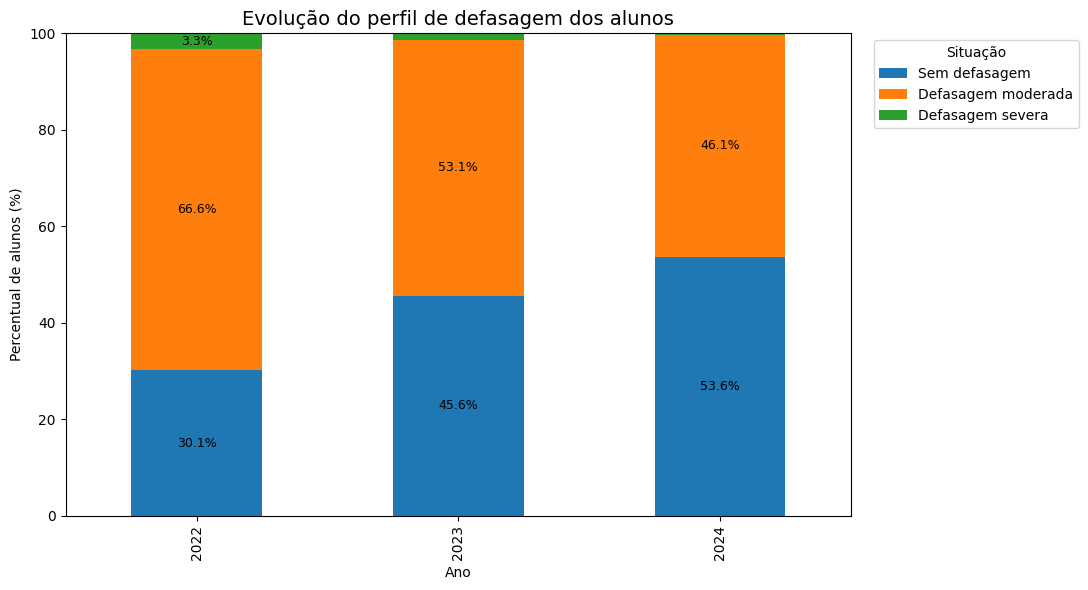

In [63]:
import matplotlib.pyplot as plt

grafico_defasagem = (
    resumo_defasagem
    .pivot(
        index="Ano",
        columns="Status",
        values="Percentual"
    )
    .reindex(columns=ordem_status)
)

ax = grafico_defasagem.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)

ax.set_title(
    "Evolução do perfil de defasagem dos alunos",
    fontsize=14
)

ax.set_xlabel("Ano")
ax.set_ylabel("Percentual de alunos (%)")

ax.legend(
    title="Situação",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.set_ylim(0, 100)

# Rótulos dentro das barras
for container in ax.containers:
    labels = [
        f"{valor:.1f}%"
        if valor >= 3
        else ""
        for valor in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    OUTPUTS_DIR /
    "pergunta_01_evolucao_perfil_defasagem.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [64]:
# taxa total de alunos em risco


taxa_risco = (
    resumo_defasagem.loc[
        resumo_defasagem["Status"] != "Sem defasagem"
    ]
    .groupby("Ano", as_index=False)
    .agg(
        Quantidade_em_risco=("Quantidade", "sum"),
        Percentual_em_risco=("Percentual", "sum")
    )
)

taxa_risco["Percentual_em_risco"] = (
    taxa_risco["Percentual_em_risco"]
    .round(2)
)

display(taxa_risco)

,Ano,Quantidade_em_risco,Percentual_em_risco
0,2022,601,69.89
1,2023,552,54.44
2,2024,536,46.37


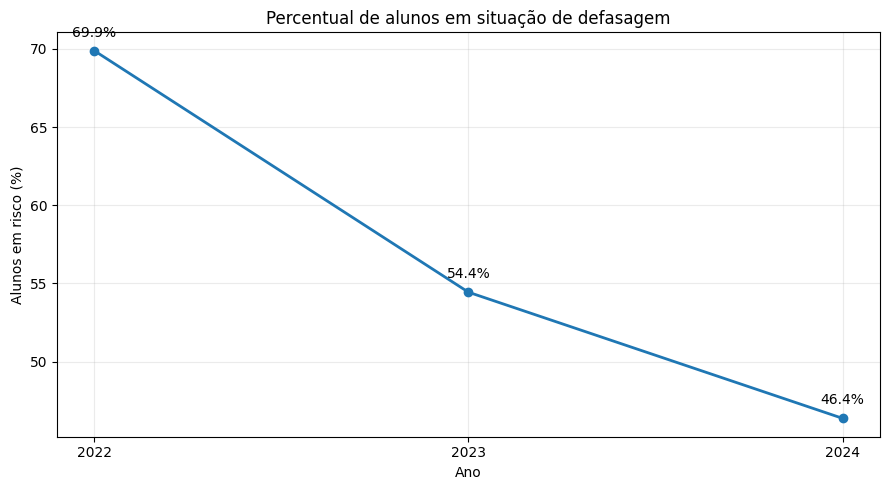

In [65]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    taxa_risco["Ano"],
    taxa_risco["Percentual_em_risco"],
    marker="o",
    linewidth=2
)

for _, linha in taxa_risco.iterrows():

    ax.annotate(
        f"{linha['Percentual_em_risco']:.1f}%",
        (
            linha["Ano"],
            linha["Percentual_em_risco"]
        ),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center"
    )

ax.set_title(
    "Percentual de alunos em situação de defasagem"
)

ax.set_xlabel("Ano")
ax.set_ylabel("Alunos em risco (%)")

ax.set_xticks(
    taxa_risco["Ano"]
)

ax.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    OUTPUTS_DIR /
    "pergunta_01_taxa_alunos_em_risco.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 4.1 Leitura executiva — evolução da defasagem

Os resultados indicam uma melhora consistente no perfil de adequação educacional
entre 2022 e 2024.

A proporção de alunos em situação de defasagem caiu de:

- **69,89% em 2022**
- **54,44% em 2023**
- **46,37% em 2024**

Isso representa uma redução de **23,52 pontos percentuais** no período.

Em sentido oposto, a proporção de alunos sem defasagem aumentou de **30,12% para
53,63%**, passando a representar a maioria da população avaliada em 2024.

A melhora também aparece nos casos mais críticos.

A defasagem severa caiu de:

- **3,26% em 2022**
- **1,38% em 2023**
- **0,26% em 2024**

Além da melhora proporcional, existe também uma redução absoluta no número de
alunos em risco: de **601 alunos em 2022 para 536 em 2024**, mesmo com o aumento
da população total avaliada no período.

### Insight gerencial

Os dados sugerem que o perfil educacional acompanhado pela Passos Mágicos está
se deslocando progressivamente para situações de maior adequação de nível.

Entretanto, essa análise é transversal: a população observada não é exatamente a
mesma em todos os anos.

Portanto, ainda não é possível atribuir essa melhora diretamente à evolução dos
mesmos estudantes ou ao efeito do programa.

A próxima análise investigará onde a defasagem está concentrada por fase e,
posteriormente, acompanhará os mesmos alunos ao longo do tempo.

## 4.2 Em quais fases a defasagem está mais concentrada?

Embora a taxa geral de defasagem tenha diminuído, uma média global pode esconder
grupos com maior vulnerabilidade.

Nesta etapa será calculada a proporção de alunos em risco dentro de cada fase,
permitindo identificar os pontos da trajetória educacional que demandam maior
atenção.

Para evitar distorções provocadas pelo tamanho diferente das turmas, a comparação
será realizada principalmente em percentual, e não apenas em números absolutos.

In [66]:
resultados_fase = []

for ano, df in bases_anuais.items():

    resumo = (
        df
        .groupby("FASE_NUM")
        .agg(
            Total=("RA", "size"),
            Em_risco=(
                "STATUS_DEFASAGEM",
                lambda s: (s != "Sem defasagem").sum()
            ),
            Severos=(
                "STATUS_DEFASAGEM",
                lambda s: (s == "Defasagem severa").sum()
            )
        )
        .reset_index()
    )

    resumo["Ano"] = ano

    resumo["Pct_risco"] = (
        resumo["Em_risco"]
        / resumo["Total"]
        * 100
    ).round(2)

    resumo["Pct_severo"] = (
        resumo["Severos"]
        / resumo["Total"]
        * 100
    ).round(2)

    resultados_fase.append(resumo)


risco_por_fase = pd.concat(
    resultados_fase,
    ignore_index=True
)

display(risco_por_fase)

,FASE_NUM,Total,Em_risco,Severos,Ano,Pct_risco,Pct_severo
0,0,190,121,1,2022,63.68,0.53
1,1,192,162,3,2022,84.38,1.56
2,2,155,111,1,2022,71.61,0.65
3,3,148,82,14,2022,55.41,9.46
4,4,76,50,7,2022,65.79,9.21
5,5,60,44,2,2022,73.33,3.33
6,6,18,15,0,2022,83.33,0.00
7,7,21,16,0,2022,76.19,0.00
8,0,231,117,1,2023,50.65,0.43
9,1,173,132,1,2023,76.30,0.58


In [67]:
tabela_risco_fase = (
    risco_por_fase
    .pivot(
        index="FASE_NUM",
        columns="Ano",
        values="Pct_risco"
    )
    .round(2)
)

tabela_risco_fase.index.name = "Fase"

display(tabela_risco_fase)

Ano,2022,2023,2024
Fase,,,
0,63.68,50.65,75.00
1,84.38,76.30,70.81
2,71.61,62.00,37.30
3,55.41,47.73,26.07
4,65.79,47.87,56.52
5,73.33,63.08,56.00
6,83.33,72.73,48.00
7,76.19,26.09,2.70
8,NaN,0.00,0.00


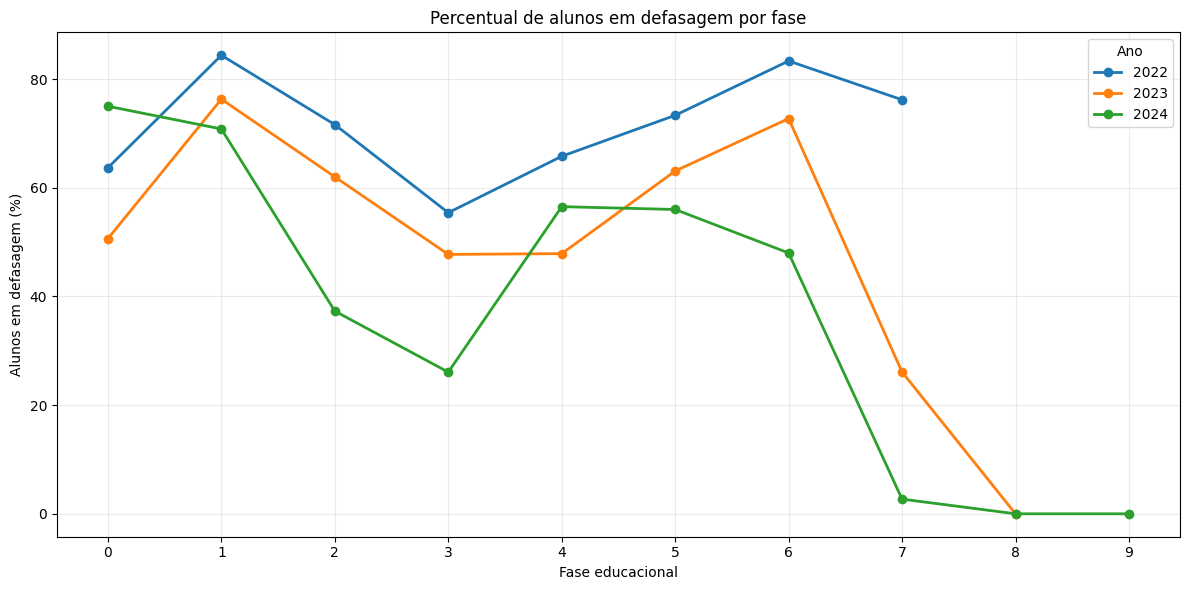

In [68]:
fig, ax = plt.subplots(
    figsize=(12, 6)
)

for ano in [2022, 2023, 2024]:

    dados_ano = risco_por_fase.loc[
        risco_por_fase["Ano"] == ano
    ].sort_values("FASE_NUM")

    ax.plot(
        dados_ano["FASE_NUM"],
        dados_ano["Pct_risco"],
        marker="o",
        linewidth=2,
        label=str(ano)
    )


ax.set_title(
    "Percentual de alunos em defasagem por fase"
)

ax.set_xlabel(
    "Fase educacional"
)

ax.set_ylabel(
    "Alunos em defasagem (%)"
)

ax.set_xticks(
    sorted(
        risco_por_fase["FASE_NUM"]
        .dropna()
        .unique()
    )
)

ax.legend(
    title="Ano"
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    OUTPUTS_DIR /
    "pergunta_01_risco_por_fase.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 4.2 Leitura executiva — onde a defasagem está concentrada?

A redução da defasagem observada entre 2022 e 2024 não ocorreu de forma uniforme
em todas as fases.

As maiores melhorias aparecem principalmente nas fases intermediárias e finais.

Alguns exemplos:

- **Fase 2:** 71,61% em 2022 → 37,30% em 2024;
- **Fase 3:** 55,41% → 26,07%;
- **Fase 6:** 83,33% → 48,00%;
- **Fase 7:** 76,19% → 2,70%.

Por outro lado, em 2024 o risco permanece especialmente elevado nas fases iniciais:

- **ALFA / Fase 0:** 75,00%;
- **Fase 1:** 70,81%.

Esse padrão sugere que, embora o cenário geral tenha melhorado, a entrada e os
primeiros estágios da trajetória educacional continuam concentrando uma parcela
relevante dos alunos em defasagem.

### Insight gerencial

A análise indica que uma estratégia única para todos os alunos pode não ser a
abordagem mais eficiente.

As fases iniciais parecem demandar maior atenção preventiva, enquanto determinadas
fases intermediárias apresentam sinais claros de redução do risco ao longo do período.

As Fases 8 e 9 devem ser interpretadas separadamente, pois representam alunos em
contexto universitário ou pós-escolar e possuem dinâmica diferente das fases escolares.

## 4.3 A melhora também acontece nos mesmos alunos?

As análises anteriores comparam a população total de cada ano.

Como novos alunos entram no programa e outros deixam de aparecer nas bases, parte da
melhora observada pode decorrer de mudanças na composição da população.

Para verificar se existe evolução real na trajetória individual, será analisado um
grupo longitudinal formado pelos **468 alunos presentes em 2022, 2023 e 2024**.

A pergunta passa a ser:

> Entre os mesmos estudantes, a situação de defasagem melhora, permanece estável
> ou piora ao longo do tempo?

In [69]:
# ============================================================
# ALUNOS PRESENTES NOS TRÊS ANOS
# ============================================================

ras_longitudinais = (
    set(df_2022["RA"])
    &
    set(df_2023["RA"])
    &
    set(df_2024["RA"])
)

print(
    f"Alunos presentes nos três anos: "
    f"{len(ras_longitudinais)}"
)

Alunos presentes nos três anos: 468


In [70]:
long_2022 = df_2022.loc[
    df_2022["RA"].isin(ras_longitudinais),
    [
        "RA",
        "DEFASAGEM_ANALISE",
        "IAN_ANALISE",
        "STATUS_DEFASAGEM"
    ]
].copy()

long_2022 = long_2022.rename(columns={
    "DEFASAGEM_ANALISE": "DEFASAGEM_2022",
    "IAN_ANALISE": "IAN_2022",
    "STATUS_DEFASAGEM": "STATUS_2022"
})


long_2023 = df_2023.loc[
    df_2023["RA"].isin(ras_longitudinais),
    [
        "RA",
        "DEFASAGEM_ANALISE",
        "IAN_ANALISE",
        "STATUS_DEFASAGEM"
    ]
].copy()

long_2023 = long_2023.rename(columns={
    "DEFASAGEM_ANALISE": "DEFASAGEM_2023",
    "IAN_ANALISE": "IAN_2023",
    "STATUS_DEFASAGEM": "STATUS_2023"
})


long_2024 = df_2024.loc[
    df_2024["RA"].isin(ras_longitudinais),
    [
        "RA",
        "DEFASAGEM_ANALISE",
        "IAN_ANALISE",
        "STATUS_DEFASAGEM"
    ]
].copy()

long_2024 = long_2024.rename(columns={
    "DEFASAGEM_ANALISE": "DEFASAGEM_2024",
    "IAN_ANALISE": "IAN_2024",
    "STATUS_DEFASAGEM": "STATUS_2024"
})


painel_longitudinal = (
    long_2022
    .merge(long_2023, on="RA", how="inner")
    .merge(long_2024, on="RA", how="inner")
)

print(
    f"Painel longitudinal final: "
    f"{len(painel_longitudinal)} alunos"
)

display(
    painel_longitudinal.head()
)

Painel longitudinal final: 468 alunos


,RA,DEFASAGEM_2022,IAN_2022,STATUS_2022,DEFASAGEM_2023,IAN_2023,STATUS_2023,DEFASAGEM_2024,IAN_2024,STATUS_2024
0,RA-1,-1,5.0,Defasagem moderada,0,10.0,Sem defasagem,0,10.0,Sem defasagem
1,RA-2,0,10.0,Sem defasagem,0,10.0,Sem defasagem,0,10.0,Sem defasagem
2,RA-6,-1,5.0,Defasagem moderada,0,10.0,Sem defasagem,0,10.0,Sem defasagem
3,RA-7,-1,5.0,Defasagem moderada,0,10.0,Sem defasagem,0,10.0,Sem defasagem
4,RA-12,0,10.0,Sem defasagem,0,10.0,Sem defasagem,0,10.0,Sem defasagem


In [71]:
resultados_longitudinais = []

for ano in [2022, 2023, 2024]:

    coluna_status = f"STATUS_{ano}"

    total = len(painel_longitudinal)

    em_risco = (
        painel_longitudinal[coluna_status]
        != "Sem defasagem"
    ).sum()

    severos = (
        painel_longitudinal[coluna_status]
        == "Defasagem severa"
    ).sum()

    resultados_longitudinais.append({
        "Ano": ano,
        "Total_alunos": total,
        "Em_risco": em_risco,
        "Pct_em_risco": round(
            em_risco / total * 100,
            2
        ),
        "Severos": severos,
        "Pct_severo": round(
            severos / total * 100,
            2
        )
    })


evolucao_longitudinal = pd.DataFrame(
    resultados_longitudinais
)

display(evolucao_longitudinal)

,Ano,Total_alunos,Em_risco,Pct_em_risco,Severos,Pct_severo
0,2022,468,315,67.31,7,1.50
1,2023,468,272,58.12,2,0.43
2,2024,468,165,35.26,2,0.43


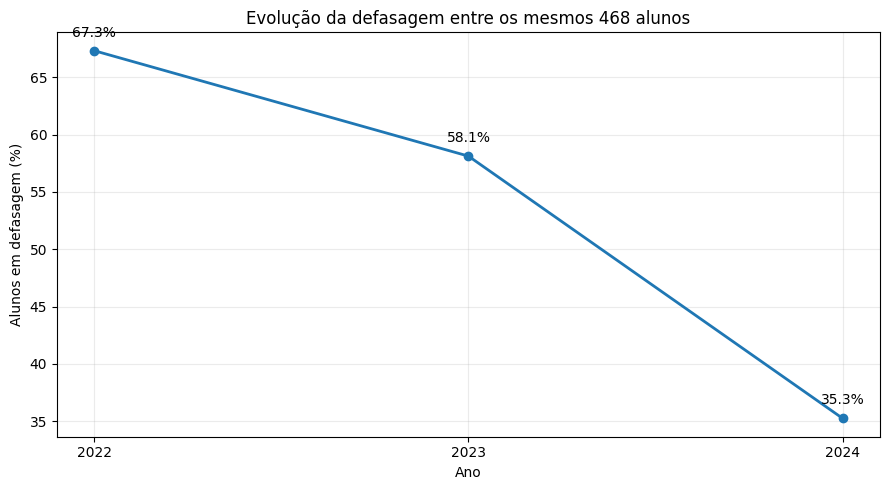

In [72]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    evolucao_longitudinal["Ano"],
    evolucao_longitudinal["Pct_em_risco"],
    marker="o",
    linewidth=2
)

for _, linha in evolucao_longitudinal.iterrows():

    ax.annotate(
        f"{linha['Pct_em_risco']:.1f}%",
        (
            linha["Ano"],
            linha["Pct_em_risco"]
        ),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center"
    )

ax.set_title(
    "Evolução da defasagem entre os mesmos 468 alunos"
)

ax.set_xlabel("Ano")
ax.set_ylabel("Alunos em defasagem (%)")

ax.set_xticks(
    [2022, 2023, 2024]
)

ax.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    OUTPUTS_DIR /
    "pergunta_01_longitudinal_defasagem.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [73]:
painel_longitudinal["DELTA_DEFASAGEM_22_24"] = (
    painel_longitudinal["DEFASAGEM_2024"]
    -
    painel_longitudinal["DEFASAGEM_2022"]
)

painel_longitudinal["EVOLUCAO_22_24"] = np.select(
    [
        painel_longitudinal["DELTA_DEFASAGEM_22_24"] > 0,
        painel_longitudinal["DELTA_DEFASAGEM_22_24"] == 0,
        painel_longitudinal["DELTA_DEFASAGEM_22_24"] < 0
    ],
    [
        "Melhorou",
        "Manteve",
        "Piorou"
    ],
    default="Indefinido"
)

resumo_evolucao_individual = (
    painel_longitudinal["EVOLUCAO_22_24"]
    .value_counts()
    .rename_axis("Evolução")
    .reset_index(name="Quantidade")
)

resumo_evolucao_individual["Percentual"] = (
    resumo_evolucao_individual["Quantidade"]
    / len(painel_longitudinal)
    * 100
).round(2)

display(
    resumo_evolucao_individual
)

,Evolução,Quantidade,Percentual
0,Melhorou,273,58.33
1,Manteve,147,31.41
2,Piorou,48,10.26


## 4.4 Conclusão — Pergunta 1

### Como evoluiu o perfil de defasagem dos alunos?

A análise indica uma melhora consistente no perfil de adequação educacional entre
2022 e 2024.

Na população total, a proporção de alunos em situação de defasagem caiu de:

- **69,89% em 2022**
- **54,44% em 2023**
- **46,37% em 2024**

Ao mesmo tempo, os casos de defasagem severa diminuíram de **3,26% para 0,26%**.

A melhora não ocorreu igualmente entre todas as fases. Em 2024, o risco permanece
mais concentrado nas fases iniciais:

- **ALFA / Fase 0:** 75,00% dos alunos em defasagem;
- **Fase 1:** 70,81%.

Em contrapartida, fases como 2, 3, 6 e 7 apresentaram reduções expressivas no período.

### Evidência longitudinal

Para verificar se a melhora poderia ser explicada apenas por mudanças na composição
da população, foram analisados separadamente os **468 alunos presentes nos três anos**.

Nesse grupo, a proporção de estudantes em defasagem caiu de:

- **67,31% em 2022**
- **58,12% em 2023**
- **35,26% em 2024**

Isso representa uma redução de **32,05 pontos percentuais** entre 2022 e 2024.

Considerando diretamente a variação da defasagem individual:

- **273 alunos (58,33%) melhoraram**
- **147 alunos (31,41%) mantiveram sua situação**
- **48 alunos (10,26%) pioraram**

Os casos severos também diminuíram de **1,50% para 0,43%** nesse grupo longitudinal.

### Resposta à pergunta de negócio

Os resultados mostram que a redução da defasagem não é explicada apenas pela mudança
da população avaliada ao longo dos anos. A melhora também aparece quando os mesmos
estudantes são acompanhados individualmente.

A evidência sugere uma trajetória educacional mais favorável para uma parcela
relevante dos alunos acompanhados pela Passos Mágicos.

Entretanto, a análise é observacional e não permite atribuir causalmente toda essa
melhora exclusivamente à atuação do programa.

### Recomendação gerencial

Embora a tendência geral seja positiva, as fases iniciais concentram os maiores
percentuais de defasagem em 2024.

Isso sugere priorizar ações preventivas nos primeiros estágios da trajetória
educacional, buscando evitar que dificuldades iniciais se acumulem nas fases seguintes.

Ao mesmo tempo, os **48 alunos que apresentaram piora entre 2022 e 2024** constituem
um grupo prioritário para investigação de fatores acadêmicos, psicossociais e de
engajamento.

# 5. Pergunta 2 — Como evoluiu o desempenho acadêmico (IDA)?

O IDA representa o desempenho acadêmico dos estudantes e permite avaliar como os
resultados educacionais evoluem ao longo do programa.

Nesta análise serão investigadas três dimensões:

1. evolução geral do IDA entre 2022 e 2024;
2. diferenças de desempenho entre as fases;
3. evolução longitudinal dos mesmos alunos.

Antes da comparação, será verificada a distribuição e a qualidade do indicador em
cada período.

In [74]:
resumo_ida = []

for ano, df in [
    (2022, df_2022),
    (2023, df_2023),
    (2024, df_2024)
]:

    serie = pd.to_numeric(
        df["IDA"],
        errors="coerce"
    )

    resumo_ida.append({
        "Ano": ano,
        "Registros": len(df),
        "Preenchidos": int(serie.notna().sum()),
        "Nulos": int(serie.isna().sum()),
        "Media": round(serie.mean(), 3),
        "Mediana": round(serie.median(), 3),
        "Desvio_padrao": round(serie.std(), 3),
        "Minimo": round(serie.min(), 3),
        "Maximo": round(serie.max(), 3),
        "Q1": round(serie.quantile(0.25), 3),
        "Q3": round(serie.quantile(0.75), 3)
    })


resumo_ida = pd.DataFrame(resumo_ida)

display(resumo_ida)

,Ano,Registros,Preenchidos,Nulos,Media,Mediana,Desvio_padrao,Minimo,Maximo,Q1,Q3
0,2022,860,860,0,6.093,6.30,2.046,0.0,9.9,4.800,7.6
1,2023,1014,937,77,6.663,6.80,1.595,0.0,10.0,5.700,7.9
2,2024,1156,1055,101,6.351,6.75,2.132,0.0,10.0,4.917,8.0


## 5.1 Leitura inicial do IDA

A inspeção do Indicador de Desempenho Acadêmico (IDA) mostra uma evolução não linear
entre os períodos.

A média do indicador foi:

- **2022:** 6,09
- **2023:** 6,66
- **2024:** 6,35

A mediana apresentou comportamento semelhante:

- **2022:** 6,30
- **2023:** 6,80
- **2024:** 6,75

Os resultados indicam melhora entre 2022 e 2023, seguida de uma redução moderada em
2024. Mesmo assim, o desempenho central de 2024 permanece superior ao observado em
2022.

Também foi identificada diferença na dispersão dos resultados. O desvio-padrão caiu
de 2,05 em 2022 para 1,60 em 2023, mas voltou a subir para 2,13 em 2024.

Isso sugere que 2023 apresentou um desempenho mais homogêneo, enquanto 2024 voltou
a apresentar maior desigualdade entre os resultados acadêmicos dos estudantes.

### Qualidade do indicador

O IDA está completo em 2022, mas possui valores ausentes em:

- **77 registros de 2023**
- **101 registros de 2024**

Por isso, as análises seguintes utilizarão somente observações com IDA válido, sem
imputação artificial do indicador.

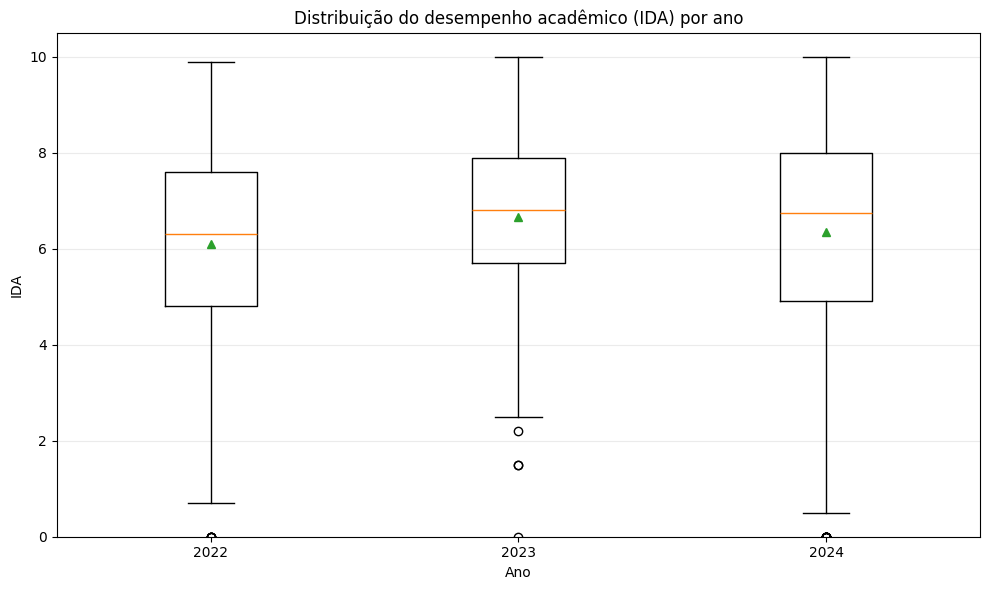

In [75]:
import matplotlib.pyplot as plt

dados_boxplot = []

labels = []

for ano, df in [
    (2022, df_2022),
    (2023, df_2023),
    (2024, df_2024)
]:
    serie = pd.to_numeric(
        df["IDA"],
        errors="coerce"
    ).dropna()

    dados_boxplot.append(serie)
    labels.append(str(ano))


fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.boxplot(
    dados_boxplot,
    labels=labels,
    showmeans=True
)

ax.set_title(
    "Distribuição do desempenho acadêmico (IDA) por ano"
)

ax.set_xlabel("Ano")
ax.set_ylabel("IDA")

ax.set_ylim(0, 10.5)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    OUTPUTS_DIR /
    "pergunta_02_distribuicao_ida_por_ano.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

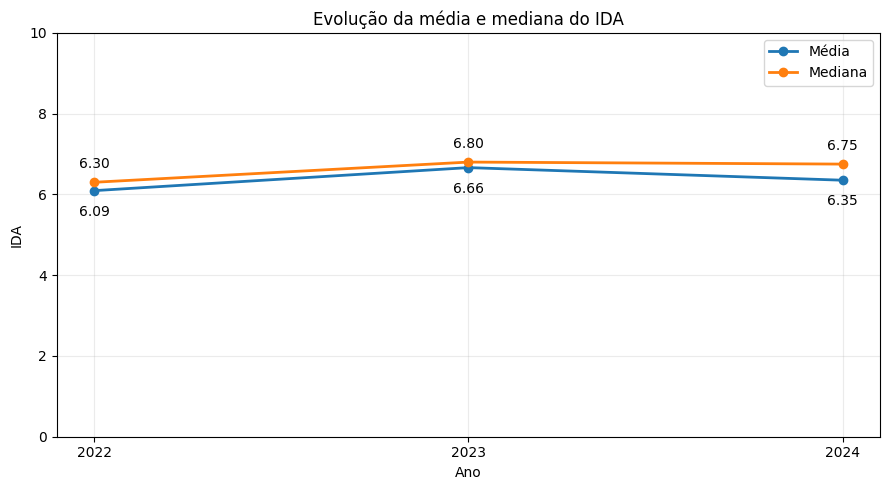

In [76]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    resumo_ida["Ano"],
    resumo_ida["Media"],
    marker="o",
    linewidth=2,
    label="Média"
)

ax.plot(
    resumo_ida["Ano"],
    resumo_ida["Mediana"],
    marker="o",
    linewidth=2,
    label="Mediana"
)

for _, linha in resumo_ida.iterrows():

    ax.annotate(
        f"{linha['Media']:.2f}",
        (
            linha["Ano"],
            linha["Media"]
        ),
        textcoords="offset points",
        xytext=(0, -18),
        ha="center"
    )

    ax.annotate(
        f"{linha['Mediana']:.2f}",
        (
            linha["Ano"],
            linha["Mediana"]
        ),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center"
    )


ax.set_title(
    "Evolução da média e mediana do IDA"
)

ax.set_xlabel("Ano")
ax.set_ylabel("IDA")

ax.set_xticks(
    [2022, 2023, 2024]
)

ax.set_ylim(0, 10)

ax.legend()

ax.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    OUTPUTS_DIR /
    "pergunta_02_media_mediana_ida.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 5.2 Interpretação da evolução do desempenho

Os resultados mostram que o desempenho acadêmico apresentou melhora expressiva
entre 2022 e 2023.

A média do IDA passou de **6,09 para 6,66**, enquanto a mediana aumentou de
**6,30 para 6,80**.

Em 2024 ocorre uma redução moderada da média para **6,35**, embora a mediana
permaneça praticamente estável em **6,75**.

Essa diferença entre média e mediana é importante.

Enquanto a mediana indica que o estudante típico manteve desempenho próximo ao
observado em 2023, a redução da média sugere que um grupo de alunos com notas mais
baixas passou a exercer maior influência sobre o resultado agregado.

A distribuição reforça essa interpretação:

- 2023 apresenta a menor dispersão dos três períodos;
- 2024 volta a apresentar maior heterogeneidade entre os alunos;
- o terceiro quartil de 2024 atinge 8,0, mostrando que existe também uma parcela
  relevante de estudantes com desempenho elevado.

### Insight preliminar

O principal desafio de 2024 não parece ser uma deterioração uniforme do desempenho,
mas uma maior desigualdade entre os resultados acadêmicos.

Por isso, a próxima análise buscará identificar **em quais fases estão concentrados
os maiores e menores níveis de IDA**.

In [77]:
auditoria_ida_zero = []

for ano, df in [
    (2022, df_2022),
    (2023, df_2023),
    (2024, df_2024)
]:

    ida = pd.to_numeric(
        df["IDA"],
        errors="coerce"
    )

    auditoria_ida_zero.append({
        "Ano": ano,
        "Registros": len(df),
        "IDA_nulos": int(ida.isna().sum()),
        "IDA_zero": int((ida == 0).sum()),
        "IDA_maior_zero": int((ida > 0).sum()),
        "Pct_zero_validos": round(
            (ida == 0).sum() /
            ida.notna().sum() * 100,
            2
        )
    })


auditoria_ida_zero = pd.DataFrame(
    auditoria_ida_zero
)

display(auditoria_ida_zero)

,Ano,Registros,IDA_nulos,IDA_zero,IDA_maior_zero,Pct_zero_validos
0,2022,860,0,6,854,0.70
1,2023,1014,77,1,936,0.11
2,2024,1156,101,16,1039,1.52


In [78]:
resultado_zero_fase = []

for ano, df in [
    (2022, df_2022),
    (2023, df_2023),
    (2024, df_2024)
]:

    temp = df.copy()

    temp["IDA_NUM"] = pd.to_numeric(
        temp["IDA"],
        errors="coerce"
    )

    zeros = (
        temp.loc[
            temp["IDA_NUM"] == 0
        ]
        .groupby("FASE_NUM")
        .size()
        .reset_index(name="IDA_zero")
    )

    zeros["Ano"] = ano

    resultado_zero_fase.append(
        zeros
    )


ida_zero_por_fase = pd.concat(
    resultado_zero_fase,
    ignore_index=True
)

display(ida_zero_por_fase)

,FASE_NUM,IDA_zero,Ano
0,1,1,2022
1,2,1,2022
2,3,3,2022
3,5,1,2022
4,0,1,2023
5,0,2,2024
6,1,3,2024
7,2,1,2024
8,3,2,2024
9,5,1,2024


In [79]:
for ano, df in [
    (2022, df_2022),
    (2023, df_2023),
    (2024, df_2024)
]:

    temp = df.loc[
        pd.to_numeric(
            df["IDA"],
            errors="coerce"
        ) == 0
    ].copy()

    print("\n" + "=" * 70)
    print(f"REGISTROS COM IDA = 0 — {ano}")
    print("=" * 70)

    print(
        f"Quantidade: {len(temp)}"
    )

    colunas = [
        "RA",
        "Fase",
        "FASE_NUM",
        "IDA",
        "IEG",
        "IAA",
        "IPS",
        "IPV",
        "IAN_ANALISE"
    ]

    colunas = [
        c for c in colunas
        if c in temp.columns
    ]

    display(
        temp[colunas].head(15)
    )


REGISTROS COM IDA = 0 — 2022
Quantidade: 6


,RA,Fase,FASE_NUM,IDA,IEG,IAA,IPS,IPV,IAN_ANALISE
74,RA-75,5,5,0.0,3.8,5.4,6.3,4.625,5.0
231,RA-232,3,3,0.0,4.9,0.0,7.5,4.542,10.0
287,RA-288,3,3,0.0,5.6,0.0,6.3,6.833,2.5
293,RA-294,3,3,0.0,5.8,9.6,7.5,5.917,2.5
357,RA-358,2,2,0.0,6.5,7.5,7.5,7.556,5.0
488,RA-489,1,1,0.0,7.2,9.0,7.5,6.500,10.0



REGISTROS COM IDA = 0 — 2023
Quantidade: 1


,RA,Fase,FASE_NUM,IDA,IEG,IAA,IPS,IPV,IAN_ANALISE
135,RA-948,ALFA,0,0.0,7.6,9.0,7.52,8.34,10.0



REGISTROS COM IDA = 0 — 2024
Quantidade: 16


,RA,Fase,FASE_NUM,IDA,IEG,IAA,IPS,IPV,IAN_ANALISE
59,RA-1311,ALFA,0,0.0,9.166667,9.002,2.5100,8.386667,10.0
194,RA-1392,ALFA,0,0.0,5.625000,9.002,7.5100,7.000000,5.0
273,RA-672,1H,1,0.0,3.952569,7.918,6.2600,4.496667,5.0
303,RA-776,1K,1,0.0,5.952381,7.917,5.6300,6.500000,5.0
355,RA-1446,1N,1,0.0,6.650198,8.002,6.2600,7.075000,10.0
480,RA-1482,2K,2,0.0,5.000000,8.502,7.5100,6.872500,5.0
568,RA-484,3A,3,0.0,3.914138,8.334,2.5100,3.122500,10.0
628,RA-1106,3F,3,0.0,5.431235,8.334,7.5100,7.500000,10.0
937,RA-1607,5D,5,0.0,6.222222,5.833,5.6350,6.762000,5.0
1029,RA-1230,7E,7,0.0,0.000000,7.917,7.1950,7.500000,10.0


### 5.3 Tratamento dos valores de IDA iguais a zero

Foram identificados valores de IDA iguais a zero em:

- **2022:** 6 alunos (0,70% dos IDAs válidos);
- **2023:** 1 aluno (0,11%);
- **2024:** 16 alunos (1,52%).

A inspeção individual mostrou que esses registros possuem, em grande parte, outros
indicadores normalmente preenchidos, como IEG, IAA, IPS, IPV e IAN.

Dessa forma, não há evidência suficiente para interpretar `IDA = 0` como ausência
de avaliação.

Por isso, os valores zero serão mantidos como observações válidas.

Em 2024 foi observada uma concentração específica de zeros na Fase 7. Esse padrão
será considerado na interpretação dos resultados por fase, evitando conclusões
baseadas apenas na média sem observar tamanho da amostra e distribuição.

In [80]:
resultados_ida_fase = []

for ano, df in [
    (2022, df_2022),
    (2023, df_2023),
    (2024, df_2024)
]:

    temp = df.copy()

    temp["IDA_NUM"] = pd.to_numeric(
        temp["IDA"],
        errors="coerce"
    )

    resumo = (
        temp
        .groupby("FASE_NUM")
        .agg(
            N_IDA=("IDA_NUM", "count"),
            IDA_Media=("IDA_NUM", "mean"),
            IDA_Mediana=("IDA_NUM", "median"),
            IDA_Desvio=("IDA_NUM", "std")
        )
        .reset_index()
    )

    resumo["Ano"] = ano

    resultados_ida_fase.append(resumo)


ida_por_fase = pd.concat(
    resultados_ida_fase,
    ignore_index=True
)

ida_por_fase["IDA_Media"] = (
    ida_por_fase["IDA_Media"].round(2)
)

ida_por_fase["IDA_Mediana"] = (
    ida_por_fase["IDA_Mediana"].round(2)
)

ida_por_fase["IDA_Desvio"] = (
    ida_por_fase["IDA_Desvio"].round(2)
)

display(ida_por_fase)

,FASE_NUM,N_IDA,IDA_Media,IDA_Mediana,IDA_Desvio,Ano
0,0,190,7.14,7.30,1.68,2022
1,1,192,6.46,6.80,2.06,2022
2,2,155,5.41,5.50,2.00,2022
3,3,148,5.14,5.20,1.93,2022
4,4,76,6.05,6.10,1.55,2022
5,5,60,5.87,6.55,2.29,2022
6,6,18,6.69,6.85,1.56,2022
7,7,21,5.25,5.00,2.18,2022
8,0,231,7.42,7.80,1.52,2023
9,1,173,6.81,6.90,1.49,2023


In [81]:
tabela_ida_fase = (
    ida_por_fase
    .pivot(
        index="FASE_NUM",
        columns="Ano",
        values="IDA_Media"
    )
    .round(2)
)

tabela_ida_fase.index.name = "Fase"

display(tabela_ida_fase)

Ano,2022,2023,2024
Fase,,,
0,7.14,7.42,7.32
1,6.46,6.81,6.79
2,5.41,6.74,6.25
3,5.14,5.75,5.35
4,6.05,6.00,5.88
5,5.87,5.90,6.45
6,6.69,6.81,7.23
7,5.25,7.81,5.81
8,NaN,NaN,8.00


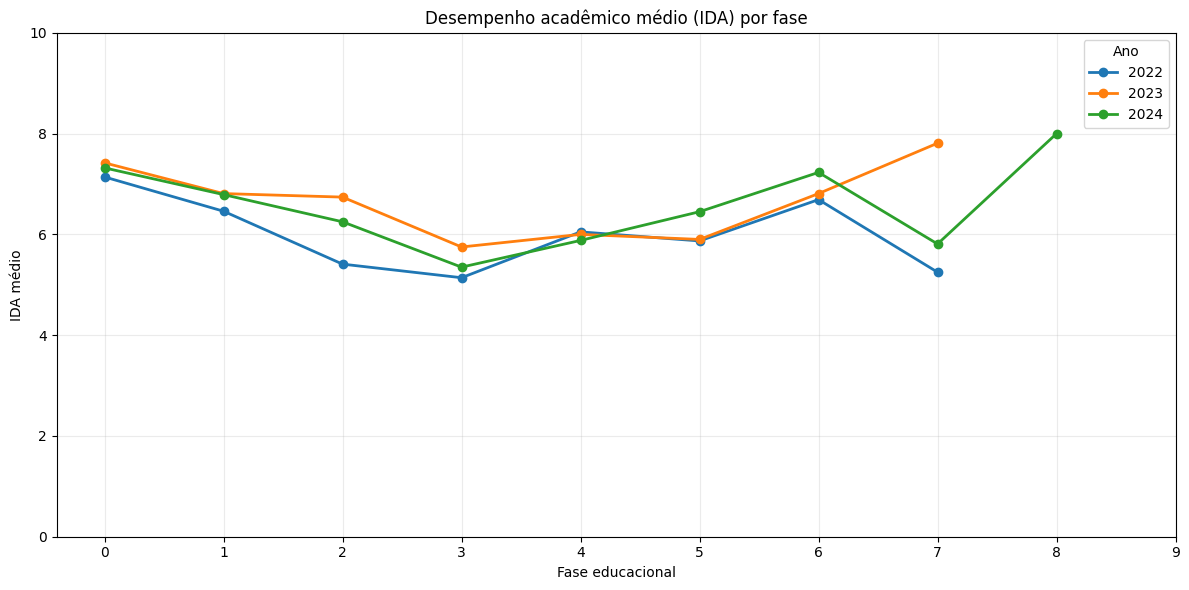

In [82]:
fig, ax = plt.subplots(
    figsize=(12, 6)
)

for ano in [2022, 2023, 2024]:

    dados_ano = (
        ida_por_fase.loc[
            ida_por_fase["Ano"] == ano
        ]
        .sort_values("FASE_NUM")
    )

    ax.plot(
        dados_ano["FASE_NUM"],
        dados_ano["IDA_Media"],
        marker="o",
        linewidth=2,
        label=str(ano)
    )


ax.set_title(
    "Desempenho acadêmico médio (IDA) por fase"
)

ax.set_xlabel(
    "Fase educacional"
)

ax.set_ylabel(
    "IDA médio"
)

ax.set_ylim(0, 10)

ax.set_xticks(
    sorted(
        ida_por_fase["FASE_NUM"]
        .dropna()
        .unique()
    )
)

ax.legend(
    title="Ano"
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    OUTPUTS_DIR /
    "pergunta_02_ida_medio_por_fase.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 5.4 Desempenho acadêmico por fase

A análise por fase mostra que a evolução do IDA não ocorre de maneira uniforme ao
longo da trajetória educacional.

Algumas fases apresentam evolução positiva entre 2022 e 2024:

- **Fase 5:** IDA médio de 5,87 → 5,90 → 6,45;
- **Fase 6:** 6,69 → 6,81 → 7,23;
- **Fase 1:** permanece relativamente estável em patamar próximo de 6,8.

Em outras fases, o desempenho melhorou em 2023 e apresentou recuo em 2024:

- **Fase 2:** 5,41 → 6,74 → 6,25;
- **Fase 3:** 5,14 → 5,75 → 5,35.

Esses resultados mostram que a pequena redução do IDA médio geral em 2024 não
representa uma queda homogênea entre todos os alunos.

### Atenção para a Fase 7

A Fase 7 apresentou forte variação:

- **2022:** média 5,25;
- **2023:** média 7,81;
- **2024:** média 5,81.

Entretanto, em 2024 a mediana da Fase 7 foi **7,07**, muito acima da média,
e o desvio-padrão atingiu **3,06**.

Esse comportamento indica elevada heterogeneidade dentro da fase.

A auditoria anterior mostrou que vários registros de IDA igual a zero estão
concentrados justamente na Fase 7 de 2024. Portanto, a queda da média desse grupo
não deve ser interpretada como uma deterioração uniforme do desempenho de todos os
alunos da fase.

### Insight gerencial

Os resultados sugerem dois tipos distintos de atenção:

1. fases como 2 e 3, nas quais houve perda parcial do avanço observado em 2023;
2. fases como 7, onde a média esconde grande desigualdade interna e um grupo
   específico de alunos com desempenho muito baixo.

Assim, decisões de intervenção devem considerar não apenas a média de cada fase,
mas também a dispersão dos resultados e os alunos que compõem a cauda inferior.

## 5.5 Evolução do IDA entre os mesmos estudantes

A comparação das médias anuais pode ser influenciada pela entrada e saída de alunos
da base.

Para avaliar a evolução acadêmica individual, será criado um painel longitudinal
contendo apenas estudantes:

- presentes em 2022, 2023 e 2024;
- com IDA válido nos três períodos.

Essa análise permitirá verificar se o desempenho acadêmico dos mesmos estudantes
melhorou, permaneceu estável ou diminuiu ao longo do período.

In [83]:
ida_2022_long = df_2022[
    ["RA", "IDA"]
].copy()

ida_2023_long = df_2023[
    ["RA", "IDA"]
].copy()

ida_2024_long = df_2024[
    ["RA", "IDA"]
].copy()


ida_2022_long["IDA_2022"] = pd.to_numeric(
    ida_2022_long["IDA"],
    errors="coerce"
)

ida_2023_long["IDA_2023"] = pd.to_numeric(
    ida_2023_long["IDA"],
    errors="coerce"
)

ida_2024_long["IDA_2024"] = pd.to_numeric(
    ida_2024_long["IDA"],
    errors="coerce"
)


painel_ida = (
    ida_2022_long[["RA", "IDA_2022"]]
    .merge(
        ida_2023_long[["RA", "IDA_2023"]],
        on="RA",
        how="inner"
    )
    .merge(
        ida_2024_long[["RA", "IDA_2024"]],
        on="RA",
        how="inner"
    )
)


painel_ida = painel_ida.dropna(
    subset=[
        "IDA_2022",
        "IDA_2023",
        "IDA_2024"
    ]
).copy()


print(
    f"Alunos com IDA válido nos três anos: "
    f"{len(painel_ida)}"
)

display(
    painel_ida.head()
)

Alunos com IDA válido nos três anos: 435


,RA,IDA_2022,IDA_2023,IDA_2024
20,RA-40,6.8,5.9,5.333333
21,RA-42,4.8,5.7,8.166667
22,RA-45,6.8,7.9,8.000000
23,RA-48,8.1,7.7,7.500000
25,RA-52,6.2,6.4,7.216667


In [84]:
evolucao_ida_longitudinal = pd.DataFrame({
    "Ano": [2022, 2023, 2024],

    "Media": [
        painel_ida["IDA_2022"].mean(),
        painel_ida["IDA_2023"].mean(),
        painel_ida["IDA_2024"].mean()
    ],

    "Mediana": [
        painel_ida["IDA_2022"].median(),
        painel_ida["IDA_2023"].median(),
        painel_ida["IDA_2024"].median()
    ]
})

evolucao_ida_longitudinal[
    ["Media", "Mediana"]
] = evolucao_ida_longitudinal[
    ["Media", "Mediana"]
].round(2)

display(evolucao_ida_longitudinal)

,Ano,Media,Mediana
0,2022,6.68,7.0
1,2023,6.77,6.8
2,2024,6.21,6.5


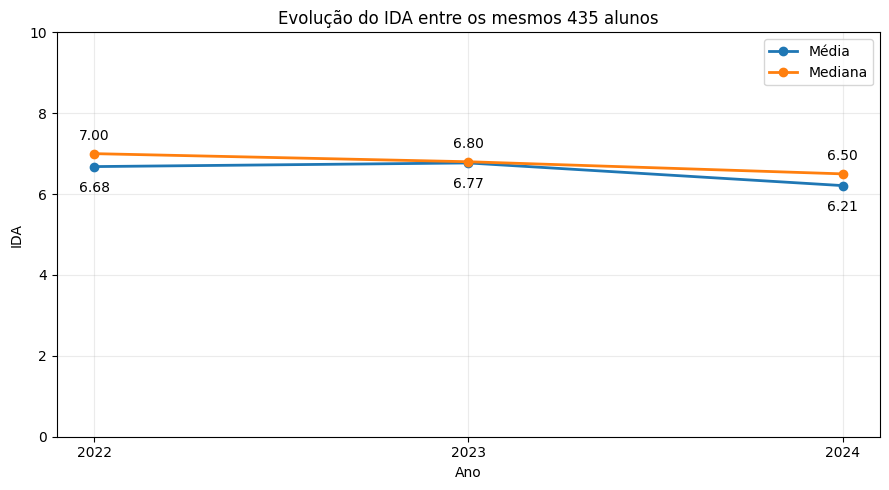

In [85]:
fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    evolucao_ida_longitudinal["Ano"],
    evolucao_ida_longitudinal["Media"],
    marker="o",
    linewidth=2,
    label="Média"
)

ax.plot(
    evolucao_ida_longitudinal["Ano"],
    evolucao_ida_longitudinal["Mediana"],
    marker="o",
    linewidth=2,
    label="Mediana"
)

for coluna in ["Media", "Mediana"]:

    for _, linha in evolucao_ida_longitudinal.iterrows():

        deslocamento = (
            10 if coluna == "Mediana" else -18
        )

        ax.annotate(
            f"{linha[coluna]:.2f}",
            (
                linha["Ano"],
                linha[coluna]
            ),
            textcoords="offset points",
            xytext=(0, deslocamento),
            ha="center"
        )

ax.set_title(
    f"Evolução do IDA entre os mesmos {len(painel_ida)} alunos"
)

ax.set_xlabel("Ano")
ax.set_ylabel("IDA")

ax.set_xticks(
    [2022, 2023, 2024]
)

ax.set_ylim(0, 10)

ax.legend()

ax.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    OUTPUTS_DIR /
    "pergunta_02_ida_longitudinal.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [86]:
painel_ida["DELTA_IDA_22_24"] = (
    painel_ida["IDA_2024"]
    -
    painel_ida["IDA_2022"]
)

painel_ida["EVOLUCAO_IDA_22_24"] = np.select(
    [
        painel_ida["DELTA_IDA_22_24"] > 0,
        painel_ida["DELTA_IDA_22_24"] == 0,
        painel_ida["DELTA_IDA_22_24"] < 0
    ],
    [
        "Melhorou",
        "Manteve",
        "Piorou"
    ],
    default="Indefinido"
)


resumo_evolucao_ida_individual = (
    painel_ida[
        "EVOLUCAO_IDA_22_24"
    ]
    .value_counts()
    .rename_axis("Evolução")
    .reset_index(name="Quantidade")
)


resumo_evolucao_ida_individual["Percentual"] = (
    resumo_evolucao_ida_individual["Quantidade"]
    /
    len(painel_ida)
    * 100
).round(2)

display(
    resumo_evolucao_ida_individual
)

,Evolução,Quantidade,Percentual
0,Piorou,240,55.17
1,Melhorou,191,43.91
2,Manteve,4,0.92


### 5.6 Leitura longitudinal do desempenho acadêmico

A análise longitudinal trouxe uma perspectiva diferente daquela observada na
defasagem.

Foram identificados **435 alunos com IDA válido em 2022, 2023 e 2024**.

Nesse grupo, o IDA médio evoluiu de:

- **6,68 em 2022**
- **6,77 em 2023**
- **6,21 em 2024**

A mediana também apresentou redução:

- **7,00 em 2022**
- **6,80 em 2023**
- **6,50 em 2024**

Na comparação direta entre 2022 e 2024:

- **240 alunos (55,17%) apresentaram redução do IDA**
- **191 alunos (43,91%) apresentaram aumento**
- **4 alunos (0,92%) permaneceram com o mesmo resultado**

### Insight analítico

Esse resultado contrasta com a evolução da defasagem.

Na Pergunta 1, os mesmos estudantes apresentaram forte redução da proporção de
defasagem. Entretanto, o desempenho acadêmico medido pelo IDA não apresentou a
mesma trajetória positiva.

Isso sugere que **adequação de nível e desempenho acadêmico representam dimensões
diferentes da trajetória educacional**.

Um aluno pode avançar em sua adequação à fase esperada sem necessariamente apresentar
melhora proporcional em suas notas acadêmicas.

Antes da conclusão definitiva, será analisada a magnitude dessas variações para
distinguir pequenas oscilações de mudanças mais expressivas no IDA.

In [87]:
# ============================================================
# MAGNITUDE DA VARIAÇÃO DO IDA — 2022 → 2024
# ============================================================

resumo_delta_ida = painel_ida[
    "DELTA_IDA_22_24"
].describe(
    percentiles=[
        0.10,
        0.25,
        0.50,
        0.75,
        0.90
    ]
).round(3)

display(
    resumo_delta_ida.to_frame(
        name="DELTA_IDA_22_24"
    )
)

,DELTA_IDA_22_24
count,435.000
mean,-0.471
std,2.138
min,-8.800
10%,-3.133
25%,-1.700
50%,-0.300
75%,0.758
90%,2.053
max,5.450


In [88]:
def classificar_magnitude_delta_ida(delta):

    if pd.isna(delta):
        return np.nan

    if delta <= -1:
        return "Queda >= 1 ponto"

    if delta < 0:
        return "Queda < 1 ponto"

    if delta == 0:
        return "Sem alteração"

    if delta < 1:
        return "Aumento < 1 ponto"

    return "Aumento >= 1 ponto"


painel_ida["FAIXA_DELTA_IDA"] = (
    painel_ida["DELTA_IDA_22_24"]
    .apply(classificar_magnitude_delta_ida)
)


ordem_delta_ida = [
    "Queda >= 1 ponto",
    "Queda < 1 ponto",
    "Sem alteração",
    "Aumento < 1 ponto",
    "Aumento >= 1 ponto"
]


resumo_magnitude_ida = (
    painel_ida["FAIXA_DELTA_IDA"]
    .value_counts()
    .reindex(
        ordem_delta_ida,
        fill_value=0
    )
    .rename_axis("Magnitude")
    .reset_index(name="Quantidade")
)


resumo_magnitude_ida["Percentual"] = (
    resumo_magnitude_ida["Quantidade"]
    /
    len(painel_ida)
    * 100
).round(2)


display(resumo_magnitude_ida)

,Magnitude,Quantidade,Percentual
0,Queda >= 1 ponto,157,36.09
1,Queda < 1 ponto,83,19.08
2,Sem alteração,4,0.92
3,Aumento < 1 ponto,94,21.61
4,Aumento >= 1 ponto,97,22.30


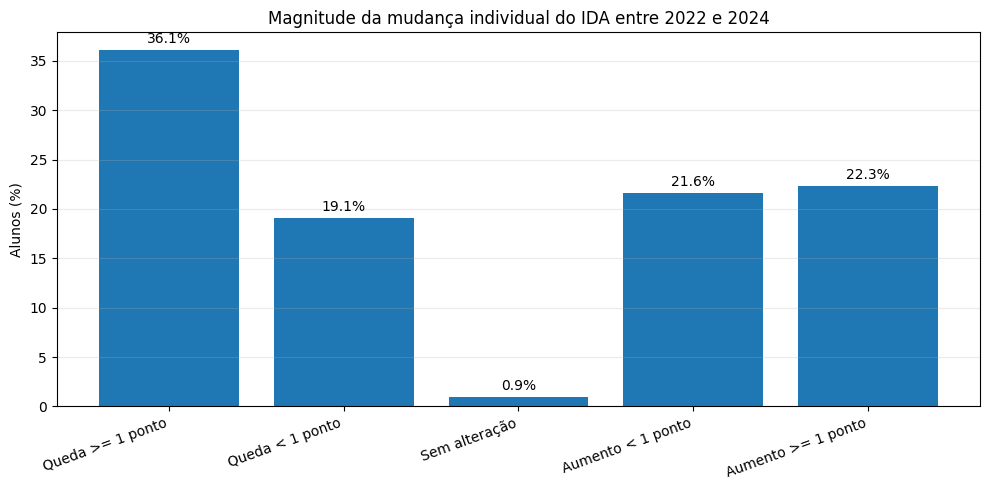

In [89]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.bar(
    resumo_magnitude_ida["Magnitude"],
    resumo_magnitude_ida["Percentual"]
)

for i, valor in enumerate(
    resumo_magnitude_ida["Percentual"]
):

    ax.text(
        i,
        valor + 0.7,
        f"{valor:.1f}%",
        ha="center"
    )


ax.set_title(
    "Magnitude da mudança individual do IDA entre 2022 e 2024"
)

ax.set_xlabel("")
ax.set_ylabel("Alunos (%)")

plt.xticks(
    rotation=20,
    ha="right"
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    OUTPUTS_DIR /
    "pergunta_02_magnitude_variacao_ida.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5.7 Conclusão — Pergunta 2

### Como evoluiu o desempenho acadêmico (IDA)?

A evolução do IDA apresentou comportamento diferente daquele observado na
defasagem.

Na população total, o desempenho médio evoluiu de:

- **6,09 em 2022**
- **6,66 em 2023**
- **6,35 em 2024**

A mediana passou de:

- **6,30 em 2022**
- **6,80 em 2023**
- **6,75 em 2024**

Esses resultados indicam melhora entre 2022 e 2023, seguida de uma redução
moderada em 2024.

### Diferenças entre fases

A evolução não foi homogênea.

Algumas fases apresentaram melhora entre 2022 e 2024, como:

- **Fase 5:** 5,87 → 6,45;
- **Fase 6:** 6,69 → 7,23.

Outras fases apresentaram melhora em 2023 e perda parcial em 2024, como:

- **Fase 2:** 5,41 → 6,74 → 6,25;
- **Fase 3:** 5,14 → 5,75 → 5,35.

A Fase 7 apresentou forte heterogeneidade em 2024, com média de 5,81,
mediana de 7,07 e desvio-padrão de 3,06, indicando que um grupo com valores
muito baixos exerce forte influência sobre a média.

### Evidência longitudinal

Entre os **435 alunos com IDA válido nos três anos**, a média caiu de:

- **6,68 em 2022**
- **6,77 em 2023**
- **6,21 em 2024**

Na comparação individual entre 2022 e 2024:

- **55,17% apresentaram redução no IDA**
- **43,91% apresentaram aumento**
- **0,92% permaneceram exatamente no mesmo valor**

A magnitude dessas mudanças mostra que o resultado não é explicado apenas por
pequenas oscilações:

- **36,09% dos alunos tiveram queda de pelo menos 1 ponto**
- **19,08% tiveram queda inferior a 1 ponto**
- **21,61% tiveram aumento inferior a 1 ponto**
- **22,30% tiveram aumento de pelo menos 1 ponto**

A variação média do IDA foi de **-0,47 ponto**, enquanto 25% dos alunos
apresentaram queda de pelo menos **1,70 ponto**.

### Resposta à pergunta de negócio

O desempenho acadêmico apresentou melhora em 2023, mas essa evolução não foi
sustentada integralmente em 2024.

Além disso, a análise longitudinal mostra que uma parcela relevante dos alunos
teve queda acadêmica material entre 2022 e 2024.

Esse resultado contrasta com a melhora observada na adequação de nível.

Portanto, **redução da defasagem e melhora acadêmica não caminharam necessariamente
na mesma direção para todos os estudantes**.

### Recomendação gerencial

A gestão deve acompanhar separadamente:

1. adequação à fase educacional;
2. desempenho acadêmico efetivo.

Alunos que deixam de estar defasados, mas apresentam queda de IDA, podem formar
um grupo de risco não identificado apenas pelo IAN.

Esse grupo será especialmente importante nas próximas análises de engajamento,
aspectos psicossociais e ponto de virada.

# 6. Pergunta 3 — Qual a relação entre engajamento, desempenho e ponto de virada?

O IEG representa o nível de engajamento do estudante no programa.

Nesta análise será investigado se alunos com maior engajamento também apresentam:

- maior desempenho acadêmico (IDA);
- maior indicador de ponto de virada (IPV).

A análise será realizada em três etapas:

1. auditoria da qualidade e escala dos indicadores;
2. cálculo das correlações entre IEG, IDA e IPV;
3. comparação dos resultados por faixas de engajamento.

Como os indicadores podem apresentar assimetria e valores extremos, será utilizada
principalmente a correlação de **Spearman**, que mede associação monotônica entre as
variáveis sem exigir normalidade.

In [90]:
resumo_pergunta3 = []

for ano, df in [
    (2022, df_2022),
    (2023, df_2023),
    (2024, df_2024)
]:

    for indicador in ["IEG", "IDA", "IPV"]:

        serie = pd.to_numeric(
            df[indicador],
            errors="coerce"
        )

        resumo_pergunta3.append({
            "Ano": ano,
            "Indicador": indicador,
            "Registros": len(df),
            "Preenchidos": int(serie.notna().sum()),
            "Nulos": int(serie.isna().sum()),
            "Media": round(serie.mean(), 3),
            "Mediana": round(serie.median(), 3),
            "Desvio_padrao": round(serie.std(), 3),
            "Minimo": round(serie.min(), 3),
            "Maximo": round(serie.max(), 3)
        })


resumo_pergunta3 = pd.DataFrame(
    resumo_pergunta3
)

display(resumo_pergunta3)

,Ano,Indicador,Registros,Preenchidos,Nulos,Media,Mediana,Desvio_padrao,Minimo,Maximo
0,2022,IEG,860,860,0,7.891,8.300,1.638,0.000,10.00
1,2022,IDA,860,860,0,6.093,6.300,2.046,0.000,9.90
2,2022,IPV,860,860,0,7.254,7.333,1.093,2.500,10.00
3,2023,IEG,1014,938,76,8.699,9.000,1.084,3.700,10.00
4,2023,IDA,1014,937,77,6.663,6.800,1.595,0.000,10.00
5,2023,IPV,1014,938,76,8.028,8.045,0.945,3.320,10.01
6,2024,IEG,1156,1156,0,7.375,8.333,2.847,0.000,10.00
7,2024,IDA,1156,1055,101,6.351,6.750,2.132,0.000,10.00
8,2024,IPV,1156,1054,102,7.354,7.500,1.049,2.943,9.76


In [91]:
amostras_correlacao = []

for ano, df in [
    (2022, df_2022),
    (2023, df_2023),
    (2024, df_2024)
]:

    temp = df.copy()

    for coluna in ["IEG", "IDA", "IPV"]:
        temp[coluna] = pd.to_numeric(
            temp[coluna],
            errors="coerce"
        )

    amostras_correlacao.append({
        "Ano": ano,

        "N_IEG_IDA": (
            temp[["IEG", "IDA"]]
            .dropna()
            .shape[0]
        ),

        "N_IEG_IPV": (
            temp[["IEG", "IPV"]]
            .dropna()
            .shape[0]
        ),

        "N_IEG_IDA_IPV": (
            temp[["IEG", "IDA", "IPV"]]
            .dropna()
            .shape[0]
        )
    })


amostras_correlacao = pd.DataFrame(
    amostras_correlacao
)

display(amostras_correlacao)

,Ano,N_IEG_IDA,N_IEG_IPV,N_IEG_IDA_IPV
0,2022,860,860,860
1,2023,937,938,937
2,2024,1055,1054,1054


## 6.1 Qualidade dos indicadores utilizados

Os indicadores IEG, IDA e IPV possuem amostra suficiente para análise de associação.

As quantidades de registros completos para IEG × IDA foram:

- **2022:** 860 alunos;
- **2023:** 937 alunos;
- **2024:** 1.055 alunos.

Para IEG × IPV:

- **2022:** 860 alunos;
- **2023:** 938 alunos;
- **2024:** 1.054 alunos.

Uma característica importante aparece em 2024: o IEG apresenta dispersão
consideravelmente maior que nos anos anteriores.

O desvio-padrão do engajamento foi:

- **2022:** 1,64;
- **2023:** 1,08;
- **2024:** 2,85.

Isso indica maior heterogeneidade de engajamento em 2024 e reforça a necessidade
de analisar não apenas médias, mas também a relação entre os indicadores em nível
individual.

In [92]:
from scipy.stats import spearmanr

resultados_correlacao = []

for ano, df in [
    (2022, df_2022),
    (2023, df_2023),
    (2024, df_2024)
]:

    temp = df.copy()

    for coluna in ["IEG", "IDA", "IPV"]:
        temp[coluna] = pd.to_numeric(
            temp[coluna],
            errors="coerce"
        )

    # --------------------------------------------------------
    # IEG × IDA
    # --------------------------------------------------------

    base_ida = temp[
        ["IEG", "IDA"]
    ].dropna()

    rho_ida, p_ida = spearmanr(
        base_ida["IEG"],
        base_ida["IDA"]
    )

    # --------------------------------------------------------
    # IEG × IPV
    # --------------------------------------------------------

    base_ipv = temp[
        ["IEG", "IPV"]
    ].dropna()

    rho_ipv, p_ipv = spearmanr(
        base_ipv["IEG"],
        base_ipv["IPV"]
    )

    resultados_correlacao.append({
        "Ano": ano,

        "N_IEG_IDA": len(base_ida),
        "Spearman_IEG_IDA": round(rho_ida, 3),
        "p_IEG_IDA": p_ida,

        "N_IEG_IPV": len(base_ipv),
        "Spearman_IEG_IPV": round(rho_ipv, 3),
        "p_IEG_IPV": p_ipv
    })


correlacoes_pergunta3 = pd.DataFrame(
    resultados_correlacao
)

display(correlacoes_pergunta3)

,Ano,N_IEG_IDA,Spearman_IEG_IDA,p_IEG_IDA,N_IEG_IPV,Spearman_IEG_IPV,p_IEG_IPV
0,2022,860,0.507,1.803060e-57,860,0.540,2.375997e-66
1,2023,937,0.446,4.225522e-47,938,0.492,2.432733e-58
2,2024,1055,0.517,4.207630e-73,1054,0.551,1.023802e-84


In [93]:
correlacoes_executivas = (
    correlacoes_pergunta3[
        [
            "Ano",
            "Spearman_IEG_IDA",
            "Spearman_IEG_IPV"
        ]
    ]
    .copy()
)

display(correlacoes_executivas)

,Ano,Spearman_IEG_IDA,Spearman_IEG_IPV
0,2022,0.507,0.540
1,2023,0.446,0.492
2,2024,0.517,0.551


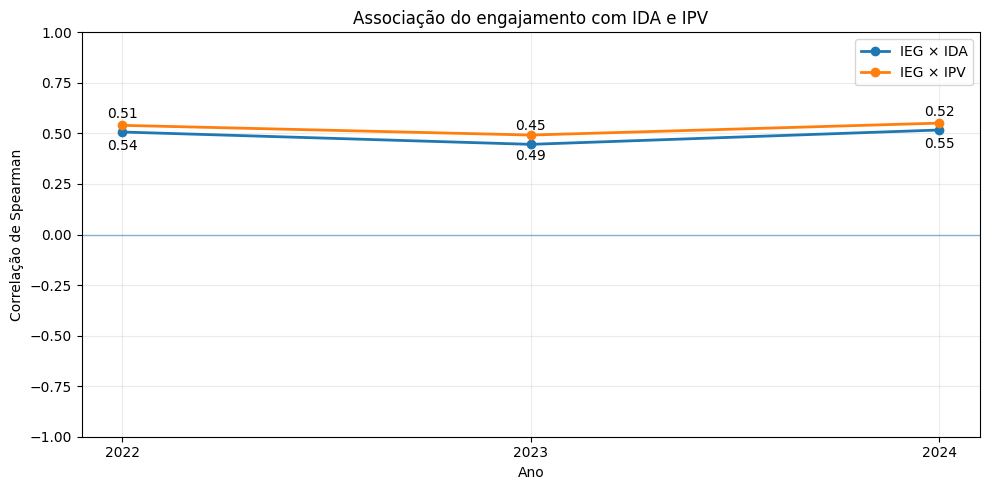

In [94]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.plot(
    correlacoes_pergunta3["Ano"],
    correlacoes_pergunta3["Spearman_IEG_IDA"],
    marker="o",
    linewidth=2,
    label="IEG × IDA"
)

ax.plot(
    correlacoes_pergunta3["Ano"],
    correlacoes_pergunta3["Spearman_IEG_IPV"],
    marker="o",
    linewidth=2,
    label="IEG × IPV"
)

for _, linha in correlacoes_pergunta3.iterrows():

    ax.annotate(
        f"{linha['Spearman_IEG_IDA']:.2f}",
        (
            linha["Ano"],
            linha["Spearman_IEG_IDA"]
        ),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center"
    )

    ax.annotate(
        f"{linha['Spearman_IEG_IPV']:.2f}",
        (
            linha["Ano"],
            linha["Spearman_IEG_IPV"]
        ),
        textcoords="offset points",
        xytext=(0, -18),
        ha="center"
    )


ax.axhline(
    0,
    linewidth=1,
    alpha=0.5
)

ax.set_title(
    "Associação do engajamento com IDA e IPV"
)

ax.set_xlabel("Ano")
ax.set_ylabel("Correlação de Spearman")

ax.set_xticks(
    [2022, 2023, 2024]
)

ax.set_ylim(-1, 1)

ax.legend()

ax.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    OUTPUTS_DIR /
    "pergunta_03_correlacao_ieg_ida_ipv.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 6.2 Interpretação das correlações

A análise de Spearman indica associação positiva e moderada entre o nível de
engajamento (IEG) e os indicadores de desempenho acadêmico (IDA) e ponto de
virada (IPV).

### IEG × IDA

As correlações encontradas foram:

- **2022:** ρ = 0,507
- **2023:** ρ = 0,446
- **2024:** ρ = 0,517

Isso indica que alunos mais engajados tendem a apresentar melhor desempenho
acadêmico.

### IEG × IPV

As associações foram ligeiramente mais fortes:

- **2022:** ρ = 0,540
- **2023:** ρ = 0,492
- **2024:** ρ = 0,551

Isso sugere que o engajamento também está associado ao desenvolvimento capturado
pelo indicador de ponto de virada.

### Estabilidade temporal

Embora a intensidade varie entre os anos, o sinal da relação permanece positivo
em todos os períodos.

O padrão é especialmente relevante porque aparece de forma consistente em três
bases anuais independentes e com amostras superiores a 850 estudantes.

Todos os testes apresentaram significância estatística elevada.

### Insight preliminar

O engajamento não aparece apenas como uma característica comportamental isolada.
Ele está associado simultaneamente ao desempenho acadêmico e ao desenvolvimento
mais amplo representado pelo IPV.

Entretanto, correlação não implica causalidade. Os resultados indicam associação,
não permitem afirmar que o aumento do IEG, isoladamente, cause melhora no IDA ou
no IPV.

In [95]:
resultados_quartis = []

for ano, df in [
    (2022, df_2022),
    (2023, df_2023),
    (2024, df_2024)
]:

    temp = df.copy()

    for coluna in ["IEG", "IDA", "IPV"]:
        temp[coluna] = pd.to_numeric(
            temp[coluna],
            errors="coerce"
        )

    temp = temp.dropna(
        subset=["IEG"]
    ).copy()

    # qcut com duplicates='drop' evita erro se houver muitos valores empatados
    temp["QUARTIL_IEG"] = pd.qcut(
        temp["IEG"],
        q=4,
        labels=[
            "Q1 - Menor engajamento",
            "Q2",
            "Q3",
            "Q4 - Maior engajamento"
        ],
        duplicates="drop"
    )

    resumo = (
        temp
        .groupby(
            "QUARTIL_IEG",
            observed=True
        )
        .agg(
            Alunos=("RA", "size"),
            IEG_Medio=("IEG", "mean"),
            IDA_Medio=("IDA", "mean"),
            IPV_Medio=("IPV", "mean")
        )
        .reset_index()
    )

    resumo["Ano"] = ano

    resultados_quartis.append(
        resumo
    )


quartis_ieg = pd.concat(
    resultados_quartis,
    ignore_index=True
)

quartis_ieg[
    ["IEG_Medio", "IDA_Medio", "IPV_Medio"]
] = quartis_ieg[
    ["IEG_Medio", "IDA_Medio", "IPV_Medio"]
].round(2)

display(quartis_ieg)

,QUARTIL_IEG,Alunos,IEG_Medio,IDA_Medio,IPV_Medio,Ano
0,Q1 - Menor engajamento,220,5.57,4.45,6.37,2022
1,Q2,219,7.78,6.14,7.22,2022
2,Q3,212,8.77,6.69,7.57,2022
3,Q4 - Maior engajamento,209,9.56,7.17,7.91,2022
4,Q1 - Menor engajamento,244,7.22,5.60,7.44,2023
5,Q2,253,8.63,6.58,7.88,2023
6,Q3,221,9.32,7.05,8.25,2023
7,Q4 - Maior engajamento,220,9.80,7.54,8.63,2023
8,Q1 - Menor engajamento,289,3.28,4.40,6.31,2024
9,Q2,290,7.53,5.87,7.14,2024


In [96]:
comparacao_q1_q4 = []

for ano in [2022, 2023, 2024]:

    temp = quartis_ieg.loc[
        quartis_ieg["Ano"] == ano
    ]

    q1 = temp.loc[
        temp["QUARTIL_IEG"] == "Q1 - Menor engajamento"
    ].iloc[0]

    q4 = temp.loc[
        temp["QUARTIL_IEG"] == "Q4 - Maior engajamento"
    ].iloc[0]

    comparacao_q1_q4.append({
        "Ano": ano,
        "IDA_Q1": q1["IDA_Medio"],
        "IDA_Q4": q4["IDA_Medio"],
        "Diferenca_IDA": round(
            q4["IDA_Medio"] - q1["IDA_Medio"],
            2
        ),
        "IPV_Q1": q1["IPV_Medio"],
        "IPV_Q4": q4["IPV_Medio"],
        "Diferenca_IPV": round(
            q4["IPV_Medio"] - q1["IPV_Medio"],
            2
        )
    })


comparacao_q1_q4 = pd.DataFrame(
    comparacao_q1_q4
)

display(comparacao_q1_q4)

,Ano,IDA_Q1,IDA_Q4,Diferenca_IDA,IPV_Q1,IPV_Q4,Diferenca_IPV
0,2022,4.45,7.17,2.72,6.37,7.91,1.54
1,2023,5.60,7.54,1.94,7.44,8.63,1.19
2,2024,4.40,7.54,3.14,6.31,7.99,1.68


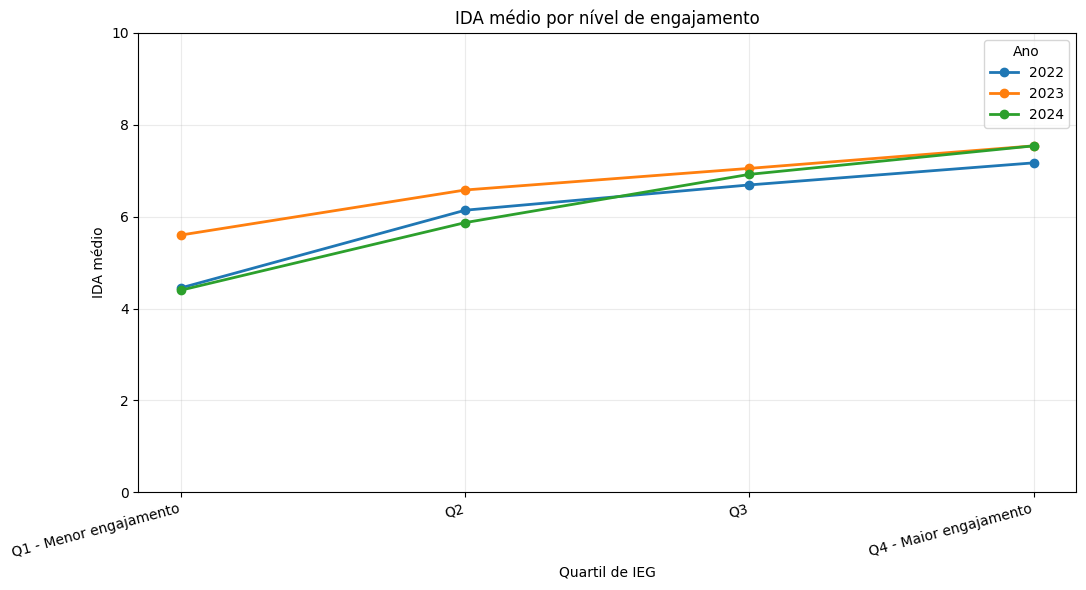

In [97]:
fig, ax = plt.subplots(
    figsize=(11, 6)
)

for ano in [2022, 2023, 2024]:

    dados_ano = quartis_ieg.loc[
        quartis_ieg["Ano"] == ano
    ]

    ax.plot(
        dados_ano["QUARTIL_IEG"].astype(str),
        dados_ano["IDA_Medio"],
        marker="o",
        linewidth=2,
        label=str(ano)
    )

ax.set_title(
    "IDA médio por nível de engajamento"
)

ax.set_xlabel(
    "Quartil de IEG"
)

ax.set_ylabel(
    "IDA médio"
)

ax.set_ylim(0, 10)

ax.legend(
    title="Ano"
)

ax.grid(
    alpha=0.25
)

plt.xticks(
    rotation=15,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    OUTPUTS_DIR /
    "pergunta_03_ida_por_quartil_ieg.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

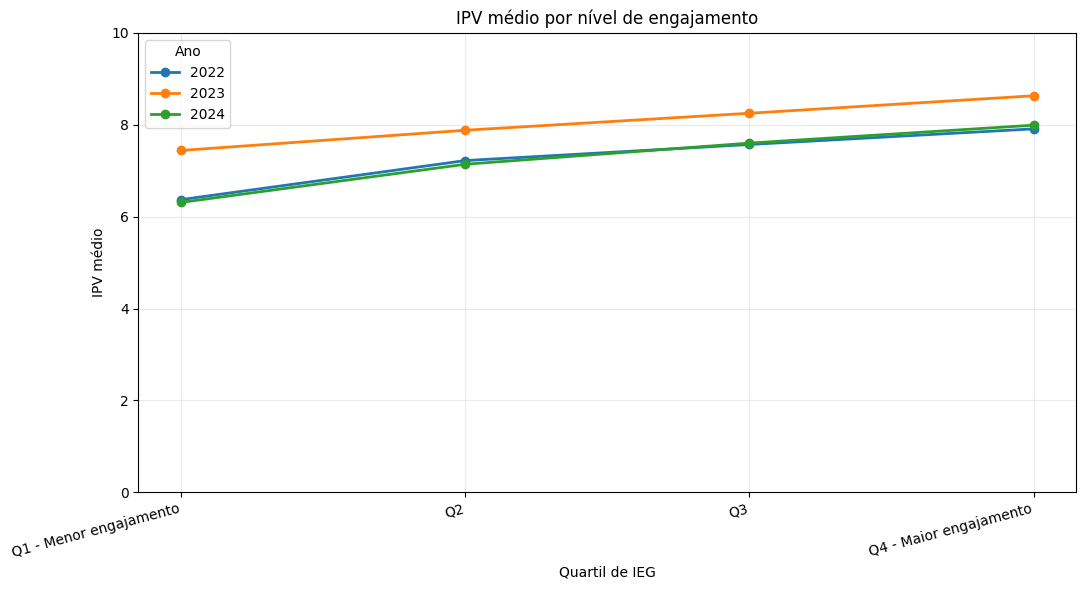

In [98]:
fig, ax = plt.subplots(
    figsize=(11, 6)
)

for ano in [2022, 2023, 2024]:

    dados_ano = quartis_ieg.loc[
        quartis_ieg["Ano"] == ano
    ]

    ax.plot(
        dados_ano["QUARTIL_IEG"].astype(str),
        dados_ano["IPV_Medio"],
        marker="o",
        linewidth=2,
        label=str(ano)
    )

ax.set_title(
    "IPV médio por nível de engajamento"
)

ax.set_xlabel(
    "Quartil de IEG"
)

ax.set_ylabel(
    "IPV médio"
)

ax.set_ylim(0, 10)

ax.legend(
    title="Ano"
)

ax.grid(
    alpha=0.25
)

plt.xticks(
    rotation=15,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    OUTPUTS_DIR /
    "pergunta_03_ipv_por_quartil_ieg.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 6.3 Conclusão — Pergunta 3

### Alunos mais engajados apresentam melhor desempenho acadêmico e maior ponto de virada?

Os resultados mostram uma associação positiva, consistente e moderada entre
engajamento (IEG), desempenho acadêmico (IDA) e ponto de virada (IPV).

A correlação de Spearman entre IEG e IDA foi:

- **2022:** ρ = 0,507
- **2023:** ρ = 0,446
- **2024:** ρ = 0,517

Entre IEG e IPV:

- **2022:** ρ = 0,540
- **2023:** ρ = 0,492
- **2024:** ρ = 0,551

Além da correlação, a análise por quartis mostrou um gradiente claro.

Comparando os **25% menos engajados** com os **25% mais engajados**:

| Ano | Diferença no IDA | Diferença no IPV |
|---|---:|---:|
| 2022 | +2,72 | +1,54 |
| 2023 | +1,94 | +1,19 |
| 2024 | +3,14 | +1,68 |

Em todos os anos, os grupos com maior engajamento apresentam simultaneamente
melhor desempenho acadêmico e maior IPV.

O padrão também é progressivo: Q1 < Q2 < Q3 < Q4 para os dois indicadores.

### Resposta à pergunta de negócio

O engajamento aparece como uma das dimensões mais fortemente associadas ao
desenvolvimento dos estudantes.

Alunos mais engajados tendem a apresentar:

- maior desempenho acadêmico;
- maior ponto de virada;
- resultados mais favoráveis de forma consistente nos três anos analisados.

A associação com IPV foi ligeiramente mais forte do que com IDA em todos os períodos.

### Recomendação gerencial

O IEG pode ser utilizado como um importante indicador de atenção precoce.

Estudantes que migram para níveis baixos de engajamento merecem acompanhamento
prioritário, principalmente porque baixo IEG aparece associado simultaneamente a
menor desempenho acadêmico e menor desenvolvimento representado pelo IPV.

Entretanto, os resultados representam associação estatística e não comprovam
causalidade. Outros fatores podem influenciar simultaneamente engajamento,
desempenho e IPV.

# 7. Pergunta 4 — A autoavaliação é coerente com desempenho e engajamento?

O IAA representa a percepção do aluno sobre si mesmo.

Nesta análise será investigado se essa autoavaliação está associada a duas dimensões
observáveis da trajetória:

- desempenho acadêmico (IDA);
- engajamento (IEG).

A análise será dividida em três etapas:

1. auditoria da qualidade dos indicadores;
2. correlação entre IAA × IDA e IAA × IEG;
3. comparação de desempenho e engajamento entre diferentes níveis de autoavaliação.

O objetivo é identificar se a percepção do estudante acompanha seus resultados
observados ou se existem grupos com possível desalinhamento entre percepção e desempenho.

In [99]:
resumo_pergunta4 = []

for ano, df in [
    (2022, df_2022),
    (2023, df_2023),
    (2024, df_2024)
]:

    for indicador in ["IAA", "IDA", "IEG"]:

        serie = pd.to_numeric(
            df[indicador],
            errors="coerce"
        )

        resumo_pergunta4.append({
            "Ano": ano,
            "Indicador": indicador,
            "Registros": len(df),
            "Preenchidos": int(serie.notna().sum()),
            "Nulos": int(serie.isna().sum()),
            "Media": round(serie.mean(), 3),
            "Mediana": round(serie.median(), 3),
            "Desvio_padrao": round(serie.std(), 3),
            "Minimo": round(serie.min(), 3),
            "Maximo": round(serie.max(), 3)
        })


resumo_pergunta4 = pd.DataFrame(
    resumo_pergunta4
)

display(resumo_pergunta4)

,Ano,Indicador,Registros,Preenchidos,Nulos,Media,Mediana,Desvio_padrao,Minimo,Maximo
0,2022,IAA,860,860,0,8.274,8.800,2.065,0.0,10.000
1,2022,IDA,860,860,0,6.093,6.300,2.046,0.0,9.900
2,2022,IEG,860,860,0,7.891,8.300,1.638,0.0,10.000
3,2023,IAA,1014,951,63,6.903,8.500,3.590,0.0,10.000
4,2023,IDA,1014,937,77,6.663,6.800,1.595,0.0,10.000
5,2023,IEG,1014,938,76,8.699,9.000,1.084,3.7,10.000
6,2024,IAA,1156,1054,102,8.544,8.751,1.491,0.0,10.002
7,2024,IDA,1156,1055,101,6.351,6.750,2.132,0.0,10.000
8,2024,IEG,1156,1156,0,7.375,8.333,2.847,0.0,10.000


In [100]:
amostras_pergunta4 = []

for ano, df in [
    (2022, df_2022),
    (2023, df_2023),
    (2024, df_2024)
]:

    temp = df.copy()

    for coluna in ["IAA", "IDA", "IEG"]:
        temp[coluna] = pd.to_numeric(
            temp[coluna],
            errors="coerce"
        )

    amostras_pergunta4.append({
        "Ano": ano,

        "N_IAA_IDA": (
            temp[["IAA", "IDA"]]
            .dropna()
            .shape[0]
        ),

        "N_IAA_IEG": (
            temp[["IAA", "IEG"]]
            .dropna()
            .shape[0]
        ),

        "N_COMPLETO": (
            temp[["IAA", "IDA", "IEG"]]
            .dropna()
            .shape[0]
        )
    })


amostras_pergunta4 = pd.DataFrame(
    amostras_pergunta4
)

display(amostras_pergunta4)

,Ano,N_IAA_IDA,N_IAA_IEG,N_COMPLETO
0,2022,860,860,860
1,2023,937,938,937
2,2024,1054,1054,1054


## 7.1 Auditoria inicial do IAA

A qualidade amostral permite analisar a relação entre IAA, IDA e IEG.

Entretanto, o comportamento do IAA em 2023 merece uma verificação adicional.

Enquanto a mediana permanece elevada em **8,50**, a média cai para **6,90** e o
desvio-padrão aumenta para **3,59**, valor consideravelmente superior aos demais anos.

Essa diferença sugere a presença de um grupo de observações muito baixas capaz de
influenciar a média e, consequentemente, as medidas de associação.

Antes de calcular as correlações, será verificada a frequência e a distribuição
dos valores iguais a zero no IAA.

In [101]:
# ============================================================
# AUDITORIA DOS VALORES ZERO NO IAA
# ============================================================

auditoria_iaa_zero = []

for ano, df in [
    (2022, df_2022),
    (2023, df_2023),
    (2024, df_2024)
]:

    iaa = pd.to_numeric(
        df["IAA"],
        errors="coerce"
    )

    auditoria_iaa_zero.append({
        "Ano": ano,
        "Registros": len(df),
        "IAA_validos": int(iaa.notna().sum()),
        "IAA_nulos": int(iaa.isna().sum()),
        "IAA_zero": int((iaa == 0).sum()),
        "Pct_zero_validos": round(
            (iaa == 0).sum()
            / iaa.notna().sum()
            * 100,
            2
        ),
        "IAA_entre_0_e_5": int(
            ((iaa > 0) & (iaa < 5)).sum()
        ),
        "IAA_maior_igual_5": int(
            (iaa >= 5).sum()
        )
    })


auditoria_iaa_zero = pd.DataFrame(
    auditoria_iaa_zero
)

display(auditoria_iaa_zero)


# ============================================================
# DISTRIBUIÇÃO DOS VALORES DO IAA POR ANO
# ============================================================

for ano, df in [
    (2022, df_2022),
    (2023, df_2023),
    (2024, df_2024)
]:

    iaa = pd.to_numeric(
        df["IAA"],
        errors="coerce"
    )

    print("\n" + "=" * 70)
    print(f"DISTRIBUIÇÃO DO IAA — {ano}")
    print("=" * 70)

    display(
        iaa
        .value_counts(dropna=False)
        .sort_index()
        .rename("Quantidade")
        .to_frame()
    )

,Ano,Registros,IAA_validos,IAA_nulos,IAA_zero,Pct_zero_validos,IAA_entre_0_e_5,IAA_maior_igual_5
0,2022,860,860,0,39,4.53,3,818
1,2023,1014,951,63,190,19.98,7,754
2,2024,1156,1054,102,20,1.90,2,1032



DISTRIBUIÇÃO DO IAA — 2022


,Quantidade
IAA,
0.0,39
3.5,2
4.6,1
5.0,1
5.2,1
5.4,5
5.8,5
6.3,3
6.4,6



DISTRIBUIÇÃO DO IAA — 2023


,Quantidade
IAA,
0.0,190
1.7,1
4.0,1
4.1,1
4.6,1
4.7,3
5.0,1
5.1,1
5.3,3



DISTRIBUIÇÃO DO IAA — 2024


,Quantidade
IAA,
0.000,20
3.498,1
4.584,1
5.250,1
5.832,1
5.833,2
5.834,1
6.249,3
6.250,3


### 7.2 Anomalia identificada no IAA de 2023

A distribuição do IAA revelou uma mudança importante no padrão de preenchimento em
2023.

A proporção de registros com IAA igual a zero foi:

- **2022:** 39 alunos (4,53% dos valores válidos);
- **2023:** 190 alunos (19,98%);
- **2024:** 20 alunos (1,90%).

Em 2023, além da elevada concentração em zero, existem poucos valores intermediários
entre 0 e 5.

Esse comportamento explica a diferença entre a média do IAA de 2023 (6,90) e sua
mediana (8,50), mas também levanta a hipótese de uma alteração no processo de
registro ou aplicação da autoavaliação nesse período.

Os valores zero não serão removidos ou convertidos em ausentes neste momento.

Primeiro será realizada uma validação longitudinal para verificar se os mesmos
estudantes apresentam valores de autoavaliação compatíveis nos anos anterior e
posterior.

In [104]:
# ============================================================
# IAA LONGITUDINAL — FOCO NOS ZEROS DE 2023
# ============================================================

iaa22 = df_2022[
    ["RA", "IAA"]
].copy()

iaa23 = df_2023[
    ["RA", "IAA"]
].copy()

iaa24 = df_2024[
    ["RA", "IAA"]
].copy()


iaa22["IAA_2022"] = pd.to_numeric(
    iaa22["IAA"],
    errors="coerce"
)

iaa23["IAA_2023"] = pd.to_numeric(
    iaa23["IAA"],
    errors="coerce"
)

iaa24["IAA_2024"] = pd.to_numeric(
    iaa24["IAA"],
    errors="coerce"
)


painel_iaa = (
    iaa23[
        ["RA", "IAA_2023"]
    ]
    .merge(
        iaa22[
            ["RA", "IAA_2022"]
        ],
        on="RA",
        how="left"
    )
    .merge(
        iaa24[
            ["RA", "IAA_2024"]
        ],
        on="RA",
        how="left"
    )
)


zeros_iaa_2023 = painel_iaa.loc[
    painel_iaa["IAA_2023"] == 0
].copy()


print("=" * 70)
print("ALUNOS COM IAA = 0 EM 2023")
print("=" * 70)

print(f"Quantidade: {len(zeros_iaa_2023)}")

print(
    f"Também presentes em 2022: "
    f"{zeros_iaa_2023['IAA_2022'].notna().sum()}"
)

print(
    f"Também presentes em 2024: "
    f"{zeros_iaa_2023['IAA_2024'].notna().sum()}"
)

display(
    zeros_iaa_2023[
        [
            "RA",
            "IAA_2022",
            "IAA_2023",
            "IAA_2024"
        ]
    ].head(30)
)

ALUNOS COM IAA = 0 EM 2023
Quantidade: 190
Também presentes em 2022: 125
Também presentes em 2024: 135


,RA,IAA_2022,IAA_2023,IAA_2024
2,RA-863,NaN,0.0,8.502
3,RA-864,NaN,0.0,NaN
5,RA-866,NaN,0.0,NaN
9,RA-870,NaN,0.0,NaN
11,RA-872,NaN,0.0,NaN
13,RA-874,NaN,0.0,9.502
17,RA-878,NaN,0.0,9.002
18,RA-879,NaN,0.0,9.502
19,RA-880,NaN,0.0,9.502
29,RA-890,NaN,0.0,NaN


In [105]:
resumo_zeros_iaa_2023 = pd.DataFrame({
    "Indicador": [
        "IAA 2022 médio",
        "IAA 2022 mediano",
        "IAA 2024 médio",
        "IAA 2024 mediano"
    ],

    "Valor": [
        zeros_iaa_2023["IAA_2022"].mean(),
        zeros_iaa_2023["IAA_2022"].median(),
        zeros_iaa_2023["IAA_2024"].mean(),
        zeros_iaa_2023["IAA_2024"].median()
    ]
})

resumo_zeros_iaa_2023["Valor"] = (
    resumo_zeros_iaa_2023["Valor"]
    .round(2)
)

display(resumo_zeros_iaa_2023)

,Indicador,Valor
0,IAA 2022 médio,8.27
1,IAA 2022 mediano,8.50
2,IAA 2024 médio,8.27
3,IAA 2024 mediano,8.75


In [106]:
validos_2022 = zeros_iaa_2023["IAA_2022"].dropna()
validos_2024 = zeros_iaa_2023["IAA_2024"].dropna()

comparacao_zeros_2023 = pd.DataFrame({
    "Ano vizinho": [
        "2022",
        "2024"
    ],

    "Alunos com dado": [
        len(validos_2022),
        len(validos_2024)
    ],

    "IAA > 5": [
        int((validos_2022 > 5).sum()),
        int((validos_2024 > 5).sum())
    ],

    "Pct_IAA_maior_5": [
        round(
            (validos_2022 > 5).mean() * 100,
            2
        ),
        round(
            (validos_2024 > 5).mean() * 100,
            2
        )
    ]
})

display(comparacao_zeros_2023)

,Ano vizinho,Alunos com dado,IAA > 5,Pct_IAA_maior_5
0,2022,125,119,95.20
1,2024,135,129,95.56


## 7.3 Decisão de tratamento do IAA de 2023

A análise longitudinal dos 190 registros com `IAA = 0` em 2023 mostrou forte
inconsistência com os anos vizinhos.

Entre esses alunos:

- 125 possuem IAA disponível em 2022;
- 135 possuem IAA disponível em 2024.

Nos registros disponíveis:

- **95,20% apresentaram IAA > 5 em 2022**;
- **95,56% apresentaram IAA > 5 em 2024**.

Além disso, o IAA médio desses estudantes foi:

- **8,27 em 2022**;
- **8,27 em 2024**.

As medianas foram:

- **8,50 em 2022**;
- **8,75 em 2024**.

Esse padrão longitudinal sugere que os valores iguais a zero em 2023 provavelmente
representam uma alteração no processo de registro ou aplicação da autoavaliação,
e não uma queda real e generalizada da percepção dos estudantes.

Por isso, será criada uma variável analítica específica:

`IAA_ANALISE`

Na análise principal de 2023, valores iguais a zero serão tratados como ausentes
nessa variável analítica.

O campo original `IAA` será preservado integralmente para rastreabilidade.

In [107]:
# ============================================================
# CRIAÇÃO DO IAA ANALÍTICO
# ============================================================

df_2022["IAA_ANALISE"] = pd.to_numeric(
    df_2022["IAA"],
    errors="coerce"
)

df_2023["IAA_ANALISE"] = pd.to_numeric(
    df_2023["IAA"],
    errors="coerce"
)

df_2024["IAA_ANALISE"] = pd.to_numeric(
    df_2024["IAA"],
    errors="coerce"
)


# Em 2023, os zeros são tratados como ausência
# somente na variável analítica.
df_2023.loc[
    df_2023["IAA_ANALISE"].eq(0),
    "IAA_ANALISE"
] = np.nan


print("✅ IAA_ANALISE criado.")

print(
    "2022 válidos:",
    df_2022["IAA_ANALISE"].notna().sum()
)

print(
    "2023 válidos:",
    df_2023["IAA_ANALISE"].notna().sum()
)

print(
    "2024 válidos:",
    df_2024["IAA_ANALISE"].notna().sum()
)

✅ IAA_ANALISE criado.
2022 válidos: 860
2023 válidos: 761
2024 válidos: 1054


In [108]:
from scipy.stats import spearmanr

resultados_correlacao_p4 = []

for ano, df in [
    (2022, df_2022),
    (2023, df_2023),
    (2024, df_2024)
]:

    temp = df.copy()

    temp["IAA_ANALISE"] = pd.to_numeric(
        temp["IAA_ANALISE"],
        errors="coerce"
    )

    temp["IDA"] = pd.to_numeric(
        temp["IDA"],
        errors="coerce"
    )

    temp["IEG"] = pd.to_numeric(
        temp["IEG"],
        errors="coerce"
    )

    base_ida = temp[
        ["IAA_ANALISE", "IDA"]
    ].dropna()

    rho_ida, p_ida = spearmanr(
        base_ida["IAA_ANALISE"],
        base_ida["IDA"]
    )

    base_ieg = temp[
        ["IAA_ANALISE", "IEG"]
    ].dropna()

    rho_ieg, p_ieg = spearmanr(
        base_ieg["IAA_ANALISE"],
        base_ieg["IEG"]
    )

    resultados_correlacao_p4.append({
        "Ano": ano,
        "N_IAA_IDA": len(base_ida),
        "Spearman_IAA_IDA": round(rho_ida, 3),
        "p_IAA_IDA": p_ida,
        "N_IAA_IEG": len(base_ieg),
        "Spearman_IAA_IEG": round(rho_ieg, 3),
        "p_IAA_IEG": p_ieg
    })


correlacoes_pergunta4 = pd.DataFrame(
    resultados_correlacao_p4
)

display(correlacoes_pergunta4)

,Ano,N_IAA_IDA,Spearman_IAA_IDA,p_IAA_IDA,N_IAA_IEG,Spearman_IAA_IEG,p_IAA_IEG
0,2022,860,0.183,6.660536e-08,860,0.234,3.508719e-12
1,2023,751,0.108,2.954115e-03,751,0.131,3.164629e-04
2,2024,1054,0.178,5.454130e-09,1054,0.230,3.980005e-14


In [109]:
correlacoes_executivas_p4 = correlacoes_pergunta4[
    [
        "Ano",
        "Spearman_IAA_IDA",
        "Spearman_IAA_IEG"
    ]
].copy()

display(correlacoes_executivas_p4)

,Ano,Spearman_IAA_IDA,Spearman_IAA_IEG
0,2022,0.183,0.234
1,2023,0.108,0.131
2,2024,0.178,0.230


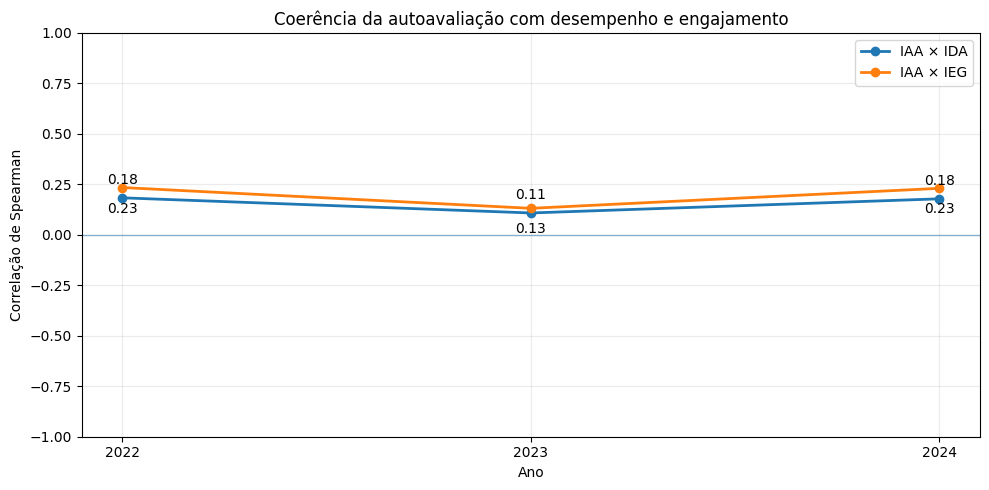

In [110]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.plot(
    correlacoes_pergunta4["Ano"],
    correlacoes_pergunta4["Spearman_IAA_IDA"],
    marker="o",
    linewidth=2,
    label="IAA × IDA"
)

ax.plot(
    correlacoes_pergunta4["Ano"],
    correlacoes_pergunta4["Spearman_IAA_IEG"],
    marker="o",
    linewidth=2,
    label="IAA × IEG"
)

for _, linha in correlacoes_pergunta4.iterrows():

    ax.annotate(
        f"{linha['Spearman_IAA_IDA']:.2f}",
        (
            linha["Ano"],
            linha["Spearman_IAA_IDA"]
        ),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center"
    )

    ax.annotate(
        f"{linha['Spearman_IAA_IEG']:.2f}",
        (
            linha["Ano"],
            linha["Spearman_IAA_IEG"]
        ),
        textcoords="offset points",
        xytext=(0, -18),
        ha="center"
    )


ax.axhline(
    0,
    linewidth=1,
    alpha=0.5
)

ax.set_title(
    "Coerência da autoavaliação com desempenho e engajamento"
)

ax.set_xlabel("Ano")
ax.set_ylabel("Correlação de Spearman")

ax.set_xticks(
    [2022, 2023, 2024]
)

ax.set_ylim(-1, 1)

ax.legend()

ax.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    OUTPUTS_DIR /
    "pergunta_04_correlacao_iaa_ida_ieg.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 7.4 Conclusão — Pergunta 4

### A autoavaliação dos alunos é coerente com desempenho e engajamento?

Após a auditoria do IAA, a análise principal utilizou uma variável analítica que
trata os valores iguais a zero de 2023 como ausentes, preservando integralmente
o campo original.

As correlações de Spearman entre autoavaliação (IAA) e desempenho acadêmico
(IDA) foram:

- **2022:** ρ = 0,183
- **2023:** ρ = 0,108
- **2024:** ρ = 0,178

Entre autoavaliação (IAA) e engajamento (IEG):

- **2022:** ρ = 0,234
- **2023:** ρ = 0,131
- **2024:** ρ = 0,230

Todas as associações são positivas e estatisticamente significativas, porém sua
magnitude é baixa.

### Resposta à pergunta de negócio

A autoavaliação apresenta alguma coerência com desempenho e engajamento, mas essa
relação é limitada.

Alunos com IAA mais elevado tendem, em média, a apresentar resultados ligeiramente
melhores em IDA e IEG, porém a associação é muito mais fraca do que aquela observada
anteriormente entre engajamento, desempenho e ponto de virada.

Portanto, o IAA não deve ser interpretado isoladamente como uma medida objetiva do
desempenho acadêmico ou do nível de engajamento.

A percepção que o estudante possui sobre sua própria trajetória pode divergir
consideravelmente dos indicadores observados.

### Insight gerencial

Essa diferença entre percepção e resultado pode ser relevante para o acompanhamento
individual.

Dois grupos merecem atenção particular:

1. estudantes com autoavaliação elevada, mas desempenho ou engajamento baixos;
2. estudantes com autoavaliação baixa, mas resultados objetivos relativamente bons.

Essas divergências podem representar oportunidades para intervenções pedagógicas,
orientação individual e acompanhamento psicopedagógico.

### Recomendação

O IAA deve ser utilizado como uma dimensão complementar da avaliação do estudante,
e não como substituto de indicadores objetivos como IDA e IEG.

Sua principal utilidade gerencial pode estar justamente na identificação de
desalinhamentos entre percepção e trajetória observada.

# 8. Pergunta 5 — Aspectos psicossociais antecedem quedas de desempenho ou engajamento?

Nesta etapa será analisado o IPS sob uma perspectiva longitudinal.

Diferentemente das análises anteriores, o objetivo não é apenas verificar se
indicadores estão associados no mesmo período, mas investigar se o estado
psicossocial observado em um ano está relacionado a mudanças posteriores no:

- desempenho acadêmico (IDA);
- engajamento (IEG).

Serão analisadas duas transições:

- **2022 → 2023**
- **2023 → 2024**

Essa abordagem permite investigar se o IPS possui potencial como indicador de
atenção antecipada, sem interpretar a associação observacional como causalidade.

In [111]:
# ============================================================
# AUDITORIA DO IPS — PERGUNTA 5
# ============================================================

resumo_ips = []

for ano, df in [
    (2022, df_2022),
    (2023, df_2023),
    (2024, df_2024)
]:

    ips = pd.to_numeric(
        df["IPS"],
        errors="coerce"
    )

    resumo_ips.append({
        "Ano": ano,
        "Registros": len(df),
        "IPS_validos": int(ips.notna().sum()),
        "IPS_nulos": int(ips.isna().sum()),
        "IPS_zero": int((ips == 0).sum()),
        "Media": round(ips.mean(), 3),
        "Mediana": round(ips.median(), 3),
        "Desvio_padrao": round(ips.std(), 3),
        "Minimo": round(ips.min(), 3),
        "Q1": round(ips.quantile(0.25), 3),
        "Q3": round(ips.quantile(0.75), 3),
        "Maximo": round(ips.max(), 3)
    })


resumo_ips = pd.DataFrame(
    resumo_ips
)

display(resumo_ips)

,Ano,Registros,IPS_validos,IPS_nulos,IPS_zero,Media,Mediana,Desvio_padrao,Minimo,Q1,Q3,Maximo
0,2022,860,860,0,0,6.905,7.50,1.071,2.50,6.30,7.50,10.0
1,2023,1014,945,69,0,5.120,5.00,2.090,2.52,2.52,7.52,10.0
2,2024,1156,1054,102,0,6.830,7.51,1.428,2.51,6.26,7.51,10.0


## 8.1 Auditoria do IPS

O IPS não apresenta concentração de valores iguais a zero em nenhum dos três anos,
portanto não foi identificada uma anomalia de preenchimento semelhante à observada
anteriormente no IAA.

Entretanto, 2023 apresenta uma mudança relevante na distribuição do indicador.

A média do IPS foi:

- **2022:** 6,91
- **2023:** 5,12
- **2024:** 6,83

A mediana caiu de **7,50 em 2022** para **5,00 em 2023**, retornando para **7,51
em 2024**.

O desvio-padrão também foi maior em 2023, indicando maior heterogeneidade dos
resultados psicossociais naquele período.

Por não haver evidência suficiente de erro de preenchimento, os valores originais
do IPS serão preservados na análise longitudinal.

## 8.2 Associação entre IPS anterior e mudança futura

Foram construídos dois painéis longitudinais:

- **2022 → 2023**
- **2023 → 2024**

A variável explicativa é o IPS observado no início de cada transição.

Os desfechos são as variações posteriores:

- `DELTA_IDA = IDA futuro - IDA anterior`
- `DELTA_IEG = IEG futuro - IEG anterior`

Valores negativos representam queda no indicador no período seguinte.

A hipótese analisada é se alunos com IPS mais baixo apresentam maior tendência de
queda posterior no desempenho acadêmico ou no engajamento.

In [112]:
# ============================================================
# PAINÉIS LONGITUDINAIS — PERGUNTA 5
# ============================================================

def preparar_transicao(
    df_origem,
    df_destino,
    ano_origem,
    ano_destino
):

    origem = df_origem[
        ["RA", "IPS", "IDA", "IEG"]
    ].copy()

    destino = df_destino[
        ["RA", "IDA", "IEG"]
    ].copy()

    # Conversão numérica
    for coluna in ["IPS", "IDA", "IEG"]:
        origem[coluna] = pd.to_numeric(
            origem[coluna],
            errors="coerce"
        )

    for coluna in ["IDA", "IEG"]:
        destino[coluna] = pd.to_numeric(
            destino[coluna],
            errors="coerce"
        )

    origem = origem.rename(
        columns={
            "IPS": f"IPS_{ano_origem}",
            "IDA": f"IDA_{ano_origem}",
            "IEG": f"IEG_{ano_origem}"
        }
    )

    destino = destino.rename(
        columns={
            "IDA": f"IDA_{ano_destino}",
            "IEG": f"IEG_{ano_destino}"
        }
    )

    painel = origem.merge(
        destino,
        on="RA",
        how="inner"
    )

    painel["DELTA_IDA"] = (
        painel[f"IDA_{ano_destino}"]
        - painel[f"IDA_{ano_origem}"]
    )

    painel["DELTA_IEG"] = (
        painel[f"IEG_{ano_destino}"]
        - painel[f"IEG_{ano_origem}"]
    )

    painel["TRANSICAO"] = (
        f"{ano_origem}→{ano_destino}"
    )

    return painel


painel_22_23 = preparar_transicao(
    df_2022,
    df_2023,
    2022,
    2023
)

painel_23_24 = preparar_transicao(
    df_2023,
    df_2024,
    2023,
    2024
)


print("=" * 70)
print("TRANSIÇÃO 2022 → 2023")
print("=" * 70)

print(
    "Alunos presentes nos dois anos:",
    len(painel_22_23)
)

print(
    "IPS + DELTA IDA válidos:",
    painel_22_23[
        ["IPS_2022", "DELTA_IDA"]
    ].dropna().shape[0]
)

print(
    "IPS + DELTA IEG válidos:",
    painel_22_23[
        ["IPS_2022", "DELTA_IEG"]
    ].dropna().shape[0]
)


print("\n" + "=" * 70)
print("TRANSIÇÃO 2023 → 2024")
print("=" * 70)

print(
    "Alunos presentes nos dois anos:",
    len(painel_23_24)
)

print(
    "IPS + DELTA IDA válidos:",
    painel_23_24[
        ["IPS_2023", "DELTA_IDA"]
    ].dropna().shape[0]
)

print(
    "IPS + DELTA IEG válidos:",
    painel_23_24[
        ["IPS_2023", "DELTA_IEG"]
    ].dropna().shape[0]
)

TRANSIÇÃO 2022 → 2023
Alunos presentes nos dois anos: 600
IPS + DELTA IDA válidos: 574
IPS + DELTA IEG válidos: 574

TRANSIÇÃO 2023 → 2024
Alunos presentes nos dois anos: 765
IPS + DELTA IDA válidos: 679
IPS + DELTA IEG válidos: 690


In [113]:
from scipy.stats import spearmanr

resultados_ips_futuro = []


# ============================================================
# 2022 -> 2023
# ============================================================

base_ida_22_23 = painel_22_23[
    ["IPS_2022", "DELTA_IDA"]
].dropna()

rho_ida_22_23, p_ida_22_23 = spearmanr(
    base_ida_22_23["IPS_2022"],
    base_ida_22_23["DELTA_IDA"]
)


base_ieg_22_23 = painel_22_23[
    ["IPS_2022", "DELTA_IEG"]
].dropna()

rho_ieg_22_23, p_ieg_22_23 = spearmanr(
    base_ieg_22_23["IPS_2022"],
    base_ieg_22_23["DELTA_IEG"]
)


resultados_ips_futuro.append({
    "Transicao": "2022→2023",
    "N_IPS_DELTA_IDA": len(base_ida_22_23),
    "Spearman_IPS_DELTA_IDA": round(rho_ida_22_23, 3),
    "p_IPS_DELTA_IDA": p_ida_22_23,
    "N_IPS_DELTA_IEG": len(base_ieg_22_23),
    "Spearman_IPS_DELTA_IEG": round(rho_ieg_22_23, 3),
    "p_IPS_DELTA_IEG": p_ieg_22_23
})


# ============================================================
# 2023 -> 2024
# ============================================================

base_ida_23_24 = painel_23_24[
    ["IPS_2023", "DELTA_IDA"]
].dropna()

rho_ida_23_24, p_ida_23_24 = spearmanr(
    base_ida_23_24["IPS_2023"],
    base_ida_23_24["DELTA_IDA"]
)


base_ieg_23_24 = painel_23_24[
    ["IPS_2023", "DELTA_IEG"]
].dropna()

rho_ieg_23_24, p_ieg_23_24 = spearmanr(
    base_ieg_23_24["IPS_2023"],
    base_ieg_23_24["DELTA_IEG"]
)


resultados_ips_futuro.append({
    "Transicao": "2023→2024",
    "N_IPS_DELTA_IDA": len(base_ida_23_24),
    "Spearman_IPS_DELTA_IDA": round(rho_ida_23_24, 3),
    "p_IPS_DELTA_IDA": p_ida_23_24,
    "N_IPS_DELTA_IEG": len(base_ieg_23_24),
    "Spearman_IPS_DELTA_IEG": round(rho_ieg_23_24, 3),
    "p_IPS_DELTA_IEG": p_ieg_23_24
})


correlacoes_ips_futuro = pd.DataFrame(
    resultados_ips_futuro
)

display(correlacoes_ips_futuro)

,Transicao,N_IPS_DELTA_IDA,Spearman_IPS_DELTA_IDA,p_IPS_DELTA_IDA,N_IPS_DELTA_IEG,Spearman_IPS_DELTA_IEG,p_IPS_DELTA_IEG
0,2022→2023,574,0.029,0.492894,574,-0.024,0.566568
1,2023→2024,679,0.027,0.477562,690,0.020,0.602768


In [114]:
correlacoes_ips_futuro_exec = correlacoes_ips_futuro[
    [
        "Transicao",
        "Spearman_IPS_DELTA_IDA",
        "Spearman_IPS_DELTA_IEG"
    ]
].copy()

display(correlacoes_ips_futuro_exec)

,Transicao,Spearman_IPS_DELTA_IDA,Spearman_IPS_DELTA_IEG
0,2022→2023,0.029,-0.024
1,2023→2024,0.027,0.020


## 8.3 Resultado da associação temporal

A associação entre o IPS observado no início do período e a variação posterior
de IDA e IEG foi muito baixa.

### Transição 2022 → 2023

- IPS × ΔIDA: **ρ = 0,029**
- IPS × ΔIEG: **ρ = -0,024**

### Transição 2023 → 2024

- IPS × ΔIDA: **ρ = 0,027**
- IPS × ΔIEG: **ρ = 0,020**

Todas as associações ficaram próximas de zero e não apresentaram significância
estatística.

Portanto, o IPS isolado não demonstrou relação monotônica relevante com a
evolução futura de desempenho acadêmico ou engajamento.

Esse resultado não elimina a possibilidade de padrões localizados nos extremos
da distribuição. Por isso, será realizada uma comparação entre estudantes com
IPS baixo e IPS alto, considerando também a ocorrência de quedas relevantes
nos indicadores.

In [115]:
# ============================================================
# EXTREMOS DO IPS E QUEDAS FUTURAS
# ============================================================

def analisar_extremos_ips(
    painel,
    coluna_ips,
    transicao
):

    base = painel[
        [coluna_ips, "DELTA_IDA", "DELTA_IEG"]
    ].copy()

    q1 = base[coluna_ips].quantile(0.25)
    q3 = base[coluna_ips].quantile(0.75)

    baixo = base.loc[
        base[coluna_ips] <= q1
    ].copy()

    alto = base.loc[
        base[coluna_ips] >= q3
    ].copy()

    resultados = []

    for grupo_nome, grupo in [
        ("IPS baixo", baixo),
        ("IPS alto", alto)
    ]:

        ida_validos = grupo["DELTA_IDA"].dropna()
        ieg_validos = grupo["DELTA_IEG"].dropna()

        resultados.append({
            "Transicao": transicao,
            "Grupo": grupo_nome,
            "Limite_Q1": round(q1, 3),
            "Limite_Q3": round(q3, 3),

            "N_IDA": len(ida_validos),
            "Delta_IDA_medio": round(
                ida_validos.mean(), 3
            ),
            "Pct_queda_IDA_1pt": round(
                (ida_validos <= -1).mean() * 100,
                2
            ),

            "N_IEG": len(ieg_validos),
            "Delta_IEG_medio": round(
                ieg_validos.mean(), 3
            ),
            "Pct_queda_IEG_1pt": round(
                (ieg_validos <= -1).mean() * 100,
                2
            )
        })

    return pd.DataFrame(resultados)


extremos_22_23 = analisar_extremos_ips(
    painel_22_23,
    "IPS_2022",
    "2022→2023"
)

extremos_23_24 = analisar_extremos_ips(
    painel_23_24,
    "IPS_2023",
    "2023→2024"
)

comparacao_extremos_ips = pd.concat(
    [
        extremos_22_23,
        extremos_23_24
    ],
    ignore_index=True
)

display(comparacao_extremos_ips)

,Transicao,Grupo,Limite_Q1,Limite_Q3,N_IDA,Delta_IDA_medio,Pct_queda_IDA_1pt,N_IEG,Delta_IEG_medio,Pct_queda_IEG_1pt
0,2022→2023,IPS baixo,5.60,7.50,148,-0.063,25.68,148,0.249,14.19
1,2022→2023,IPS alto,5.60,7.50,365,0.176,24.66,365,0.218,10.14
2,2023→2024,IPS baixo,2.52,7.52,185,-0.563,35.14,185,-0.911,34.05
3,2023→2024,IPS alto,2.52,7.52,227,-0.367,33.92,230,-0.803,33.91


## 8.4 Conclusão — Pergunta 5

### O IPS apresenta padrões que antecedem quedas futuras de IDA ou IEG?

A análise longitudinal não encontrou evidência relevante de que o IPS, quando
utilizado isoladamente, antecipe a evolução futura do desempenho acadêmico ou
do engajamento.

As correlações entre o IPS observado no início do período e a variação posterior
dos indicadores ficaram próximas de zero:

| Transição | IPS × ΔIDA | IPS × ΔIEG |
|---|---:|---:|
| 2022 → 2023 | 0,029 | -0,024 |
| 2023 → 2024 | 0,027 | 0,020 |

Nenhuma dessas associações apresentou significância estatística.

### Análise dos extremos

Também foram comparados estudantes localizados nas regiões de IPS baixo e IPS alto.

Na transição 2022 → 2023:

- queda de pelo menos 1 ponto no IDA:
  - IPS baixo: **25,68%**
  - IPS alto: **24,66%**
- queda de pelo menos 1 ponto no IEG:
  - IPS baixo: **14,19%**
  - IPS alto: **10,14%**

Na transição 2023 → 2024:

- queda de pelo menos 1 ponto no IDA:
  - IPS baixo: **35,14%**
  - IPS alto: **33,92%**
- queda de pelo menos 1 ponto no IEG:
  - IPS baixo: **34,05%**
  - IPS alto: **33,91%**

As diferenças entre os grupos são pequenas e não indicam um padrão robusto de
antecipação de queda futura.

Como existem muitos valores empatados no IPS, os grupos definidos pelos quartis
não possuem necessariamente exatamente 25% dos estudantes. Ainda assim, a
comparação entre os extremos mantém sua utilidade exploratória.

### Resposta à pergunta de negócio

Nos dados analisados, **o IPS isoladamente não se mostrou um bom sinal antecedente
de queda futura no IDA ou no IEG**.

Isso não significa que a dimensão psicossocial seja irrelevante. O resultado
indica apenas que seu valor pode estar mais relacionado à interpretação conjunta
com outros indicadores do que à previsão individual de deterioração acadêmica
ou de engajamento.

### Recomendação gerencial

O IPS não deve ser utilizado sozinho como gatilho de alerta para prever queda
futura de desempenho ou engajamento.

Sua aplicação mais adequada pode estar em modelos multivariados que combinem
aspectos psicossociais, acadêmicos, comportamentais e pedagógicos.

Essa hipótese será particularmente importante na etapa de modelagem preditiva.

In [116]:
# ============================================================
# AUDITORIA DO IPP E IAN — PERGUNTA 6
# ============================================================

resumo_ipp_ian = []

for ano, df in [
    (2022, df_2022),
    (2023, df_2023),
    (2024, df_2024)
]:

    # Verifica se IPP existe no dataframe
    ipp_existe = "IPP" in df.columns

    if ipp_existe:
        ipp = pd.to_numeric(
            df["IPP"],
            errors="coerce"
        )
    else:
        ipp = pd.Series(
            np.nan,
            index=df.index
        )

    ian = pd.to_numeric(
        df["IAN_ANALISE"],
        errors="coerce"
    )

    resumo_ipp_ian.append({
        "Ano": ano,
        "Registros": len(df),

        "IPP_existe": ipp_existe,
        "IPP_validos": int(ipp.notna().sum()),
        "IPP_nulos": int(ipp.isna().sum()),
        "IPP_media": round(ipp.mean(), 3),
        "IPP_mediana": round(ipp.median(), 3),
        "IPP_min": round(ipp.min(), 3),
        "IPP_max": round(ipp.max(), 3),

        "IAN_validos": int(ian.notna().sum()),
        "IAN_2_5": int((ian == 2.5).sum()),
        "IAN_5": int((ian == 5).sum()),
        "IAN_10": int((ian == 10).sum())
    })


resumo_ipp_ian = pd.DataFrame(
    resumo_ipp_ian
)

display(resumo_ipp_ian)

,Ano,Registros,IPP_existe,IPP_validos,IPP_nulos,IPP_media,IPP_mediana,IPP_min,IPP_max,IAN_validos,IAN_2_5,IAN_5,IAN_10
0,2022,860,False,0,860,NaN,NaN,NaN,NaN,860,28,573,259
1,2023,1014,True,938,76,7.563,7.656,3.75,9.792,1014,14,538,462
2,2024,1156,True,1054,102,7.548,7.500,2.50,10.000,1156,3,533,620


# 9. Pergunta 6 — O IPP confirma ou contradiz o diagnóstico do IAN?

O objetivo desta análise é verificar se o indicador psicopedagógico/pedagógico
(IPP) apresenta comportamento coerente com o diagnóstico de adequação de nível
representado pelo IAN.

A análise buscará identificar se alunos em situações mais críticas de defasagem
também apresentam resultados diferenciados no IPP.

Antes da comparação, será auditada a disponibilidade e a distribuição do IPP
em cada ano, pois a estrutura desse indicador não é homogênea em todo o período
analisado.

## 9.1 Disponibilidade do IPP

A auditoria mostrou que o IPP não está disponível de forma homogênea em todo o período.

- **2022:** o indicador IPP não está presente na base;
- **2023:** 938 registros válidos;
- **2024:** 1.054 registros válidos.

Para preservar a comparabilidade e evitar misturar valores observados com valores
eventualmente reconstruídos, a análise principal da Pergunta 6 será realizada
somente com **2023 e 2024**.

Uma eventual reconstrução do IPP de 2022 poderá ser utilizada apenas como análise
de sensibilidade, e não como evidência equivalente ao indicador originalmente
observado.

In [117]:
# ============================================================
# IPP POR FAIXA DE IAN — PERGUNTA 6
# ============================================================

resultados_ipp_ian = []

for ano, df in [
    (2023, df_2023),
    (2024, df_2024)
]:

    temp = df.copy()

    temp["IPP"] = pd.to_numeric(
        temp["IPP"],
        errors="coerce"
    )

    temp["IAN_ANALISE"] = pd.to_numeric(
        temp["IAN_ANALISE"],
        errors="coerce"
    )

    temp = temp.dropna(
        subset=[
            "IPP",
            "IAN_ANALISE"
        ]
    )

    resumo = (
        temp
        .groupby(
            "IAN_ANALISE"
        )
        .agg(
            Alunos=("RA", "size"),
            IPP_Medio=("IPP", "mean"),
            IPP_Mediano=("IPP", "median"),
            IPP_Desvio=("IPP", "std")
        )
        .reset_index()
    )

    resumo["Ano"] = ano

    resultados_ipp_ian.append(
        resumo
    )


ipp_por_ian = pd.concat(
    resultados_ipp_ian,
    ignore_index=True
)

ipp_por_ian[
    [
        "IPP_Medio",
        "IPP_Mediano",
        "IPP_Desvio"
    ]
] = ipp_por_ian[
    [
        "IPP_Medio",
        "IPP_Mediano",
        "IPP_Desvio"
    ]
].round(3)

display(ipp_por_ian)

,IAN_ANALISE,Alunos,IPP_Medio,IPP_Mediano,IPP_Desvio,Ano
0,2.5,14,6.957,7.578,1.228,2023
1,5.0,536,7.505,7.500,0.992,2023
2,10.0,388,7.665,7.812,0.952,2023
3,2.5,3,7.260,7.031,0.538,2024
4,5.0,533,7.417,7.500,0.931,2024
5,10.0,518,7.685,7.708,0.843,2024


## 9.2 IPP por nível de IAN

A média do IPP aumenta conforme melhora a classificação do IAN.

Em 2023:

- IAN = 2,5: IPP médio = **6,96**
- IAN = 5,0: IPP médio = **7,51**
- IAN = 10,0: IPP médio = **7,67**

Em 2024:

- IAN = 2,5: IPP médio = **7,26**
- IAN = 5,0: IPP médio = **7,42**
- IAN = 10,0: IPP médio = **7,69**

O sentido da relação é coerente com a hipótese de que alunos em melhor situação
de adequação de nível também apresentam, em média, resultados ligeiramente
superiores no IPP.

Entretanto, as diferenças são pequenas.

Além disso, o grupo mais crítico do IAN possui amostra reduzida:

- 14 alunos em 2023;
- apenas 3 alunos em 2024.

Por isso, conclusões sobre o grupo `IAN = 2,5` devem ser tratadas com cautela.

A comparação mais robusta ocorre entre os grupos `IAN = 5` e `IAN = 10`,
que possuem amostras substancialmente maiores.

In [118]:
from scipy.stats import spearmanr

resultados_ipp_ian_corr = []

for ano, df in [
    (2023, df_2023),
    (2024, df_2024)
]:

    temp = df.copy()

    temp["IPP"] = pd.to_numeric(
        temp["IPP"],
        errors="coerce"
    )

    temp["IAN_ANALISE"] = pd.to_numeric(
        temp["IAN_ANALISE"],
        errors="coerce"
    )

    base = temp[
        ["IPP", "IAN_ANALISE"]
    ].dropna()

    rho, p = spearmanr(
        base["IPP"],
        base["IAN_ANALISE"]
    )

    resultados_ipp_ian_corr.append({
        "Ano": ano,
        "N": len(base),
        "Spearman_IPP_IAN": round(rho, 3),
        "p_value": p
    })


correlacao_ipp_ian = pd.DataFrame(
    resultados_ipp_ian_corr
)

display(correlacao_ipp_ian)

,Ano,N,Spearman_IPP_IAN,p_value
0,2023,938,0.106,1.171548e-03
1,2024,1054,0.155,4.532027e-07


## 9.3 Intensidade da associação entre IPP e IAN

Além da comparação das médias, foi avaliada a intensidade da associação entre
o indicador psicopedagógico (IPP) e o indicador de adequação de nível (IAN).

A correlação de Spearman apresentou os seguintes resultados:

- **2023:** ρ = 0,106, com 938 alunos;
- **2024:** ρ = 0,155, com 1.054 alunos.

Nos dois anos, a associação é positiva e estatisticamente significativa.

Entretanto, sua magnitude é baixa.

Isso significa que alunos em melhor situação segundo o IAN tendem a apresentar
IPP ligeiramente superior, mas o IPP não reproduz de forma próxima ou automática
a classificação de adequação de nível.

Esse resultado é coerente com a análise anterior das médias: existe uma tendência
na mesma direção, porém com ampla sobreposição entre os alunos dos diferentes
níveis de IAN.

Portanto, até este ponto da análise, o IPP **confirma apenas fracamente a direção
indicada pelo IAN**.

Como os dois indicadores representam dimensões diferentes da trajetória do aluno,
uma associação fraca não deve ser interpretada automaticamente como erro ou
inconsistência.

Para responder completamente à pergunta de negócio, a próxima etapa investigará
diretamente os casos em que os dois indicadores apontam na mesma direção e os
casos em que apresentam sinais potencialmente discordantes.

In [119]:
# ============================================================
# CONCORDÂNCIAS E DISCORDÂNCIAS ENTRE IPP E IAN
# PERGUNTA 6
# ============================================================

resultados_concordancia = []

for ano, df in [
    (2023, df_2023),
    (2024, df_2024)
]:

    temp = df.copy()

    temp["IPP"] = pd.to_numeric(
        temp["IPP"],
        errors="coerce"
    )

    temp["IAN_ANALISE"] = pd.to_numeric(
        temp["IAN_ANALISE"],
        errors="coerce"
    )

    temp = temp.dropna(
        subset=["IPP", "IAN_ANALISE"]
    ).copy()

    # --------------------------------------------------------
    # IAN: situação de defasagem
    # --------------------------------------------------------

    temp["CATEGORIA_IAN"] = np.where(
        temp["IAN_ANALISE"] < 10,
        "IAN em risco",
        "IAN sem defasagem"
    )

    # --------------------------------------------------------
    # IPP: classificação operacional relativa ao próprio ano
    # Não representa um corte oficial da Passos Mágicos.
    # --------------------------------------------------------

    q1_ipp = temp["IPP"].quantile(0.25)

    temp["CATEGORIA_IPP"] = np.where(
        temp["IPP"] <= q1_ipp,
        "IPP relativamente baixo",
        "IPP não baixo"
    )

    print("\n" + "=" * 70)
    print(f"ANO {ano}")
    print("=" * 70)

    print(
        f"Q1 do IPP utilizado como limite exploratório: "
        f"{q1_ipp:.3f}"
    )

    # --------------------------------------------------------
    # Tabela de contingência
    # --------------------------------------------------------

    tabela = pd.crosstab(
        temp["CATEGORIA_IAN"],
        temp["CATEGORIA_IPP"],
        margins=True
    )

    display(tabela)

    # --------------------------------------------------------
    # Concordância / discordância operacional
    # --------------------------------------------------------

    condicoes = [
        (
            (temp["CATEGORIA_IAN"] == "IAN em risco") &
            (temp["CATEGORIA_IPP"] == "IPP relativamente baixo")
        ),
        (
            (temp["CATEGORIA_IAN"] == "IAN sem defasagem") &
            (temp["CATEGORIA_IPP"] == "IPP não baixo")
        ),
        (
            (temp["CATEGORIA_IAN"] == "IAN em risco") &
            (temp["CATEGORIA_IPP"] == "IPP não baixo")
        ),
        (
            (temp["CATEGORIA_IAN"] == "IAN sem defasagem") &
            (temp["CATEGORIA_IPP"] == "IPP relativamente baixo")
        )
    ]

    rotulos = [
        "Concordante: risco + IPP baixo",
        "Concordante: sem defasagem + IPP não baixo",
        "Discordante: risco + IPP não baixo",
        "Discordante: sem defasagem + IPP baixo"
    ]

    temp["SITUACAO_IPP_IAN"] = np.select(
        condicoes,
        rotulos,
        default="Não classificado"
    )

    resumo = (
        temp["SITUACAO_IPP_IAN"]
        .value_counts()
        .rename_axis("Situacao")
        .reset_index(name="Quantidade")
    )

    resumo["Percentual"] = (
        resumo["Quantidade"]
        / len(temp)
        * 100
    ).round(2)

    resumo["Ano"] = ano
    resumo["Q1_IPP"] = round(q1_ipp, 3)

    resultados_concordancia.append(resumo)


concordancia_ipp_ian = pd.concat(
    resultados_concordancia,
    ignore_index=True
)

print("\n" + "=" * 70)
print("RESUMO FINAL")
print("=" * 70)

display(concordancia_ipp_ian)


ANO 2023
Q1 do IPP utilizado como limite exploratório: 7.083


CATEGORIA_IPP,IPP não baixo,IPP relativamente baixo,All
CATEGORIA_IAN,,,
IAN em risco,385,165,550
IAN sem defasagem,308,80,388
All,693,245,938



ANO 2024
Q1 do IPP utilizado como limite exploratório: 7.188


CATEGORIA_IPP,IPP não baixo,IPP relativamente baixo,All
CATEGORIA_IAN,,,
IAN em risco,352,184,536
IAN sem defasagem,392,126,518
All,744,310,1054



RESUMO FINAL


,Situacao,Quantidade,Percentual,Ano,Q1_IPP
0,Discordante: risco + IPP não baixo,385,41.04,2023,7.083
1,Concordante: sem defasagem + IPP não baixo,308,32.84,2023,7.083
2,Concordante: risco + IPP baixo,165,17.59,2023,7.083
3,Discordante: sem defasagem + IPP baixo,80,8.53,2023,7.083
4,Concordante: sem defasagem + IPP não baixo,392,37.19,2024,7.188
5,Discordante: risco + IPP não baixo,352,33.40,2024,7.188
6,Concordante: risco + IPP baixo,184,17.46,2024,7.188
7,Discordante: sem defasagem + IPP baixo,126,11.95,2024,7.188


## 9.4 Concordâncias e discordâncias entre IPP e IAN

Como não existe na base analisada um ponto de corte oficial do IPP equivalente às
categorias do IAN, foi utilizada uma classificação operacional exploratória.

Foram considerados:

- **IAN em risco:** IAN < 10;
- **IAN sem defasagem:** IAN = 10;
- **IPP relativamente baixo:** valores até o primeiro quartil do IPP em cada ano;
- **IPP não baixo:** valores acima desse limite.

Os limites utilizados foram:

- **2023:** Q1 do IPP = 7,083;
- **2024:** Q1 do IPP = 7,188.

### Resultados de 2023

Entre os 938 alunos analisados:

- **17,59%** apresentaram concordância entre IAN em risco e IPP baixo;
- **32,84%** apresentaram concordância entre ausência de defasagem e IPP não baixo;
- **41,04%** apresentaram IAN em risco, mas IPP não baixo;
- **8,53%** estavam sem defasagem, mas apresentaram IPP baixo.

Considerando os dois tipos de concordância, aproximadamente **50,43%** dos casos
apresentaram sinais na mesma direção, enquanto **49,57%** apresentaram combinação
discordante.

### Resultados de 2024

Entre os 1.054 alunos analisados:

- **17,46%** apresentaram concordância entre IAN em risco e IPP baixo;
- **37,19%** apresentaram concordância entre ausência de defasagem e IPP não baixo;
- **33,40%** apresentaram IAN em risco, mas IPP não baixo;
- **11,95%** estavam sem defasagem, mas apresentaram IPP baixo.

A concordância operacional foi de aproximadamente **54,65%**, enquanto **45,35%**
dos casos apresentaram combinações discordantes.

### Interpretação

Os resultados mostram que existe alguma coerência entre os indicadores, mas ela
está longe de ser completa.

Entre os estudantes classificados como em risco pelo IAN, somente cerca de:

- **30,0% em 2023**;
- **34,3% em 2024**

também pertenciam ao grupo de IPP relativamente baixo.

Ao mesmo tempo, parte dos estudantes sem defasagem apresentou IPP baixo:

- **20,6% em 2023**;
- **24,3% em 2024**.

Essas combinações não devem ser interpretadas automaticamente como erro ou
contradição dos dados.

O IAN representa adequação entre fase efetiva e fase esperada, enquanto o IPP
representa uma dimensão psicopedagógica distinta.

Portanto, diferenças entre os dois indicadores podem revelar perfis de alunos
que merecem análise individual, e não necessariamente inconsistências.

## 9.5 Conclusão — Pergunta 6

### O IPP confirma ou contradiz o diagnóstico do IAN?

Os resultados indicam que o IPP **confirma apenas parcialmente e de forma fraca**
a direção apontada pelo IAN.

A média do IPP aumenta conforme melhora a situação do IAN, e a correlação de
Spearman é positiva nos dois anos analisados:

- **2023:** ρ = 0,106;
- **2024:** ρ = 0,155.

Entretanto, a associação é fraca e a análise de concordância mostra ampla
sobreposição entre os grupos.

A concordância operacional foi de:

- **50,43% em 2023**;
- **54,65% em 2024**.

Isso significa que aproximadamente metade dos estudantes apresenta combinações
em que IAN e IPP não apontam para a mesma direção segundo o critério exploratório
utilizado.

### Resposta à pergunta de negócio

O IPP não contradiz sistematicamente o IAN, mas também não funciona como uma
confirmação direta do diagnóstico de defasagem.

Os indicadores devem ser interpretados como dimensões complementares:

- o **IAN** identifica adequação do aluno à fase esperada;
- o **IPP** acrescenta uma leitura psicopedagógica da trajetória.

A principal informação gerencial está justamente nos casos em que os dois
indicadores divergem.

Alunos com defasagem e IPP relativamente alto podem apresentar recursos
psicopedagógicos favoráveis apesar da inadequação de fase.

Por outro lado, alunos sem defasagem e com IPP relativamente baixo podem demandar
atenção mesmo quando o IAN não indica risco.

### Recomendação gerencial

IAN e IPP não devem ser utilizados como indicadores substitutos.

A recomendação é combinar as duas dimensões para priorização do acompanhamento,
principalmente nos casos de discordância.

Esses casos podem revelar necessidades que não seriam identificadas por uma
análise baseada exclusivamente em defasagem.

# 10. Pergunta 7 — Quais comportamentos estão mais associados ao ponto de virada?

O IPV representa o indicador de ponto de virada na trajetória do estudante.

Nesta análise, será investigado quais dimensões do desenvolvimento apresentam
maior associação com o ponto de virada:

- **IDA:** desempenho acadêmico;
- **IEG:** engajamento;
- **IAA:** autoavaliação;
- **IPS:** aspectos psicossociais;
- **IPP:** aspectos psicopedagógicos.

Como a base também possui uma variável indicando se o estudante atingiu ou não
o ponto de virada, serão utilizadas duas perspectivas complementares:

1. comparação dos indicadores entre alunos que atingiram e não atingiram o ponto
   de virada;
2. análise da associação e da importância relativa dos indicadores em relação ao IPV.

Posteriormente, também será investigada a dimensão longitudinal, verificando se
comportamentos observados anteriormente estão relacionados ao ponto de virada
em períodos posteriores.

Como se trata de uma base observacional, os resultados serão interpretados como
associações e não como evidência de causalidade.

In [120]:
# ============================================================
# AUDITORIA DO IPV E DA FLAG "ATINGIU PV" — PERGUNTA 7
# ============================================================

resumo_pv = []

for ano, df in [
    (2022, df_2022),
    (2023, df_2023),
    (2024, df_2024)
]:

    print("\n" + "=" * 70)
    print(f"ANO {ano}")
    print("=" * 70)

    # --------------------------------------------------------
    # Existência das colunas
    # --------------------------------------------------------

    tem_flag = "Atingiu PV" in df.columns
    tem_ipv = "IPV" in df.columns

    print("Coluna 'Atingiu PV' existe:", tem_flag)
    print("Coluna 'IPV' existe:", tem_ipv)

    if tem_flag:

        print("\nDistribuição de Atingiu PV:")

        display(
            df["Atingiu PV"]
            .value_counts(dropna=False)
            .rename("Quantidade")
            .to_frame()
        )

    if tem_ipv:

        ipv = pd.to_numeric(
            df["IPV"],
            errors="coerce"
        )

        resumo_pv.append({
            "Ano": ano,
            "Registros": len(df),

            "IPV_validos": int(ipv.notna().sum()),
            "IPV_nulos": int(ipv.isna().sum()),
            "IPV_zero": int((ipv == 0).sum()),

            "IPV_media": round(ipv.mean(), 3),
            "IPV_mediana": round(ipv.median(), 3),
            "IPV_desvio": round(ipv.std(), 3),

            "IPV_min": round(ipv.min(), 3),
            "IPV_Q1": round(ipv.quantile(0.25), 3),
            "IPV_Q3": round(ipv.quantile(0.75), 3),
            "IPV_max": round(ipv.max(), 3)
        })


resumo_pv = pd.DataFrame(
    resumo_pv
)

print("\n" + "=" * 70)
print("RESUMO DO IPV")
print("=" * 70)

display(resumo_pv)


ANO 2022
Coluna 'Atingiu PV' existe: True
Coluna 'IPV' existe: True

Distribuição de Atingiu PV:


,Quantidade
Atingiu PV,
Não,747
Sim,113



ANO 2023
Coluna 'Atingiu PV' existe: True
Coluna 'IPV' existe: True

Distribuição de Atingiu PV:


,Quantidade
Atingiu PV,
NaN,1014



ANO 2024
Coluna 'Atingiu PV' existe: True
Coluna 'IPV' existe: True

Distribuição de Atingiu PV:


,Quantidade
Atingiu PV,
NaN,1156



RESUMO DO IPV


,Ano,Registros,IPV_validos,IPV_nulos,IPV_zero,IPV_media,IPV_mediana,IPV_desvio,IPV_min,IPV_Q1,IPV_Q3,IPV_max
0,2022,860,860,0,0,7.254,7.333,1.093,2.500,6.722,7.917,10.00
1,2023,1014,938,76,0,8.028,8.045,0.945,3.320,7.462,8.669,10.01
2,2024,1156,1054,102,0,7.354,7.500,1.049,2.943,6.791,8.085,9.76


In [121]:
# ============================================================
# IPV MÉDIO SEGUNDO A FLAG "ATINGIU PV"
# ============================================================

resumo_ipv_flag = []

for ano, df in [
    (2022, df_2022),
    (2023, df_2023),
    (2024, df_2024)
]:

    if (
        "Atingiu PV" not in df.columns
        or "IPV" not in df.columns
    ):
        continue

    temp = df[
        ["RA", "Atingiu PV", "IPV"]
    ].copy()

    temp["IPV"] = pd.to_numeric(
        temp["IPV"],
        errors="coerce"
    )

    resumo = (
        temp
        .groupby(
            "Atingiu PV",
            dropna=False
        )
        .agg(
            Alunos=("RA", "size"),
            IPV_validos=("IPV", "count"),
            IPV_medio=("IPV", "mean"),
            IPV_mediano=("IPV", "median"),
            IPV_min=("IPV", "min"),
            IPV_max=("IPV", "max")
        )
        .reset_index()
    )

    resumo["Ano"] = ano

    resumo_ipv_flag.append(
        resumo
    )


resumo_ipv_flag = pd.concat(
    resumo_ipv_flag,
    ignore_index=True
)

for coluna in [
    "IPV_medio",
    "IPV_mediano",
    "IPV_min",
    "IPV_max"
]:
    resumo_ipv_flag[coluna] = (
        resumo_ipv_flag[coluna]
        .round(3)
    )

display(resumo_ipv_flag)

,Atingiu PV,Alunos,IPV_validos,IPV_medio,IPV_mediano,IPV_min,IPV_max,Ano
0,Não,747,747,7.011,7.250,2.500,8.333,2022
1,Sim,113,113,8.856,8.722,8.375,10.000,2022
2,NaN,1014,938,8.028,8.045,3.320,10.010,2023
3,NaN,1156,1054,7.354,7.500,2.943,9.760,2024


## 10.1 Auditoria do IPV e da flag de Ponto de Virada

A base possui duas representações relacionadas ao ponto de virada:

- o indicador numérico `IPV`;
- a flag categórica `Atingiu PV`.

Entretanto, a disponibilidade da flag não é homogênea entre os anos.

Em 2022:

- **747 alunos** foram classificados como `Não`;
- **113 alunos** foram classificados como `Sim`.

Já em 2023 e 2024, a coluna `Atingiu PV` está integralmente ausente.

Por outro lado, o IPV numérico possui boa cobertura:

- **2022:** 860 registros válidos;
- **2023:** 938 registros válidos;
- **2024:** 1.054 registros válidos.

Em 2022, a flag apresenta forte coerência com o IPV numérico:

- grupo `Não`: IPV máximo = **8,333**;
- grupo `Sim`: IPV mínimo = **8,375**.

Existe, portanto, separação completa entre os grupos naquele ano.

Entretanto, como não foi identificado na documentação analisada um ponto de corte
oficial que permita reconstruir a flag nos anos posteriores, não será criado um
`Atingiu PV` artificial para 2023 ou 2024.

### Estratégia analítica

A Pergunta 7 será respondida utilizando duas abordagens complementares:

1. **2022:** a flag oficial `Atingiu PV` será utilizada para comparar o perfil dos
   estudantes que atingiram ou não o ponto de virada;
2. **2022–2024:** o IPV numérico será utilizado para analisar quais indicadores
   apresentam maior associação com o ponto de virada ao longo do período.

Posteriormente, será utilizada também uma perspectiva longitudinal, comparando
indicadores de um ano com o IPV observado no ano seguinte.

Como o IPV incorpora dimensões relacionadas ao progresso acadêmico, engajamento e
desenvolvimento emocional, os resultados serão interpretados como associações e
não como evidência causal.

## 10.2 Perfil dos alunos que atingiram o Ponto de Virada em 2022

Como a flag oficial `Atingiu PV` está disponível apenas em 2022, este ano será
utilizado para uma primeira comparação direta entre alunos que atingiram e que não
atingiram o ponto de virada.

Serão comparadas quatro dimensões disponíveis no período:

- desempenho acadêmico (IDA);
- engajamento (IEG);
- autoavaliação (IAA);
- aspectos psicossociais (IPS).

O IPP não será incluído nesta etapa porque não está disponível como indicador
observado na base de 2022.

In [122]:
# ============================================================
# PERFIL DOS ALUNOS QUE ATINGIRAM O PV — 2022
# ============================================================

variaveis_pv_2022 = [
    "IDA",
    "IEG",
    "IAA",
    "IPS"
]

base_pv_2022 = df_2022[
    ["RA", "Atingiu PV"] + variaveis_pv_2022
].copy()


for coluna in variaveis_pv_2022:
    base_pv_2022[coluna] = pd.to_numeric(
        base_pv_2022[coluna],
        errors="coerce"
    )


resultados_perfil_pv = []

for indicador in variaveis_pv_2022:

    for grupo in ["Não", "Sim"]:

        serie = (
            base_pv_2022.loc[
                base_pv_2022["Atingiu PV"] == grupo,
                indicador
            ]
            .dropna()
        )

        resultados_perfil_pv.append({
            "Indicador": indicador,
            "Atingiu_PV": grupo,
            "N": len(serie),
            "Media": round(serie.mean(), 3),
            "Mediana": round(serie.median(), 3),
            "Desvio": round(serie.std(), 3)
        })


perfil_pv_2022 = pd.DataFrame(
    resultados_perfil_pv
)

display(perfil_pv_2022)


# ------------------------------------------------------------
# Diferença direta Sim - Não
# ------------------------------------------------------------

medias_pv = (
    perfil_pv_2022
    .pivot(
        index="Indicador",
        columns="Atingiu_PV",
        values="Media"
    )
    .reset_index()
)

medias_pv["Diferenca_Sim_menos_Nao"] = (
    medias_pv["Sim"]
    - medias_pv["Não"]
).round(3)

medias_pv = medias_pv.sort_values(
    "Diferenca_Sim_menos_Nao",
    ascending=False
)

display(medias_pv)

,Indicador,Atingiu_PV,N,Media,Mediana,Desvio
0,IDA,Não,747,5.824,6.0,2.028
1,IDA,Sim,113,7.869,7.9,1.021
2,IEG,Não,747,7.722,8.1,1.668
3,IEG,Sim,113,9.012,9.2,0.776
4,IAA,Não,747,8.185,8.8,2.124
5,IAA,Sim,113,8.867,9.2,1.496
6,IPS,Não,747,6.843,7.5,1.057
7,IPS,Sim,113,7.315,7.5,1.075


Atingiu_PV,Indicador,Não,Sim,Diferenca_Sim_menos_Nao
1,IDA,5.824,7.869,2.045
2,IEG,7.722,9.012,1.290
0,IAA,8.185,8.867,0.682
3,IPS,6.843,7.315,0.472


### 10.2.1 Diferenças observadas entre os grupos

A comparação inicial mostra que os estudantes que atingiram o ponto de virada em
2022 apresentaram médias superiores em todas as dimensões analisadas.

As diferenças entre o grupo `Sim` e o grupo `Não` foram:

- **IDA:** +2,045 pontos;
- **IEG:** +1,290 pontos;
- **IAA:** +0,682 ponto;
- **IPS:** +0,472 ponto.

Em valores absolutos, desempenho acadêmico e engajamento apresentam as maiores
diferenças entre os grupos.

Entretanto, a diferença de médias isoladamente não é suficiente para determinar
qual indicador possui maior poder de diferenciação, pois cada variável apresenta
uma dispersão distinta.

Além disso, os grupos possuem tamanhos diferentes: 113 estudantes atingiram o
ponto de virada e 747 não atingiram.

Por isso, será calculado também um tamanho de efeito padronizado, permitindo
comparar a magnitude das diferenças considerando a variabilidade de cada
indicador.

,Indicador,Hedges_g,Magnitude_absoluta
0,IDA,1.060,1.060
1,IEG,0.816,0.816
2,IPS,0.445,0.445
3,IAA,0.332,0.332


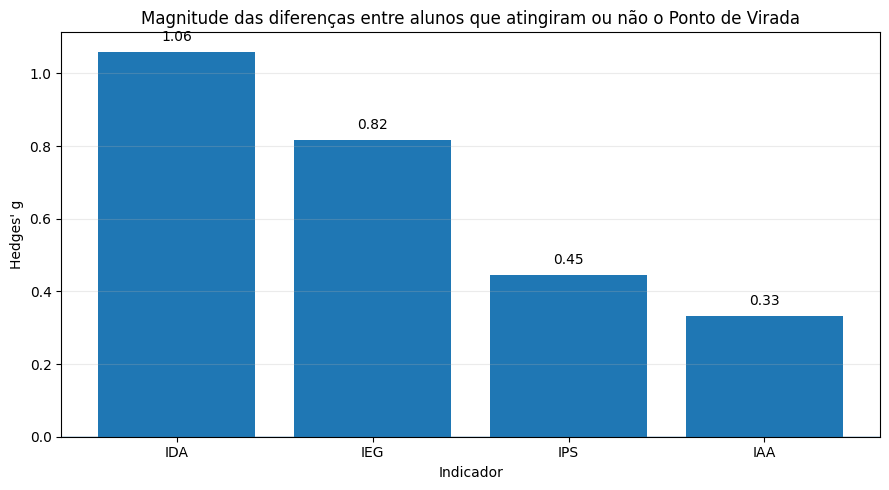

In [123]:
# ============================================================
# TAMANHO DE EFEITO — PONTO DE VIRADA 2022
# Hedges' g
# ============================================================

import numpy as np
import pandas as pd


def hedges_g(grupo_sim, grupo_nao):

    sim = pd.to_numeric(
        grupo_sim,
        errors="coerce"
    ).dropna()

    nao = pd.to_numeric(
        grupo_nao,
        errors="coerce"
    ).dropna()

    n_sim = len(sim)
    n_nao = len(nao)

    var_sim = sim.var(ddof=1)
    var_nao = nao.var(ddof=1)

    # Desvio-padrão combinado
    pooled_sd = np.sqrt(
        (
            (n_sim - 1) * var_sim
            + (n_nao - 1) * var_nao
        )
        /
        (n_sim + n_nao - 2)
    )

    # Cohen's d
    d = (
        sim.mean() - nao.mean()
    ) / pooled_sd

    # Correção de Hedges
    correcao = (
        1
        - 3
        / (
            4 * (n_sim + n_nao)
            - 9
        )
    )

    g = d * correcao

    return g


resultados_efeito_pv = []

for indicador in [
    "IDA",
    "IEG",
    "IAA",
    "IPS"
]:

    grupo_sim = base_pv_2022.loc[
        base_pv_2022["Atingiu PV"] == "Sim",
        indicador
    ]

    grupo_nao = base_pv_2022.loc[
        base_pv_2022["Atingiu PV"] == "Não",
        indicador
    ]

    g = hedges_g(
        grupo_sim,
        grupo_nao
    )

    resultados_efeito_pv.append({
        "Indicador": indicador,
        "Hedges_g": round(g, 3),
        "Magnitude_absoluta": round(abs(g), 3)
    })


efeito_pv_2022 = (
    pd.DataFrame(resultados_efeito_pv)
    .sort_values(
        "Magnitude_absoluta",
        ascending=False
    )
    .reset_index(drop=True)
)

display(efeito_pv_2022)


# ============================================================
# GRÁFICO
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.bar(
    efeito_pv_2022["Indicador"],
    efeito_pv_2022["Hedges_g"]
)

for i, valor in enumerate(
    efeito_pv_2022["Hedges_g"]
):
    ax.text(
        i,
        valor + 0.03,
        f"{valor:.2f}",
        ha="center"
    )

ax.axhline(
    0,
    linewidth=1
)

ax.set_title(
    "Magnitude das diferenças entre alunos que atingiram ou não o Ponto de Virada"
)

ax.set_xlabel(
    "Indicador"
)

ax.set_ylabel(
    "Hedges' g"
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    OUTPUTS_DIR /
    "pergunta_07_tamanho_efeito_pv_2022.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 10.2.2 Tamanho de efeito padronizado

Como os indicadores possuem dispersões diferentes, foi utilizado o Hedges' g para
comparar a magnitude das diferenças entre os estudantes que atingiram e que não
atingiram o ponto de virada.

Os resultados foram:

- **IDA:** g = 1,060
- **IEG:** g = 0,816
- **IPS:** g = 0,445
- **IAA:** g = 0,332

Os maiores efeitos foram observados em **desempenho acadêmico (IDA)** e
**engajamento (IEG)**.

Os dois indicadores apresentam efeito de grande magnitude, mostrando uma
separação substancial entre os estudantes que atingiram e que não atingiram o
ponto de virada em 2022.

O IPS apresentou efeito menor, porém ainda relevante, enquanto o IAA apresentou
a menor diferenciação padronizada entre os quatro indicadores.

Um resultado adicional aparece quando as diferenças são padronizadas: embora a
diferença bruta de médias do IAA seja maior que a do IPS, o IPS apresenta tamanho
de efeito superior após considerar a variabilidade de cada indicador.

### Síntese do perfil de 2022

Considerando conjuntamente as diferenças de médias e os tamanhos de efeito, o
perfil associado ao ponto de virada em 2022 apresenta a seguinte ordem de
diferenciação:

1. **IDA — desempenho acadêmico**
2. **IEG — engajamento**
3. **IPS — aspectos psicossociais**
4. **IAA — autoavaliação**

Portanto, desempenho acadêmico e engajamento aparecem como as dimensões que mais
diferenciam os alunos que atingiram o ponto de virada naquele ano.

Esse resultado representa associação e capacidade de diferenciação entre grupos,
não evidência de causalidade. Além disso, o próprio conceito do IPV considera
dimensões relacionadas ao progresso acadêmico, engajamento e desenvolvimento
emocional, o que deve ser considerado na interpretação dos resultados.

## 10.3 Associação dos indicadores com o IPV entre 2022 e 2024

A análise anterior utilizou a flag oficial de ponto de virada, disponível somente
em 2022.

Para avaliar se o padrão encontrado se mantém ao longo do tempo, será utilizado
agora o IPV numérico, disponível nos três anos analisados.

Será medida a associação entre IPV e:

- desempenho acadêmico (IDA);
- engajamento (IEG);
- autoavaliação (IAA);
- aspectos psicossociais (IPS);
- aspectos psicopedagógicos (IPP), quando disponível.

Será utilizada a correlação de Spearman, permitindo comparar a força e a direção
das associações sem assumir relação linear ou distribuição normal.

O IPP não está disponível como indicador observado em 2022 e, portanto, será
avaliado somente em 2023 e 2024.

Para o IAA será utilizada a variável `IAA_ANALISE`, preservando o tratamento
metodológico definido anteriormente para os zeros anômalos de 2023.

In [124]:
# ============================================================
# CORRELAÇÕES DOS INDICADORES COM IPV — 2022 A 2024
# PERGUNTA 7
# ============================================================

from scipy.stats import spearmanr

resultados_corr_ipv = []

for ano, df in [
    (2022, df_2022),
    (2023, df_2023),
    (2024, df_2024)
]:

    temp = df.copy()

    # IPV
    temp["IPV"] = pd.to_numeric(
        temp["IPV"],
        errors="coerce"
    )

    # Indicadores comuns aos três anos
    temp["IDA"] = pd.to_numeric(
        temp["IDA"],
        errors="coerce"
    )

    temp["IEG"] = pd.to_numeric(
        temp["IEG"],
        errors="coerce"
    )

    temp["IPS"] = pd.to_numeric(
        temp["IPS"],
        errors="coerce"
    )

    # IAA analítico já definido anteriormente
    temp["IAA_ANALISE"] = pd.to_numeric(
        temp["IAA_ANALISE"],
        errors="coerce"
    )

    variaveis = {
        "IDA": "IDA",
        "IEG": "IEG",
        "IAA": "IAA_ANALISE",
        "IPS": "IPS"
    }

    # IPP existe apenas nos anos em que foi observado
    if "IPP" in temp.columns:
        temp["IPP"] = pd.to_numeric(
            temp["IPP"],
            errors="coerce"
        )

        variaveis["IPP"] = "IPP"

    # --------------------------------------------------------
    # Correlação de cada indicador com IPV
    # --------------------------------------------------------

    for indicador, coluna in variaveis.items():

        base = temp[
            [coluna, "IPV"]
        ].dropna()

        rho, p = spearmanr(
            base[coluna],
            base["IPV"]
        )

        resultados_corr_ipv.append({
            "Ano": ano,
            "Indicador": indicador,
            "N": len(base),
            "Spearman_com_IPV": round(rho, 3),
            "p_value": p
        })


correlacoes_ipv = pd.DataFrame(
    resultados_corr_ipv
)

display(correlacoes_ipv)

,Ano,Indicador,N,Spearman_com_IPV,p_value
0,2022,IDA,860,0.624,6.692852e-94
1,2022,IEG,860,0.540,2.375997e-66
2,2022,IAA,860,0.245,3.469785e-13
3,2022,IPS,860,0.190,1.989953e-08
4,2023,IDA,937,0.551,1.332686e-75
5,2023,IEG,938,0.492,2.432733e-58
6,2023,IAA,751,0.145,6.710216e-05
7,2023,IPS,932,0.072,2.697740e-02
8,2023,IPP,938,0.512,6.437994e-64
9,2024,IDA,1054,0.548,1.155408e-83


In [125]:
correlacoes_ipv_pivot = (
    correlacoes_ipv
    .pivot(
        index="Indicador",
        columns="Ano",
        values="Spearman_com_IPV"
    )
)

display(
    correlacoes_ipv_pivot
    .round(3)
)

Ano,2022,2023,2024
Indicador,,,
IAA,0.245,0.145,0.163
IDA,0.624,0.551,0.548
IEG,0.540,0.492,0.551
IPP,NaN,0.512,0.705
IPS,0.190,0.072,0.042


### 10.3.1 Interpretação das associações contemporâneas

A associação entre os indicadores e o IPV apresenta diferenças relevantes entre
as dimensões analisadas.

### Desempenho acadêmico — IDA

O IDA apresenta associação positiva moderada a forte com o IPV em todos os anos:

- **2022:** ρ = 0,624
- **2023:** ρ = 0,551
- **2024:** ρ = 0,548

O padrão é consistente ao longo do período, indicando que estudantes com melhor
desempenho acadêmico tendem também a apresentar maior indicador de ponto de virada.

### Engajamento — IEG

O engajamento também apresenta relação positiva e relativamente estável:

- **2022:** ρ = 0,540
- **2023:** ρ = 0,492
- **2024:** ρ = 0,551

Portanto, o IEG aparece como uma das dimensões mais consistentemente associadas
ao IPV ao longo dos três anos.

### Aspectos psicopedagógicos — IPP

O IPP está disponível como indicador observado somente em 2023 e 2024.

Sua associação com o IPV foi:

- **2023:** ρ = 0,512
- **2024:** ρ = 0,705

Em 2024, o IPP apresentou a maior associação com IPV entre todos os indicadores
analisados.

Esse resultado sugere forte proximidade entre a avaliação psicopedagógica e o
ponto de virada naquele período, embora não permita estabelecer relação causal.

### Autoavaliação — IAA

A associação entre autoavaliação e IPV foi positiva, mas fraca:

- **2022:** ρ = 0,245
- **2023:** ρ = 0,145
- **2024:** ρ = 0,163

O resultado reforça a evidência encontrada anteriormente de que a percepção do
próprio estudante não acompanha de forma próxima os indicadores objetivos de sua
trajetória.

### Aspectos psicossociais — IPS

O IPS apresentou as menores associações:

- **2022:** ρ = 0,190
- **2023:** ρ = 0,072
- **2024:** ρ = 0,042

Em 2024, a associação não apresentou significância estatística.

Portanto, o IPS isoladamente não aparece como uma dimensão fortemente relacionada
ao IPV contemporâneo.

### Síntese

Considerando as associações observadas no mesmo período:

1. **IDA e IEG** apresentam relação consistente com IPV nos três anos;
2. **IPP** ganha destaque em 2023 e principalmente em 2024;
3. **IAA** apresenta associação baixa;
4. **IPS** apresenta associação muito baixa e perde força ao longo do período.

Entretanto, essas correlações são contemporâneas.

Como o próprio IPV está conceitualmente relacionado ao progresso acadêmico,
engajamento e desenvolvimento do estudante, essas associações não devem ser
interpretadas como prova de que os indicadores causam o ponto de virada.

Para responder de forma mais adequada à expressão "ao longo do tempo", será
realizada a seguir uma análise defasada, utilizando indicadores de um ano para
avaliar sua associação com o IPV do ano seguinte.

## 10.4 Perspectiva longitudinal — indicadores anteriores e IPV futuro

As análises anteriores mostram quais indicadores estão associados ao IPV no mesmo
período.

Entretanto, a pergunta de negócio também envolve a expressão "ao longo do tempo".

Para aproximar a análise de uma perspectiva temporal, serão avaliadas duas
transições:

- indicadores de **2022 → IPV de 2023**;
- indicadores de **2023 → IPV de 2024**.

Essa abordagem permite verificar se características observadas anteriormente
estão relacionadas ao ponto de virada registrado no período seguinte.

A análise continua sendo observacional e não estabelece causalidade, mas reduz a
ambiguidade existente quando indicador e IPV são observados simultaneamente.

In [126]:
# ============================================================
# INDICADORES DO ANO ANTERIOR × IPV FUTURO
# PERGUNTA 7
# ============================================================

from scipy.stats import spearmanr

resultados_ipv_futuro = []


def correlacionar_com_ipv_futuro(
    df_origem,
    df_destino,
    ano_origem,
    ano_destino,
    incluir_ipp=False
):

    # --------------------------------------------------------
    # Variáveis disponíveis no ano de origem
    # --------------------------------------------------------

    colunas = [
        "RA",
        "IDA",
        "IEG",
        "IAA_ANALISE",
        "IPS"
    ]

    if incluir_ipp:
        colunas.append("IPP")

    origem = df_origem[
        colunas
    ].copy()

    destino = df_destino[
        ["RA", "IPV"]
    ].copy()

    # --------------------------------------------------------
    # Conversão numérica
    # --------------------------------------------------------

    variaveis = [
        "IDA",
        "IEG",
        "IAA_ANALISE",
        "IPS"
    ]

    if incluir_ipp:
        variaveis.append("IPP")

    for coluna in variaveis:
        origem[coluna] = pd.to_numeric(
            origem[coluna],
            errors="coerce"
        )

    destino["IPV"] = pd.to_numeric(
        destino["IPV"],
        errors="coerce"
    )

    # --------------------------------------------------------
    # Painel longitudinal
    # --------------------------------------------------------

    painel = origem.merge(
        destino,
        on="RA",
        how="inner"
    )

    mapa_nomes = {
        "IDA": "IDA",
        "IEG": "IEG",
        "IAA_ANALISE": "IAA",
        "IPS": "IPS",
        "IPP": "IPP"
    }

    # --------------------------------------------------------
    # Correlações
    # --------------------------------------------------------

    for coluna in variaveis:

        base = painel[
            [coluna, "IPV"]
        ].dropna()

        rho, p = spearmanr(
            base[coluna],
            base["IPV"]
        )

        resultados_ipv_futuro.append({
            "Transicao": f"{ano_origem}→{ano_destino}",
            "Indicador_origem": mapa_nomes[coluna],
            "N": len(base),
            "Spearman_com_IPV_futuro": round(rho, 3),
            "p_value": p
        })


# 2022 -> 2023
# IPP observado não existe em 2022
correlacionar_com_ipv_futuro(
    df_2022,
    df_2023,
    2022,
    2023,
    incluir_ipp=False
)


# 2023 -> 2024
correlacionar_com_ipv_futuro(
    df_2023,
    df_2024,
    2023,
    2024,
    incluir_ipp=True
)


correlacoes_ipv_futuro = pd.DataFrame(
    resultados_ipv_futuro
)

display(correlacoes_ipv_futuro)


# ------------------------------------------------------------
# Tabela comparativa
# ------------------------------------------------------------

correlacoes_ipv_futuro_pivot = (
    correlacoes_ipv_futuro
    .pivot(
        index="Indicador_origem",
        columns="Transicao",
        values="Spearman_com_IPV_futuro"
    )
)

display(
    correlacoes_ipv_futuro_pivot
    .round(3)
)

,Transicao,Indicador_origem,N,Spearman_com_IPV_futuro,p_value
0,2022→2023,IDA,574,0.417,1.332023e-25
1,2022→2023,IEG,574,0.412,6.321942e-25
2,2022→2023,IAA,574,0.181,1.287640e-05
3,2022→2023,IPS,574,0.189,4.905945e-06
4,2023→2024,IDA,681,0.400,1.390721e-27
5,2023→2024,IEG,681,0.387,8.206530e-26
6,2023→2024,IAA,557,0.002,9.623227e-01
7,2023→2024,IPS,689,0.069,6.870187e-02
8,2023→2024,IPP,681,0.354,1.574806e-21


Transicao,2022→2023,2023→2024
Indicador_origem,,
IAA,0.181,0.002
IDA,0.417,0.400
IEG,0.412,0.387
IPP,NaN,0.354
IPS,0.189,0.069


### 10.4.1 Interpretação longitudinal

Quando os indicadores são observados antes do IPV, o padrão encontrado nas análises
contemporâneas se torna mais seletivo.

### Transição 2022 → 2023

As associações com o IPV do ano seguinte foram:

- **IDA:** ρ = 0,417
- **IEG:** ρ = 0,412
- **IPS:** ρ = 0,189
- **IAA:** ρ = 0,181

IDA e IEG apresentam as associações mais elevadas e praticamente equivalentes,
enquanto IAA e IPS possuem relações consideravelmente menores.

### Transição 2023 → 2024

As associações foram:

- **IDA:** ρ = 0,400
- **IEG:** ρ = 0,387
- **IPP:** ρ = 0,354
- **IPS:** ρ = 0,069
- **IAA:** ρ = 0,002

Novamente, desempenho acadêmico e engajamento aparecem como os indicadores mais
consistentemente associados ao IPV futuro.

O IPP também apresenta associação relevante, porém sua relação longitudinal
(ρ = 0,354) é consideravelmente inferior à associação contemporânea observada em
2024 (ρ = 0,705).

Essa diferença mostra que uma associação elevada no mesmo período não implica,
necessariamente, a mesma capacidade de antecipar resultados posteriores.

### Autoavaliação e aspectos psicossociais

IAA e IPS apresentam comportamento menos consistente ao longo do tempo.

Na transição 2022 → 2023, ambos possuem associações positivas, porém fracas.

Na transição 2023 → 2024:

- o IAA apresenta associação praticamente nula (ρ = 0,002);
- o IPS apresenta associação muito baixa (ρ = 0,069).

Nessa segunda transição, essas duas associações também não apresentam evidência
estatística relevante.

### Síntese longitudinal

A análise temporal reforça principalmente duas dimensões:

1. **desempenho acadêmico (IDA);**
2. **engajamento (IEG).**

Esses indicadores apresentam as associações mais fortes e, principalmente, mais
estáveis com o IPV futuro nas duas transições disponíveis.

O IPP também apresenta sinal longitudinal relevante em 2023 → 2024, mas com menor
intensidade que sua relação contemporânea.

Portanto, IDA e IEG aparecem como os sinais comportamentais mais consistentes ao
longo do tempo, enquanto IAA e IPS, isoladamente, demonstram menor capacidade de
antecipação do IPV.

Os resultados continuam sendo observacionais e não estabelecem relação causal.

## 10.5 Importância relativa dos indicadores

As correlações longitudinais analisam cada indicador separadamente.

Para verificar quais dimensões mantêm maior relevância quando consideradas
simultaneamente, será utilizado um modelo exploratório multivariado.

O objetivo desta etapa não é construir o modelo preditivo final do Datathon, que
será desenvolvido separadamente para risco de defasagem.

Aqui, o modelo é utilizado apenas como ferramenta de interpretação da Pergunta 7.

Serão utilizados os indicadores observados em 2023:

- IDA;
- IEG;
- IAA;
- IPS;
- IPP.

O alvo será o **IPV observado em 2024**.

Dessa forma, as variáveis explicativas precedem temporalmente o resultado.

A importância será calculada por permutation importance em um conjunto de teste,
reduzindo o risco de interpretar como relevante uma variável que apenas ajustou
ruído no conjunto de treinamento.

In [127]:
# ============================================================
# IMPORTÂNCIA RELATIVA — INDICADORES 2023 → IPV 2024
# PERGUNTA 7
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

# ------------------------------------------------------------
# Construção do painel longitudinal
# ------------------------------------------------------------

features_2023 = df_2023[
    [
        "RA",
        "IDA",
        "IEG",
        "IAA_ANALISE",
        "IPS",
        "IPP"
    ]
].copy()

target_2024 = df_2024[
    ["RA", "IPV"]
].copy()


features_2023 = features_2023.rename(
    columns={
        "IAA_ANALISE": "IAA"
    }
)


for coluna in [
    "IDA",
    "IEG",
    "IAA",
    "IPS",
    "IPP"
]:
    features_2023[coluna] = pd.to_numeric(
        features_2023[coluna],
        errors="coerce"
    )


target_2024["IPV"] = pd.to_numeric(
    target_2024["IPV"],
    errors="coerce"
)


painel_importancia = (
    features_2023
    .merge(
        target_2024,
        on="RA",
        how="inner"
    )
    .dropna(
        subset=["IPV"]
    )
)


variaveis_modelo = [
    "IDA",
    "IEG",
    "IAA",
    "IPS",
    "IPP"
]

X = painel_importancia[
    variaveis_modelo
]

y = painel_importancia[
    "IPV"
]


print(
    "Alunos disponíveis para o modelo:",
    len(painel_importancia)
)

print("\nValores ausentes nas variáveis:")
display(
    X.isna()
    .sum()
    .rename("Nulos")
    .to_frame()
)


# ------------------------------------------------------------
# Divisão treino / teste
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)


# ------------------------------------------------------------
# Pipeline
# ------------------------------------------------------------

modelo_importancia = Pipeline(
    steps=[
        (
            "imputacao",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "modelo",
            RandomForestRegressor(
                n_estimators=500,
                max_depth=6,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


modelo_importancia.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# Avaliação
# ------------------------------------------------------------

pred = modelo_importancia.predict(
    X_test
)

mae = mean_absolute_error(
    y_test,
    pred
)

r2 = r2_score(
    y_test,
    pred
)


print("\n" + "=" * 70)
print("DESEMPENHO NO CONJUNTO DE TESTE")
print("=" * 70)

print(
    f"MAE: {mae:.3f}"
)

print(
    f"R²: {r2:.3f}"
)


# ------------------------------------------------------------
# Permutation Importance
# ------------------------------------------------------------

resultado_perm = permutation_importance(
    modelo_importancia,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring="r2"
)


importancia_pv = pd.DataFrame({
    "Indicador": variaveis_modelo,
    "Importancia_media": resultado_perm.importances_mean,
    "Importancia_desvio": resultado_perm.importances_std
})


importancia_pv = (
    importancia_pv
    .sort_values(
        "Importancia_media",
        ascending=False
    )
    .reset_index(drop=True)
)


importancia_pv[
    [
        "Importancia_media",
        "Importancia_desvio"
    ]
] = importancia_pv[
    [
        "Importancia_media",
        "Importancia_desvio"
    ]
].round(4)


print("\n" + "=" * 70)
print("PERMUTATION IMPORTANCE")
print("=" * 70)

display(importancia_pv)

Alunos disponíveis para o modelo: 692

Valores ausentes nas variáveis:


,Nulos
IDA,11
IEG,11
IAA,135
IPS,3
IPP,11



DESEMPENHO NO CONJUNTO DE TESTE
MAE: 0.707
R²: 0.311

PERMUTATION IMPORTANCE


,Indicador,Importancia_media,Importancia_desvio
0,IPP,0.2042,0.0527
1,IDA,0.1438,0.0338
2,IEG,0.1050,0.0327
3,IPS,0.0247,0.0175
4,IAA,0.0203,0.0114


### 10.5.1 Interpretação da importância relativa

Para complementar as correlações individuais, foi construído um modelo
exploratório utilizando simultaneamente IDA, IEG, IAA, IPS e IPP observados em
2023 para estimar o IPV de 2024.

Foram utilizados **692 alunos** com IPV disponível no período posterior.

No conjunto de teste, o modelo apresentou:

- **MAE = 0,707**
- **R² = 0,311**

O desempenho indica que existe sinal longitudinal nas variáveis analisadas, mas
o conjunto de indicadores está longe de explicar integralmente a variação futura
do IPV.

Por isso, o modelo é utilizado nesta etapa apenas como ferramenta complementar
de interpretação.

### Permutation importance

A importância média das variáveis foi:

1. **IPP:** 0,2042
2. **IDA:** 0,1438
3. **IEG:** 0,1050
4. **IPS:** 0,0247
5. **IAA:** 0,0203

O IPP apresentou a maior perda de desempenho quando seus valores foram
embaralhados, indicando que contém informação relevante para estimar o IPV futuro
quando os demais indicadores também estão presentes.

IDA e IEG aparecem logo em seguida e mantêm relevância no modelo multivariado.

IPS e IAA apresentaram contribuição adicional consideravelmente menor.

### Relação com as análises anteriores

O resultado complementa, mas não substitui, as evidências anteriores.

- **IDA e IEG** foram os indicadores que mais diferenciaram os estudantes que
  atingiram o ponto de virada em 2022;
- também apresentaram as associações longitudinais mais estáveis com o IPV futuro;
- **IPP** apresentou forte associação contemporânea com o IPV e manteve sinal
  longitudinal relevante, tornando-se a variável de maior importância no modelo
  multivariado 2023 → 2024;
- **IAA e IPS** apresentaram relações mais fracas e menos consistentes ao longo do
  período.

### Limitações de interpretação

A importância de uma variável em um modelo não representa efeito causal.

Além disso, indicadores correlacionados podem compartilhar informação, fazendo
com que a importância individual seja distribuída entre eles.

O IAA também possui maior quantidade de valores ausentes nesta amostra
(**135 registros**), tratados por imputação pela mediana, o que exige cautela
adicional ao interpretar sua baixa importância.

Portanto, o ranking deve ser interpretado como uma medida de contribuição
preditiva complementar dentro deste modelo específico, e não como uma hierarquia
causal dos fatores que produzem o ponto de virada.

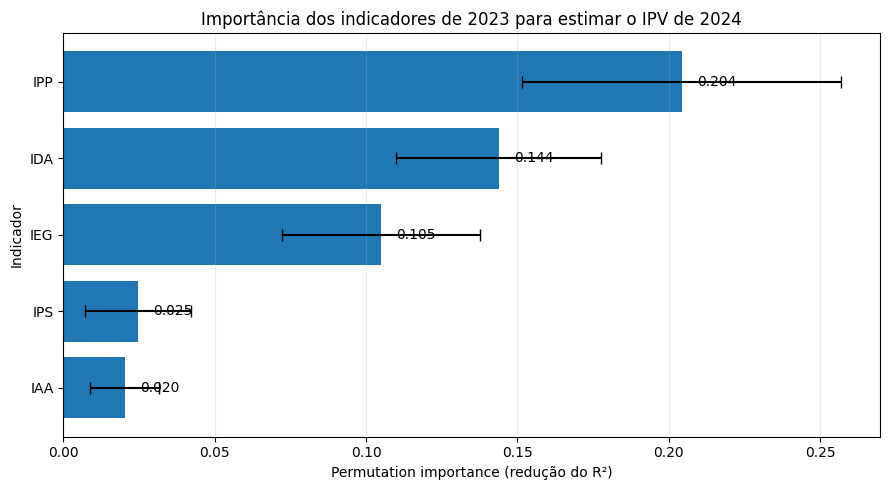

In [128]:
# ============================================================
# GRÁFICO — PERMUTATION IMPORTANCE
# PERGUNTA 7
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 5)
)

dados_grafico = (
    importancia_pv
    .sort_values(
        "Importancia_media",
        ascending=True
    )
)

ax.barh(
    dados_grafico["Indicador"],
    dados_grafico["Importancia_media"],
    xerr=dados_grafico["Importancia_desvio"],
    capsize=4
)

for i, valor in enumerate(
    dados_grafico["Importancia_media"]
):
    ax.text(
        valor + 0.005,
        i,
        f"{valor:.3f}",
        va="center"
    )

ax.set_title(
    "Importância dos indicadores de 2023 para estimar o IPV de 2024"
)

ax.set_xlabel(
    "Permutation importance (redução do R²)"
)

ax.set_ylabel(
    "Indicador"
)

ax.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    OUTPUTS_DIR /
    "pergunta_07_importancia_indicadores_ipv_futuro.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10.6 Conclusão — Pergunta 7

### Quais comportamentos ou características estão mais associados ao IPV ao longo do tempo?

A análise da Pergunta 7 utilizou quatro perspectivas complementares:

1. comparação entre alunos que atingiram ou não o Ponto de Virada em 2022;
2. correlações entre os indicadores e o IPV no mesmo ano;
3. associações longitudinais entre indicadores anteriores e IPV futuro;
4. modelo multivariado com permutation importance.

A combinação dessas evidências mostra que **desempenho acadêmico, engajamento e
aspectos psicopedagógicos são as dimensões mais relacionadas ao ponto de virada**,
embora com comportamentos diferentes ao longo do período.

### Desempenho acadêmico — IDA

O IDA apresentou uma das evidências mais consistentes de toda a análise.

Em 2022, foi a variável que mais diferenciou os alunos que atingiram ou não o
Ponto de Virada:

- **Hedges' g = 1,060**, indicando efeito de grande magnitude.

Sua associação contemporânea com o IPV permaneceu elevada:

- **2022:** ρ = 0,624
- **2023:** ρ = 0,551
- **2024:** ρ = 0,548

A relação também permaneceu quando foi exigida precedência temporal:

- **IDA 2022 → IPV 2023:** ρ = 0,417
- **IDA 2023 → IPV 2024:** ρ = 0,400

Portanto, o desempenho acadêmico aparece como um dos sinais mais estáveis
associados ao ponto de virada.

### Engajamento — IEG

O engajamento apresentou comportamento igualmente consistente.

Em 2022:

- **Hedges' g = 0,816**, também caracterizando grande diferença entre os grupos.

As associações contemporâneas foram:

- **2022:** ρ = 0,540
- **2023:** ρ = 0,492
- **2024:** ρ = 0,551

Na perspectiva longitudinal:

- **IEG 2022 → IPV 2023:** ρ = 0,412
- **IEG 2023 → IPV 2024:** ρ = 0,387

Assim como o IDA, o IEG permanece associado ao IPV mesmo quando observado antes
do resultado posterior.

### Aspectos psicopedagógicos — IPP

O IPP não está disponível como indicador observado em 2022, portanto sua evidência
temporal é mais limitada.

Entretanto, apresentou resultados relevantes:

- **IPP × IPV em 2023:** ρ = 0,512
- **IPP × IPV em 2024:** ρ = 0,705
- **IPP 2023 → IPV 2024:** ρ = 0,354

No modelo multivariado 2023 → 2024, o IPP apresentou a maior permutation importance:

- **IPP:** 0,204
- **IDA:** 0,144
- **IEG:** 0,105
- **IPS:** 0,025
- **IAA:** 0,020

Esse resultado indica que o IPP contém informação relevante para estimar o IPV
futuro quando considerado simultaneamente com os demais indicadores.

Entretanto, sua posição no ranking deve ser interpretada com cautela. A importância
é específica do modelo utilizado e apresenta incerteza, além de o IPP estar
disponível somente em 2023 e 2024.

### Autoavaliação e aspectos psicossociais

IAA e IPS apresentaram relações menores e menos consistentes.

O IAA apresentou associação longitudinal:

- **2022 → 2023:** ρ = 0,181
- **2023 → 2024:** ρ = 0,002

O IPS apresentou:

- **2022 → 2023:** ρ = 0,189
- **2023 → 2024:** ρ = 0,069

Na segunda transição, nenhuma dessas duas dimensões apresentou associação
estatisticamente relevante com o IPV futuro.

Isso não significa que aspectos psicossociais ou de autopercepção sejam
irrelevantes para o desenvolvimento dos estudantes. O resultado indica apenas
que, **isoladamente, eles apresentaram menor poder de diferenciação e menor
consistência temporal em relação ao IPV nos dados disponíveis**.

### Evidência multivariada

O modelo exploratório construído com indicadores de 2023 para estimar o IPV de
2024 apresentou:

- **MAE = 0,707**
- **R² = 0,311**

Portanto, os cinco indicadores possuem informação relevante, mas explicam apenas
parte da variabilidade futura do IPV.

Isso reforça que o ponto de virada é um fenômeno multidimensional e que outros
fatores não representados neste conjunto de variáveis também participam da
trajetória dos estudantes.

### Resposta à pergunta de negócio

Considerando conjuntamente todas as análises, **IDA e IEG são os indicadores mais
consistentes ao longo do tempo**.

O IPP também apresenta forte relevância, principalmente em 2024, e acrescenta
informação importante quando analisado conjuntamente com desempenho e engajamento.

Assim, o padrão observado sugere a seguinte hierarquia de evidência:

1. **IDA — desempenho acadêmico:** associação forte e temporalmente consistente;
2. **IEG — engajamento:** associação forte e estável;
3. **IPP — dimensão psicopedagógica:** forte contribuição recente e relevante no
   modelo multivariado;
4. **IPS — aspectos psicossociais:** associação mais fraca;
5. **IAA — autoavaliação:** associação fraca e pouco consistente temporalmente.

Essa hierarquia representa **força de associação e contribuição preditiva nos dados
observados**, e não uma relação causal.

### Recomendação gerencial

Para acompanhamento do Ponto de Virada, recomenda-se priorizar uma visão combinada
de:

- desempenho acadêmico;
- engajamento;
- avaliação psicopedagógica.

Em especial, quedas persistentes em IDA e IEG podem servir como sinais relevantes
para acompanhamento, enquanto o IPP pode complementar essa leitura com uma
dimensão psicopedagógica.

IAA e IPS não devem ser descartados, mas seus resultados sugerem maior utilidade
como informações complementares do que como sinais isolados de Ponto de Virada.

# 11. Pergunta 8 — Quais combinações de indicadores elevam mais o INDE?

O INDE é o indicador global de desenvolvimento educacional da Passos Mágicos.

Diferentemente de análises anteriores, nesta pergunta existe uma característica
metodológica importante: o INDE é construído a partir da ponderação dos próprios
indicadores educacionais.

Portanto, uma correlação elevada entre determinado indicador e o INDE não deve ser
interpretada automaticamente como uma descoberta causal, pois parte dessa relação
decorre da própria construção matemática do índice.

A documentação do PEDE apresenta duas fórmulas de composição.

### Fases 0 a 7

`INDE = 0,10×IAN + 0,20×IDA + 0,20×IEG + 0,10×IAA + 0,10×IPS + 0,10×IPP + 0,20×IPV`

Nessas fases, os maiores pesos individuais são atribuídos a:

- IDA: 20%;
- IEG: 20%;
- IPV: 20%.

Os demais indicadores possuem peso de 10%.

### Fase 8

`INDE = 0,10×IAN + 0,40×IDA + 0,20×IEG + 0,10×IAA + 0,20×IPS`

Na Fase 8 ocorre uma mudança estrutural:

- IDA passa a representar 40%;
- IEG representa 20%;
- IPS representa 20%;
- IAN e IAA representam 10% cada;
- IPP e IPV deixam de participar da fórmula documentada.

### Estratégia da Pergunta 8

A análise será dividida entre dois conceitos:

1. **contribuição estrutural**, determinada pelos pesos oficiais do INDE;
2. **combinações observadas**, investigando quais perfis conjuntos de IDA, IEG,
   IPS e IPP estão associados aos maiores valores efetivamente observados de INDE.

Como o IPP não está disponível como indicador observado em 2022, a análise
multidimensional envolvendo os quatro indicadores será concentrada em 2023 e 2024.

Além disso, a base de 2024 contém registros de Fase 9, enquanto a documentação
consultada apresenta fórmula apenas para as Fases 0 a 8. Esses registros não terão
sua fórmula presumida e serão analisados separadamente caso necessário.

Antes de decompor as contribuições, a fórmula documentada será validada diretamente
contra os valores de INDE presentes na base.

In [131]:
# ============================================================
# VALIDAÇÃO DA FÓRMULA DOCUMENTADA DO INDE
# PERGUNTA 8
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Função para localizar a coluna correta do INDE
# ------------------------------------------------------------

def localizar_coluna_inde(df, ano):

    candidatos = {
        2023: [
            "INDE 23",
            "INDE 2023",
            "INDE_2023"
        ],
        2024: [
            "INDE 2024",
            "INDE 24",
            "INDE_2024"
        ]
    }

    for coluna in candidatos[ano]:
        if coluna in df.columns:
            return coluna

    return None


# ------------------------------------------------------------
# Função de auditoria
# ------------------------------------------------------------

def validar_formula_inde(df, ano):

    temp = df.copy()

    coluna_inde = localizar_coluna_inde(
        temp,
        ano
    )

    if coluna_inde is None:
        raise ValueError(
            f"Coluna do INDE de {ano} não encontrada."
        )

    print("\n" + "=" * 75)
    print(f"VALIDAÇÃO DO INDE — {ano}")
    print("=" * 75)

    print(
        "Coluna utilizada:",
        coluna_inde
    )

    # --------------------------------------------------------
    # Conversão numérica
    # --------------------------------------------------------

    colunas_numericas = [
        coluna_inde,
        "FASE_NUM",
        "IAN",
        "IDA",
        "IEG",
        "IAA",
        "IPS",
        "IPP",
        "IPV"
    ]

    for coluna in colunas_numericas:

        if coluna in temp.columns:

            temp[coluna] = pd.to_numeric(
                temp[coluna],
                errors="coerce"
            )

    temp["INDE_ORIGINAL"] = temp[
        coluna_inde
    ]

    temp["INDE_CALCULADO"] = np.nan

    temp["FORMULA_APLICADA"] = (
        "Fora da fórmula documentada"
    )


    # ========================================================
    # FASES 0 A 7
    # ========================================================

    mask_0_7 = (
        temp["FASE_NUM"]
        .between(0, 7)
    )

    temp.loc[
        mask_0_7,
        "INDE_CALCULADO"
    ] = (

        0.10 * temp.loc[mask_0_7, "IAN"]
        + 0.20 * temp.loc[mask_0_7, "IDA"]
        + 0.20 * temp.loc[mask_0_7, "IEG"]
        + 0.10 * temp.loc[mask_0_7, "IAA"]
        + 0.10 * temp.loc[mask_0_7, "IPS"]
        + 0.10 * temp.loc[mask_0_7, "IPP"]
        + 0.20 * temp.loc[mask_0_7, "IPV"]
    )

    temp.loc[
        mask_0_7,
        "FORMULA_APLICADA"
    ] = "Fases 0-7"


    # ========================================================
    # FASE 8
    # ========================================================

    mask_8 = (
        temp["FASE_NUM"] == 8
    )

    temp.loc[
        mask_8,
        "INDE_CALCULADO"
    ] = (

        0.10 * temp.loc[mask_8, "IAN"]
        + 0.40 * temp.loc[mask_8, "IDA"]
        + 0.20 * temp.loc[mask_8, "IEG"]
        + 0.10 * temp.loc[mask_8, "IAA"]
        + 0.20 * temp.loc[mask_8, "IPS"]
    )

    temp.loc[
        mask_8,
        "FORMULA_APLICADA"
    ] = "Fase 8"


    # --------------------------------------------------------
    # Erro de reprodução
    # --------------------------------------------------------

    temp["ERRO_ABS_INDE"] = (
        temp["INDE_ORIGINAL"]
        - temp["INDE_CALCULADO"]
    ).abs()


    auditaveis = temp.dropna(
        subset=[
            "INDE_ORIGINAL",
            "INDE_CALCULADO"
        ]
    ).copy()


    print(
        "Registros totais:",
        len(temp)
    )

    print(
        "Registros auditáveis:",
        len(auditaveis)
    )

    print(
        "Fases fora da fórmula documentada:",
        int(
            (
                temp["FORMULA_APLICADA"]
                == "Fora da fórmula documentada"
            ).sum()
        )
    )

    print(
        "Erro absoluto médio:",
        round(
            auditaveis["ERRO_ABS_INDE"].mean(),
            8
        )
    )

    print(
        "Erro absoluto máximo:",
        round(
            auditaveis["ERRO_ABS_INDE"].max(),
            8
        )
    )

    print(
        "Reprodução dentro de 0,001:",
        f"""
{(
    auditaveis["ERRO_ABS_INDE"]
    <= 0.001
).mean() * 100:.2f}%
"""
    )


    # --------------------------------------------------------
    # Resumo por tipo de fórmula
    # --------------------------------------------------------

    resumo = (
        auditaveis
        .groupby(
            "FORMULA_APLICADA"
        )
        .agg(
            Alunos=("RA", "size"),
            Erro_medio=("ERRO_ABS_INDE", "mean"),
            Erro_maximo=("ERRO_ABS_INDE", "max")
        )
        .reset_index()
    )

    resumo[
        [
            "Erro_medio",
            "Erro_maximo"
        ]
    ] = resumo[
        [
            "Erro_medio",
            "Erro_maximo"
        ]
    ].round(6)

    display(resumo)


    return temp


auditoria_inde_2023 = validar_formula_inde(
    df_2023,
    2023
)

auditoria_inde_2024 = validar_formula_inde(
    df_2024,
    2024
)


VALIDAÇÃO DO INDE — 2023
Coluna utilizada: INDE 23
Registros totais: 1014
Registros auditáveis: 0
Fases fora da fórmula documentada: 0
Erro absoluto médio: nan
Erro absoluto máximo: nan
Reprodução dentro de 0,001: 
nan%



,FORMULA_APLICADA,Alunos,Erro_medio,Erro_maximo



VALIDAÇÃO DO INDE — 2024
Coluna utilizada: INDE 2024
Registros totais: 1156
Registros auditáveis: 1054
Fases fora da fórmula documentada: 38
Erro absoluto médio: 0.0
Erro absoluto máximo: 0.0
Reprodução dentro de 0,001: 
100.00%



,FORMULA_APLICADA,Alunos,Erro_medio,Erro_maximo
0,Fases 0-7,1054,0.0,0.0


In [132]:
# ============================================================
# VALIDAÇÃO ROBUSTA DA FÓRMULA DO INDE
# PERGUNTA 8
# ============================================================

import numpy as np
import pandas as pd


def validar_formula_inde(df, ano):

    temp = df.copy()

    # --------------------------------------------------------
    # Coluna correta do INDE corrente de cada ano
    # --------------------------------------------------------

    mapa_coluna_inde = {
        2023: "INDE 2023",
        2024: "INDE 2024"
    }

    coluna_inde = mapa_coluna_inde[ano]

    if coluna_inde not in temp.columns:
        raise ValueError(
            f"Coluna '{coluna_inde}' não encontrada para {ano}."
        )

    print("\n" + "=" * 75)
    print(f"VALIDAÇÃO DO INDE — {ano}")
    print("=" * 75)

    print("Coluna utilizada:", coluna_inde)

    # --------------------------------------------------------
    # Conversão numérica
    # --------------------------------------------------------

    colunas_numericas = [
        coluna_inde,
        "FASE_NUM",
        "IAN",
        "IDA",
        "IEG",
        "IAA",
        "IPS",
        "IPP",
        "IPV"
    ]

    for coluna in colunas_numericas:
        if coluna in temp.columns:
            temp[coluna] = pd.to_numeric(
                temp[coluna],
                errors="coerce"
            )

    temp["INDE_ORIGINAL"] = temp[coluna_inde]
    temp["INDE_CALCULADO"] = np.nan
    temp["FORMULA_APLICADA"] = "Fora da fórmula documentada"

    # ========================================================
    # FASES 0 A 7
    # ========================================================

    mask_0_7 = temp["FASE_NUM"].between(0, 7)

    temp.loc[
        mask_0_7,
        "INDE_CALCULADO"
    ] = (
        0.10 * temp.loc[mask_0_7, "IAN"]
        + 0.20 * temp.loc[mask_0_7, "IDA"]
        + 0.20 * temp.loc[mask_0_7, "IEG"]
        + 0.10 * temp.loc[mask_0_7, "IAA"]
        + 0.10 * temp.loc[mask_0_7, "IPS"]
        + 0.10 * temp.loc[mask_0_7, "IPP"]
        + 0.20 * temp.loc[mask_0_7, "IPV"]
    )

    temp.loc[
        mask_0_7,
        "FORMULA_APLICADA"
    ] = "Fases 0-7"

    # ========================================================
    # FASE 8
    # ========================================================

    mask_8 = temp["FASE_NUM"].eq(8)

    temp.loc[
        mask_8,
        "INDE_CALCULADO"
    ] = (
        0.10 * temp.loc[mask_8, "IAN"]
        + 0.40 * temp.loc[mask_8, "IDA"]
        + 0.20 * temp.loc[mask_8, "IEG"]
        + 0.10 * temp.loc[mask_8, "IAA"]
        + 0.20 * temp.loc[mask_8, "IPS"]
    )

    temp.loc[
        mask_8,
        "FORMULA_APLICADA"
    ] = "Fase 8"

    # --------------------------------------------------------
    # Erro absoluto
    # --------------------------------------------------------

    temp["ERRO_ABS_INDE"] = (
        temp["INDE_ORIGINAL"]
        - temp["INDE_CALCULADO"]
    ).abs()

    auditaveis = temp.dropna(
        subset=[
            "INDE_ORIGINAL",
            "INDE_CALCULADO"
        ]
    ).copy()

    # --------------------------------------------------------
    # Resumo geral
    # --------------------------------------------------------

    print("Registros totais:", len(temp))

    print(
        "INDE original válido:",
        temp["INDE_ORIGINAL"].notna().sum()
    )

    print(
        "INDE calculado válido:",
        temp["INDE_CALCULADO"].notna().sum()
    )

    print(
        "Registros auditáveis:",
        len(auditaveis)
    )

    print(
        "Fora da fórmula documentada:",
        int(
            (
                temp["FORMULA_APLICADA"]
                == "Fora da fórmula documentada"
            ).sum()
        )
    )

    if len(auditaveis) > 0:

        print(
            "Erro absoluto médio:",
            round(
                auditaveis["ERRO_ABS_INDE"].mean(),
                8
            )
        )

        print(
            "Erro absoluto máximo:",
            round(
                auditaveis["ERRO_ABS_INDE"].max(),
                8
            )
        )

        print(
            "Reprodução dentro de 0,001:",
            f"{(auditaveis['ERRO_ABS_INDE'] <= 0.001).mean() * 100:.2f}%"
        )

    # --------------------------------------------------------
    # Estrutura por fórmula
    # --------------------------------------------------------

    resumo_estrutura = (
        temp
        .groupby(
            "FORMULA_APLICADA",
            dropna=False
        )
        .agg(
            Linhas=("RA", "size"),
            INDE_original_validos=("INDE_ORIGINAL", "count"),
            INDE_calculado_validos=("INDE_CALCULADO", "count"),
            Auditaveis=("ERRO_ABS_INDE", "count")
        )
        .reset_index()
    )

    display(resumo_estrutura)

    # --------------------------------------------------------
    # Precisão apenas entre auditáveis
    # --------------------------------------------------------

    if len(auditaveis) > 0:

        resumo_erro = (
            auditaveis
            .groupby("FORMULA_APLICADA")
            .agg(
                Alunos=("RA", "size"),
                Erro_medio=("ERRO_ABS_INDE", "mean"),
                Erro_maximo=("ERRO_ABS_INDE", "max")
            )
            .reset_index()
        )

        resumo_erro[
            [
                "Erro_medio",
                "Erro_maximo"
            ]
        ] = resumo_erro[
            [
                "Erro_medio",
                "Erro_maximo"
            ]
        ].round(8)

        display(resumo_erro)

    return temp


auditoria_inde_2023 = validar_formula_inde(
    df_2023,
    2023
)

auditoria_inde_2024 = validar_formula_inde(
    df_2024,
    2024
)


VALIDAÇÃO DO INDE — 2023
Coluna utilizada: INDE 2023
Registros totais: 1014
INDE original válido: 931
INDE calculado válido: 931
Registros auditáveis: 931
Fora da fórmula documentada: 0
Erro absoluto médio: 0.00511117
Erro absoluto máximo: 0.0149
Reprodução dentro de 0,001: 31.69%


,FORMULA_APLICADA,Linhas,INDE_original_validos,INDE_calculado_validos,Auditaveis
0,Fase 8,63,0,0,0
1,Fases 0-7,951,931,931,931


,FORMULA_APLICADA,Alunos,Erro_medio,Erro_maximo
0,Fases 0-7,931,0.005111,0.0149



VALIDAÇÃO DO INDE — 2024
Coluna utilizada: INDE 2024
Registros totais: 1156
INDE original válido: 1054
INDE calculado válido: 1054
Registros auditáveis: 1054
Fora da fórmula documentada: 38
Erro absoluto médio: 0.0
Erro absoluto máximo: 0.0
Reprodução dentro de 0,001: 100.00%


,FORMULA_APLICADA,Linhas,INDE_original_validos,INDE_calculado_validos,Auditaveis
0,Fase 8,64,0,0,0
1,Fases 0-7,1054,1054,1054,1054
2,Fora da fórmula documentada,38,0,0,0


,FORMULA_APLICADA,Alunos,Erro_medio,Erro_maximo
0,Fases 0-7,1054,0.0,0.0


## 11.2 Validação da fórmula do INDE nos dados

A recomposição do INDE foi testada diretamente contra os valores armazenados na
base antes de qualquer análise de contribuição.

### Resultado de 2024

Para as Fases 0 a 7 foram encontrados:

- **1.054 registros auditáveis**;
- erro absoluto médio = **0,0000**;
- erro absoluto máximo = **0,0000**;
- **100% de reprodução exata** dentro da tolerância de 0,001.

Portanto, a fórmula documentada das Fases 0 a 7 está integralmente confirmada nos
dados de 2024.

### Resultado de 2023

Para as Fases 0 a 7 foram encontrados:

- **931 registros auditáveis**;
- erro absoluto médio = **0,0051**;
- erro absoluto máximo = **0,0149**.

As diferenças são pequenas, porém a reprodução não é numericamente idêntica à de
2024.

Esse comportamento pode estar relacionado à precisão com que os indicadores de
2023 foram disponibilizados na planilha, uma vez que vários componentes aparecem
com menor número de casas decimais do que em 2024.

Antes de concluir que existe qualquer alteração nos pesos, será realizada uma
checagem adicional para verificar se os coeficientes implícitos nos dados de 2023
continuam próximos aos pesos documentados.

### Fase 8

Embora a documentação apresente uma fórmula específica para a Fase 8, não existem
registros com INDE corrente válido suficientes para validá-la empiricamente nesta
base:

- **2023:** 63 registros de Fase 8, nenhum com INDE corrente auditável;
- **2024:** 64 registros de Fase 8, nenhum com INDE corrente auditável.

Portanto, a fórmula da Fase 8 será reconhecida como regra documentada, mas não
será tratada como empiricamente validada neste conjunto de dados.

### Fase 9

Em 2024 existem **38 registros de Fase 9**.

Como a documentação consultada apresenta composição do INDE apenas para as Fases
0 a 8, nenhuma fórmula será presumida para esses registros.

Consequentemente, a análise principal da Pergunta 8 será restrita aos registros
para os quais a composição do INDE pode ser sustentada documental e
empiricamente.

In [133]:
# ============================================================
# CHECAGEM DOS PESOS IMPLÍCITOS DO INDE
# NÃO É MODELO PREDITIVO — É UMA AUDITORIA DA FÓRMULA
# ============================================================

from sklearn.linear_model import LinearRegression

pesos_documentados = {
    "IAN": 0.10,
    "IDA": 0.20,
    "IEG": 0.20,
    "IAA": 0.10,
    "IPS": 0.10,
    "IPP": 0.10,
    "IPV": 0.20
}

resultados_pesos = []

for ano, df, coluna_inde in [
    (2023, df_2023, "INDE 2023"),
    (2024, df_2024, "INDE 2024")
]:

    temp = df.copy()

    colunas = [
        "IAN",
        "IDA",
        "IEG",
        "IAA",
        "IPS",
        "IPP",
        "IPV",
        coluna_inde
    ]

    for coluna in colunas:
        temp[coluna] = pd.to_numeric(
            temp[coluna],
            errors="coerce"
        )

    # Apenas Fases 0 a 7,
    # cuja fórmula conseguimos auditar na base.
    base = temp.loc[
        temp["FASE_NUM"].between(0, 7),
        colunas
    ].dropna().copy()

    X = base[
        [
            "IAN",
            "IDA",
            "IEG",
            "IAA",
            "IPS",
            "IPP",
            "IPV"
        ]
    ]

    y = base[coluna_inde]

    modelo_auditoria = LinearRegression(
        fit_intercept=True
    )

    modelo_auditoria.fit(
        X,
        y
    )

    for indicador, coeficiente in zip(
        X.columns,
        modelo_auditoria.coef_
    ):

        resultados_pesos.append({
            "Ano": ano,
            "Indicador": indicador,
            "Peso_documentado": pesos_documentados[indicador],
            "Peso_recuperado": coeficiente,
            "Diferenca": (
                coeficiente
                - pesos_documentados[indicador]
            )
        })

    print("\n" + "=" * 70)
    print(f"AUDITORIA DOS PESOS — {ano}")
    print("=" * 70)

    print(
        "Registros utilizados:",
        len(base)
    )

    print(
        "Intercepto:",
        round(
            modelo_auditoria.intercept_,
            6
        )
    )

    print(
        "R² da recomposição:",
        round(
            modelo_auditoria.score(X, y),
            8
        )
    )


auditoria_pesos_inde = pd.DataFrame(
    resultados_pesos
)

auditoria_pesos_inde[
    [
        "Peso_documentado",
        "Peso_recuperado",
        "Diferenca"
    ]
] = auditoria_pesos_inde[
    [
        "Peso_documentado",
        "Peso_recuperado",
        "Diferenca"
    ]
].round(6)

display(auditoria_pesos_inde)


AUDITORIA DOS PESOS — 2023
Registros utilizados: 931
Intercepto: -0.002412
R² da recomposição: 0.99996274

AUDITORIA DOS PESOS — 2024
Registros utilizados: 1054
Intercepto: 0.0
R² da recomposição: 1.0


,Ano,Indicador,Peso_documentado,Peso_recuperado,Diferenca
0,2023,IAN,0.1,0.100119,0.000119
1,2023,IDA,0.2,0.199505,-0.000495
2,2023,IEG,0.2,0.200304,0.000304
3,2023,IAA,0.1,0.100011,0.000011
4,2023,IPS,0.1,0.099795,-0.000205
5,2023,IPP,0.1,0.100036,0.000036
6,2023,IPV,0.2,0.199917,-0.000083
7,2024,IAN,0.1,0.100000,-0.000000
8,2024,IDA,0.2,0.200000,-0.000000
9,2024,IEG,0.2,0.200000,-0.000000


### 11.2.1 Checagem dos pesos implícitos

Para investigar as pequenas diferenças encontradas na recomposição do INDE de
2023, foi realizada uma auditoria adicional dos pesos implícitos nos próprios
dados.

A regressão foi utilizada exclusivamente como ferramenta de recomposição
matemática, e não como modelo preditivo.

### 2023

Foram utilizados **931 registros** das Fases 0 a 7.

O resultado apresentou:

- intercepto = **-0,002412**;
- R² da recomposição = **0,99996274**.

Os pesos recuperados foram:

| Indicador | Peso documentado | Peso recuperado |
|---|---:|---:|
| IAN | 0,10 | 0,100119 |
| IDA | 0,20 | 0,199505 |
| IEG | 0,20 | 0,200304 |
| IAA | 0,10 | 0,100011 |
| IPS | 0,10 | 0,099795 |
| IPP | 0,10 | 0,100036 |
| IPV | 0,20 | 0,199917 |

As diferenças são inferiores a 0,0005 em valor absoluto.

Esse resultado fornece forte evidência de que a estrutura de ponderação utilizada
em 2023 é a mesma fórmula documentada.

As pequenas diferenças encontradas anteriormente na recomposição do INDE são
compatíveis com diferenças de precisão ou arredondamento dos indicadores
disponibilizados na base.

### 2024

Para os **1.054 registros auditáveis**, a recuperação foi exata:

- intercepto = **0**;
- R² = **1,0**;
- todos os coeficientes recuperados coincidem com os pesos documentados.

### Decisão metodológica

A fórmula das Fases 0 a 7 será considerada confirmada para a análise de 2023 e
2024.

A Fase 8 permanecerá fora da análise empírica de contribuição porque não possui
INDE corrente válido nos dados disponíveis, apesar de possuir fórmula documentada.

A Fase 9 também permanecerá fora da decomposição, pois não foi identificada uma
fórmula documentada correspondente.

Assim, as próximas análises da Pergunta 8 utilizarão apenas estudantes das
**Fases 0 a 7 com INDE válido**.

## 11.3 Contribuição estrutural de IDA, IEG, IPS e IPP

Com a fórmula do INDE validada, é possível decompor diretamente a contribuição
dos indicadores analisados.

Nas Fases 0 a 7, os pesos são:

- **IDA:** 20%;
- **IEG:** 20%;
- **IPS:** 10%;
- **IPP:** 10%.

Portanto, IDA e IEG possuem estruturalmente o dobro do peso de IPS e IPP.

Entretanto, peso não é sinônimo de contribuição observada.

A contribuição efetiva de cada dimensão depende simultaneamente:

1. do peso definido na fórmula;
2. da nota obtida pelo estudante naquele indicador.

Por isso, serão calculados os pontos médios efetivamente adicionados ao INDE por
cada uma dessas quatro dimensões em 2023 e 2024.

In [134]:
# ============================================================
# CONTRIBUIÇÃO ESTRUTURAL E OBSERVADA PARA O INDE
# PERGUNTA 8 — FASES 0 A 7
# ============================================================

pesos_q8 = {
    "IDA": 0.20,
    "IEG": 0.20,
    "IPS": 0.10,
    "IPP": 0.10
}

resultados_contribuicao = []


for ano, df, coluna_inde in [
    (2023, df_2023, "INDE 2023"),
    (2024, df_2024, "INDE 2024")
]:

    temp = df.copy()

    # --------------------------------------------------------
    # Conversão numérica
    # --------------------------------------------------------

    for coluna in [
        "FASE_NUM",
        coluna_inde,
        "IDA",
        "IEG",
        "IPS",
        "IPP"
    ]:
        temp[coluna] = pd.to_numeric(
            temp[coluna],
            errors="coerce"
        )

    # --------------------------------------------------------
    # Apenas Fases 0 a 7 e casos completos
    # --------------------------------------------------------

    base = temp.loc[
        temp["FASE_NUM"].between(0, 7),
        [
            "RA",
            coluna_inde,
            "IDA",
            "IEG",
            "IPS",
            "IPP"
        ]
    ].dropna().copy()

    inde_medio = base[coluna_inde].mean()

    # --------------------------------------------------------
    # Contribuição de cada indicador
    # --------------------------------------------------------

    for indicador, peso in pesos_q8.items():

        contribuicao = (
            base[indicador]
            * peso
        )

        resultados_contribuicao.append({
            "Ano": ano,
            "Indicador": indicador,
            "Peso_INDE": peso,
            "N": len(base),

            "Nota_media": base[indicador].mean(),
            "Nota_mediana": base[indicador].median(),

            "Contribuicao_media": contribuicao.mean(),
            "Contribuicao_mediana": contribuicao.median(),

            "INDE_medio": inde_medio,

            "Participacao_no_INDE_medio_pct":
                (
                    contribuicao.mean()
                    / inde_medio
                    * 100
                )
        })


contribuicoes_inde = pd.DataFrame(
    resultados_contribuicao
)


colunas_round = [
    "Peso_INDE",
    "Nota_media",
    "Nota_mediana",
    "Contribuicao_media",
    "Contribuicao_mediana",
    "INDE_medio",
    "Participacao_no_INDE_medio_pct"
]

contribuicoes_inde[
    colunas_round
] = contribuicoes_inde[
    colunas_round
].round(3)


display(contribuicoes_inde)

,Ano,Indicador,Peso_INDE,N,Nota_media,Nota_mediana,Contribuicao_media,Contribuicao_mediana,INDE_medio,Participacao_no_INDE_medio_pct
0,2023,IDA,0.2,931,6.669,6.800,1.334,1.360,7.342,18.167
1,2023,IEG,0.2,931,8.702,9.000,1.740,1.800,7.342,23.705
2,2023,IPS,0.1,931,5.135,5.000,0.513,0.500,7.342,6.993
3,2023,IPP,0.1,931,7.565,7.656,0.756,0.766,7.342,10.303
4,2024,IDA,0.2,1054,6.350,6.750,1.270,1.350,7.397,17.169
5,2024,IEG,0.2,1054,8.089,8.592,1.618,1.718,7.397,21.871
6,2024,IPS,0.1,1054,6.830,7.510,0.683,0.751,7.397,9.233
7,2024,IPP,0.1,1054,7.548,7.500,0.755,0.750,7.397,10.205


### 11.3.1 Interpretação das contribuições observadas

A decomposição do INDE mostra que o peso definido na fórmula e a nota observada
atuam conjuntamente sobre a contribuição final de cada indicador.

### 2023

O INDE médio da amostra analisada foi **7,342**.

As contribuições médias foram:

- **IEG:** 1,740 ponto do INDE;
- **IDA:** 1,334 ponto;
- **IPP:** 0,756 ponto;
- **IPS:** 0,513 ponto.

Embora IDA e IEG possuam o mesmo peso estrutural de 20%, o IEG contribuiu mais
para o INDE médio porque apresentou nota média superior:

- IDA médio = **6,669**;
- IEG médio = **8,702**.

O mesmo ocorre entre IPS e IPP, que possuem peso de 10% cada:

- IPS médio = **5,135**;
- IPP médio = **7,565**.

Consequentemente, o IPP adicionou mais pontos ao INDE médio do que o IPS.

Os quatro indicadores analisados representaram conjuntamente aproximadamente
**59,2% do INDE médio de 2023**.

### 2024

O INDE médio foi **7,397**.

As contribuições médias foram:

- **IEG:** 1,618 ponto;
- **IDA:** 1,270 ponto;
- **IPP:** 0,755 ponto;
- **IPS:** 0,683 ponto.

Novamente, o IEG apresentou maior contribuição que o IDA apesar de ambos possuírem
peso de 20%.

Entre os indicadores com peso de 10%, IPP e IPS apresentaram contribuições mais
próximas do que em 2023, principalmente devido à elevação do IPS médio em 2024.

Os quatro indicadores representaram conjuntamente aproximadamente **58,5% do INDE
médio de 2024**.

### Evolução entre os anos

Entre 2023 e 2024:

- a contribuição média do **IDA** caiu de 1,334 para 1,270;
- a contribuição do **IEG** caiu de 1,740 para 1,618;
- a contribuição do **IPP** permaneceu praticamente estável;
- a contribuição do **IPS** aumentou de 0,513 para 0,683.

Mesmo assim, o INDE médio aumentou de **7,342 para 7,397**.

Isso mostra que a evolução do INDE não depende apenas das quatro dimensões
investigadas nesta pergunta. IAN, IAA e IPV também participam da composição e
podem compensar movimentos observados nos demais indicadores.

### Insight estrutural

Considerando exclusivamente IDA, IEG, IPS e IPP:

- **IDA e IEG possuem maior capacidade estrutural de alterar o INDE**, pois possuem
  peso de 20%;
- **IEG apresentou a maior contribuição observada nos dois anos**, devido às notas
  médias mais elevadas;
- **IPP contribuiu mais que IPS**, apesar de ambos possuírem o mesmo peso de 10%,
  especialmente em 2023.

Entretanto, esta análise ainda considera cada dimensão separadamente.

A próxima etapa investigará quais **combinações simultâneas** de níveis elevados
de IDA, IEG, IPS e IPP aparecem associadas aos maiores valores de INDE.

## 11.4 Combinações de indicadores associadas aos maiores INDEs

A contribuição individual mostra o papel matemático de cada indicador, mas a
Pergunta 8 busca principalmente compreender a multidimensionalidade.

Por isso, a próxima análise investiga quais combinações simultâneas de IDA, IEG,
IPS e IPP aparecem associadas aos maiores valores de INDE.

Como as distribuições dos indicadores diferem entre si e entre os anos, não será
adotado um ponto de corte absoluto arbitrário.

Para cada ano, um indicador será classificado como **alto** quando o estudante
estiver no quartil superior da distribuição daquele indicador.

Assim, serão criados perfis combinando:

- IDA alto;
- IEG alto;
- IPS alto;
- IPP alto.

Também será identificado o quartil superior do INDE de cada ano.

Para cada combinação serão observados:

- número de alunos;
- INDE médio e mediano;
- percentual de alunos pertencentes ao quartil superior do INDE.

A análise é descritiva e não causal. Como os próprios indicadores participam da
fórmula do INDE, o objetivo é identificar perfis multidimensionais recorrentes,
e não provar que determinada combinação causa um INDE elevado.

In [135]:
# ============================================================
# COMBINAÇÕES DE IDA + IEG + IPS + IPP
# PERGUNTA 8 — FASES 0 A 7
# ============================================================

resultados_combinacoes = []
limites_quartis = []


for ano, df, coluna_inde in [
    (2023, df_2023, "INDE 2023"),
    (2024, df_2024, "INDE 2024")
]:

    temp = df.copy()

    # --------------------------------------------------------
    # Conversão numérica
    # --------------------------------------------------------

    for coluna in [
        "FASE_NUM",
        coluna_inde,
        "IDA",
        "IEG",
        "IPS",
        "IPP"
    ]:

        temp[coluna] = pd.to_numeric(
            temp[coluna],
            errors="coerce"
        )

    # --------------------------------------------------------
    # Mesma população metodológica do 11.3
    # --------------------------------------------------------

    base = temp.loc[
        temp["FASE_NUM"].between(0, 7),
        [
            "RA",
            coluna_inde,
            "IDA",
            "IEG",
            "IPS",
            "IPP"
        ]
    ].dropna().copy()

    # --------------------------------------------------------
    # Q3 de cada indicador
    # --------------------------------------------------------

    q3_ida = base["IDA"].quantile(0.75)
    q3_ieg = base["IEG"].quantile(0.75)
    q3_ips = base["IPS"].quantile(0.75)
    q3_ipp = base["IPP"].quantile(0.75)

    q3_inde = base[coluna_inde].quantile(0.75)

    limites_quartis.append({
        "Ano": ano,
        "Q3_IDA": q3_ida,
        "Q3_IEG": q3_ieg,
        "Q3_IPS": q3_ips,
        "Q3_IPP": q3_ipp,
        "Q3_INDE": q3_inde
    })

    # --------------------------------------------------------
    # Flags de nível alto
    # --------------------------------------------------------

    base["IDA_ALTO"] = (
        base["IDA"] >= q3_ida
    )

    base["IEG_ALTO"] = (
        base["IEG"] >= q3_ieg
    )

    base["IPS_ALTO"] = (
        base["IPS"] >= q3_ips
    )

    base["IPP_ALTO"] = (
        base["IPP"] >= q3_ipp
    )

    base["INDE_ALTO"] = (
        base[coluna_inde] >= q3_inde
    )

    # --------------------------------------------------------
    # Quantidade de dimensões altas
    # --------------------------------------------------------

    flags = [
        "IDA_ALTO",
        "IEG_ALTO",
        "IPS_ALTO",
        "IPP_ALTO"
    ]

    base["N_INDICADORES_ALTOS"] = (
        base[flags]
        .sum(axis=1)
    )

    # --------------------------------------------------------
    # Nome da combinação
    # --------------------------------------------------------

    def nome_combinacao(row):

        altos = []

        if row["IDA_ALTO"]:
            altos.append("IDA")

        if row["IEG_ALTO"]:
            altos.append("IEG")

        if row["IPS_ALTO"]:
            altos.append("IPS")

        if row["IPP_ALTO"]:
            altos.append("IPP")

        if len(altos) == 0:
            return "Nenhum alto"

        return " + ".join(altos)


    base["COMBINACAO"] = base.apply(
        nome_combinacao,
        axis=1
    )

    # --------------------------------------------------------
    # Resumo das combinações
    # --------------------------------------------------------

    resumo = (
        base
        .groupby("COMBINACAO")
        .agg(
            Alunos=("RA", "size"),
            N_Indicadores_Altos=(
                "N_INDICADORES_ALTOS",
                "first"
            ),
            INDE_Medio=(
                coluna_inde,
                "mean"
            ),
            INDE_Mediano=(
                coluna_inde,
                "median"
            ),
            Alunos_INDE_Alto=(
                "INDE_ALTO",
                "sum"
            ),
            Pct_INDE_Alto=(
                "INDE_ALTO",
                "mean"
            )
        )
        .reset_index()
    )

    resumo["Pct_INDE_Alto"] *= 100
    resumo["Ano"] = ano

    resultados_combinacoes.append(
        resumo
    )


# ============================================================
# TABELAS FINAIS
# ============================================================

limites_q8 = pd.DataFrame(
    limites_quartis
)

combinacoes_inde = pd.concat(
    resultados_combinacoes,
    ignore_index=True
)


for coluna in [
    "Q3_IDA",
    "Q3_IEG",
    "Q3_IPS",
    "Q3_IPP",
    "Q3_INDE"
]:
    limites_q8[coluna] = (
        limites_q8[coluna]
        .round(3)
    )


for coluna in [
    "INDE_Medio",
    "INDE_Mediano",
    "Pct_INDE_Alto"
]:
    combinacoes_inde[coluna] = (
        combinacoes_inde[coluna]
        .round(2)
    )


print("=" * 70)
print("LIMITES UTILIZADOS")
print("=" * 70)

display(limites_q8)


print("\n" + "=" * 70)
print("COMBINAÇÕES — TODAS")
print("=" * 70)

display(
    combinacoes_inde.sort_values(
        ["Ano", "INDE_Medio"],
        ascending=[True, False]
    )
)


# ------------------------------------------------------------
# Combinações com amostra mínima
# ------------------------------------------------------------

combinacoes_relevantes = (
    combinacoes_inde.loc[
        combinacoes_inde["Alunos"] >= 20
    ]
    .sort_values(
        ["Ano", "INDE_Medio"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 70)
print("COMBINAÇÕES COM PELO MENOS 20 ALUNOS")
print("=" * 70)

display(
    combinacoes_relevantes
)

LIMITES UTILIZADOS


,Ano,Q3_IDA,Q3_IEG,Q3_IPS,Q3_IPP,Q3_INDE
0,2023,7.9,9.5,7.52,8.188,7.996
1,2024,8.0,9.5,7.51,8.125,8.140



COMBINAÇÕES — TODAS


,COMBINACAO,Alunos,N_Indicadores_Altos,INDE_Medio,INDE_Mediano,Alunos_INDE_Alto,Pct_INDE_Alto,Ano
4,IDA + IEG + IPS + IPP,21,4,8.66,8.49,20,95.24,2023
3,IDA + IEG + IPS,28,3,8.59,8.68,25,89.29,2023
11,IEG + IPS + IPP,9,3,8.43,8.43,9,100.00,2023
6,IDA + IPS,38,2,8.27,8.23,31,81.58,2023
1,IDA + IEG,27,2,8.19,8.35,20,74.07,2023
2,IDA + IEG + IPP,37,3,8.14,8.22,24,64.86,2023
7,IDA + IPS + IPP,16,3,8.11,8.13,9,56.25,2023
10,IEG + IPS,41,2,7.88,7.77,15,36.59,2023
14,IPS + IPP,22,2,7.86,7.80,10,45.45,2023
5,IDA + IPP,31,2,7.84,7.86,12,38.71,2023



COMBINAÇÕES COM PELO MENOS 20 ALUNOS


,COMBINACAO,Alunos,N_Indicadores_Altos,INDE_Medio,INDE_Mediano,Alunos_INDE_Alto,Pct_INDE_Alto,Ano
0,IDA + IEG + IPS + IPP,21,4,8.66,8.49,20,95.24,2023
1,IDA + IEG + IPS,28,3,8.59,8.68,25,89.29,2023
2,IDA + IPS,38,2,8.27,8.23,31,81.58,2023
3,IDA + IEG,27,2,8.19,8.35,20,74.07,2023
4,IDA + IEG + IPP,37,3,8.14,8.22,24,64.86,2023
5,IEG + IPS,41,2,7.88,7.77,15,36.59,2023
6,IPS + IPP,22,2,7.86,7.80,10,45.45,2023
7,IDA + IPP,31,2,7.84,7.86,12,38.71,2023
8,IEG + IPP,42,2,7.69,7.78,11,26.19,2023
9,IDA,43,1,7.59,7.71,10,23.26,2023


### 11.4.1 Interpretação das combinações observadas

A análise das combinações mostra um padrão consistente de multidimensionalidade.

Os estudantes com várias dimensões simultaneamente no quartil superior apresentam,
em geral, INDE mais elevado e maior probabilidade de também pertencer ao quartil
superior do indicador global.

### Todas as quatro dimensões altas

O perfil mais consistente foi:

**IDA + IEG + IPS + IPP altos**

Em 2023:

- 21 alunos;
- INDE médio = **8,66**;
- INDE mediano = **8,49**;
- **95,24%** pertenciam ao quartil superior do INDE.

Em 2024:

- 46 alunos;
- INDE médio = **8,79**;
- INDE mediano = **8,85**;
- **95,65%** pertenciam ao quartil superior do INDE.

Portanto, o desenvolvimento simultaneamente elevado nas quatro dimensões aparece
fortemente associado aos maiores resultados globais nos dois anos.

### Combinações com três dimensões altas

Perfis com três indicadores altos também apresentaram forte concentração entre os
maiores INDEs.

Em 2023, entre as combinações com pelo menos 20 alunos:

- **IDA + IEG + IPS:** 89,29% com INDE alto;
- **IDA + IEG + IPP:** 64,86%.

Em 2024:

- **IDA + IEG + IPP:** 93,55%;
- **IDA + IEG + IPS:** 77,27%;
- **IDA + IPS + IPP:** 73,08%;
- **IEG + IPS + IPP:** 66,67%.

O padrão reforça que a presença simultânea de várias dimensões altas está
associada a resultados globais superiores.

### Combinações com duas dimensões altas

Os perfis com apenas dois indicadores elevados apresentaram comportamento mais
heterogêneo.

Por exemplo:

- **IDA + IEG:** 74,07% de INDE alto em 2023 e 51,72% em 2024;
- **IEG + IPS:** 36,59% em 2023 e 31,82% em 2024;
- **IPS + IPP:** 45,45% em 2023 e 17,57% em 2024.

Isso mostra que possuir duas dimensões altas não produz necessariamente o mesmo
perfil global. A identidade dos indicadores envolvidos também importa.

Algumas combinações apresentaram forte variação entre os anos, como `IDA + IPS`,
o que recomenda cautela antes de interpretar uma combinação específica como um
padrão universal.

### Apenas uma dimensão alta

Quando somente um indicador estava no quartil superior, a concentração entre os
maiores INDEs foi substancialmente menor.

Entre os perfis individuais, o IDA apresentou a maior concentração no quartil
superior do INDE:

- **2023:** 23,26%;
- **2024:** 34,09%.

O IEG apareceu em seguida:

- **2023:** 15,49%;
- **2024:** 19,51%.

IPP e principalmente IPS isolados apresentaram percentuais menores.

### Nenhuma dimensão alta

O contraste mais forte aparece entre os alunos sem nenhum dos quatro indicadores
no quartil superior:

- **2023:** apenas 1,85% apresentaram INDE alto;
- **2024:** apenas 1,38%.

Esse resultado reforça que valores globais elevados estão associados a um perfil
multidimensional, e não apenas ao desempenho excepcional em uma única dimensão.

### Cuidado metodológico

Os quatro indicadores analisados participam diretamente da fórmula do INDE.

Portanto, parte da associação entre combinações elevadas e INDE alto é consequência
da própria construção matemática do índice.

A relevância desta análise não está em demonstrar causalidade, mas em mostrar quais
**perfis multidimensionais efetivamente aparecem entre os melhores resultados
globais da base**.

Também é importante considerar que o uso de `>= Q3` pode gerar grupos superiores
a exatamente 25% quando existem valores empatados no ponto de corte.

## 11.5 Perfis multidimensionais de alto desenvolvimento

As combinações individuais sugerem que o resultado global melhora conforme mais
dimensões do estudante apresentam desempenho elevado.

Para testar esse padrão de forma mais agregada e menos sensível a combinações
específicas, os alunos serão agrupados pela quantidade de indicadores situados no
quartil superior:

- 0 indicadores altos;
- 1 indicador alto;
- 2 indicadores altos;
- 3 indicadores altos;
- 4 indicadores altos.

Para cada grupo serão analisados:

- quantidade de estudantes;
- INDE médio;
- INDE mediano;
- percentual de estudantes no quartil superior do INDE.

Essa análise permite verificar se existe um gradiente multidimensional consistente
entre número de dimensões elevadas e resultado global.

In [136]:
# ============================================================
# NÚMERO DE DIMENSÕES ALTAS × INDE
# PERGUNTA 8
# ============================================================

resultados_multidimensional = []


for ano, df, coluna_inde in [
    (2023, df_2023, "INDE 2023"),
    (2024, df_2024, "INDE 2024")
]:

    temp = df.copy()

    for coluna in [
        "FASE_NUM",
        coluna_inde,
        "IDA",
        "IEG",
        "IPS",
        "IPP"
    ]:

        temp[coluna] = pd.to_numeric(
            temp[coluna],
            errors="coerce"
        )

    # --------------------------------------------------------
    # Mesma população usada nas etapas anteriores
    # --------------------------------------------------------

    base = temp.loc[
        temp["FASE_NUM"].between(0, 7),
        [
            "RA",
            coluna_inde,
            "IDA",
            "IEG",
            "IPS",
            "IPP"
        ]
    ].dropna().copy()

    # --------------------------------------------------------
    # Quartis
    # --------------------------------------------------------

    limites = {
        indicador: base[indicador].quantile(0.75)
        for indicador in [
            "IDA",
            "IEG",
            "IPS",
            "IPP"
        ]
    }

    q3_inde = base[
        coluna_inde
    ].quantile(0.75)

    # --------------------------------------------------------
    # Número de indicadores altos
    # --------------------------------------------------------

    for indicador in [
        "IDA",
        "IEG",
        "IPS",
        "IPP"
    ]:

        base[f"{indicador}_ALTO"] = (
            base[indicador]
            >= limites[indicador]
        )

    base["N_INDICADORES_ALTOS"] = (
        base[
            [
                "IDA_ALTO",
                "IEG_ALTO",
                "IPS_ALTO",
                "IPP_ALTO"
            ]
        ]
        .sum(axis=1)
    )

    base["INDE_ALTO"] = (
        base[coluna_inde]
        >= q3_inde
    )

    # --------------------------------------------------------
    # Resumo
    # --------------------------------------------------------

    resumo = (
        base
        .groupby(
            "N_INDICADORES_ALTOS"
        )
        .agg(
            Alunos=("RA", "size"),
            INDE_Medio=(
                coluna_inde,
                "mean"
            ),
            INDE_Mediano=(
                coluna_inde,
                "median"
            ),
            Pct_INDE_Alto=(
                "INDE_ALTO",
                "mean"
            )
        )
        .reset_index()
    )

    resumo[
        "Pct_INDE_Alto"
    ] *= 100

    resumo["Ano"] = ano

    resultados_multidimensional.append(
        resumo
    )


perfil_multidimensional = pd.concat(
    resultados_multidimensional,
    ignore_index=True
)


perfil_multidimensional[
    [
        "INDE_Medio",
        "INDE_Mediano",
        "Pct_INDE_Alto"
    ]
] = perfil_multidimensional[
    [
        "INDE_Medio",
        "INDE_Mediano",
        "Pct_INDE_Alto"
    ]
].round(2)


display(
    perfil_multidimensional
)

,N_INDICADORES_ALTOS,Alunos,INDE_Medio,INDE_Mediano,Pct_INDE_Alto,Ano
0,0,325,6.68,6.76,1.85,2023
1,1,294,7.27,7.38,13.95,2023
2,2,201,7.95,7.99,49.25,2023
3,3,90,8.30,8.38,74.44,2023
4,4,21,8.66,8.49,95.24,2023
5,0,218,6.41,6.59,1.38,2024
6,1,415,7.14,7.22,8.92,2024
7,2,231,7.86,7.88,30.30,2024
8,3,144,8.44,8.48,76.39,2024
9,4,46,8.79,8.85,95.65,2024


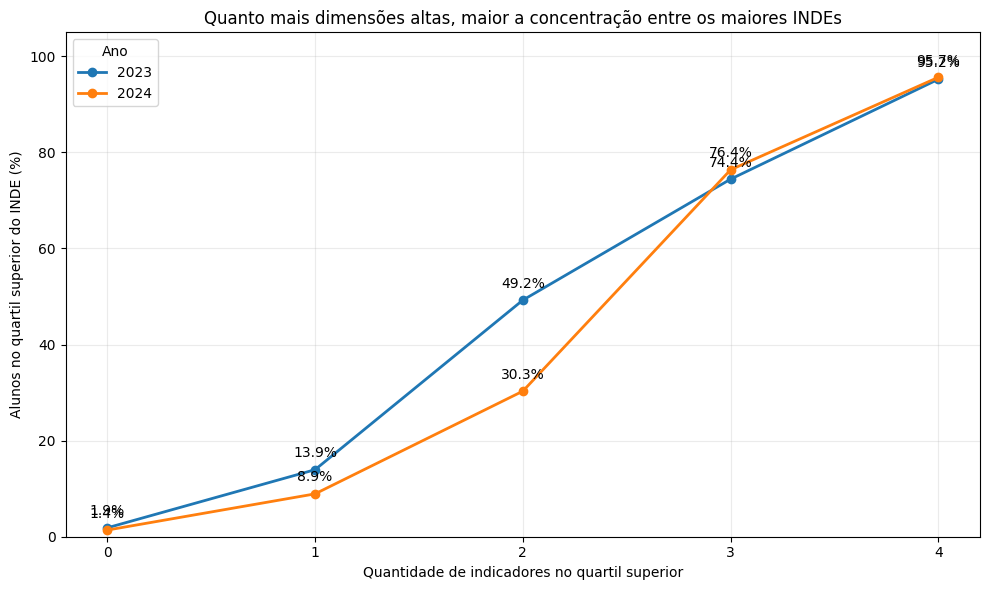

In [137]:
# ============================================================
# GRÁFICO — MULTIDIMENSIONALIDADE × INDE
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

for ano in [2023, 2024]:

    dados = perfil_multidimensional.loc[
        perfil_multidimensional["Ano"] == ano
    ]

    ax.plot(
        dados["N_INDICADORES_ALTOS"],
        dados["Pct_INDE_Alto"],
        marker="o",
        linewidth=2,
        label=str(ano)
    )

    for _, linha in dados.iterrows():

        ax.annotate(
            f"{linha['Pct_INDE_Alto']:.1f}%",
            (
                linha["N_INDICADORES_ALTOS"],
                linha["Pct_INDE_Alto"]
            ),
            textcoords="offset points",
            xytext=(0, 9),
            ha="center"
        )


ax.set_title(
    "Quanto mais dimensões altas, maior a concentração entre os maiores INDEs"
)

ax.set_xlabel(
    "Quantidade de indicadores no quartil superior"
)

ax.set_ylabel(
    "Alunos no quartil superior do INDE (%)"
)

ax.set_xticks(
    [0, 1, 2, 3, 4]
)

ax.set_ylim(
    0,
    105
)

ax.legend(
    title="Ano"
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    OUTPUTS_DIR /
    "pergunta_08_multidimensionalidade_inde.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 11.5.1 Interpretação do gradiente multidimensional

A agregação pelo número de dimensões elevadas revela um gradiente consistente
entre multidimensionalidade e resultado global.

### 2023

Conforme aumenta o número de indicadores no quartil superior, o INDE médio evolui
de forma monotônica:

- **0 indicadores altos:** INDE médio = 6,68
- **1 indicador alto:** INDE médio = 7,27
- **2 indicadores altos:** INDE médio = 7,95
- **3 indicadores altos:** INDE médio = 8,30
- **4 indicadores altos:** INDE médio = 8,66

A concentração no quartil superior do INDE também cresce progressivamente:

- **0 dimensões altas:** 1,85%
- **1 dimensão alta:** 13,95%
- **2 dimensões altas:** 49,25%
- **3 dimensões altas:** 74,44%
- **4 dimensões altas:** 95,24%

### 2024

O mesmo padrão aparece novamente:

- **0 indicadores altos:** INDE médio = 6,41
- **1 indicador alto:** INDE médio = 7,14
- **2 indicadores altos:** INDE médio = 7,86
- **3 indicadores altos:** INDE médio = 8,44
- **4 indicadores altos:** INDE médio = 8,79

A proporção de estudantes no quartil superior do INDE foi:

- **0 dimensões altas:** 1,38%
- **1 dimensão alta:** 8,92%
- **2 dimensões altas:** 30,30%
- **3 dimensões altas:** 76,39%
- **4 dimensões altas:** 95,65%

### Insight principal

Nos dois anos, existe um gradiente claro e monotônico:

**quanto maior o número de dimensões simultaneamente elevadas, maior o INDE médio
e maior a concentração dos estudantes entre os melhores resultados globais.**

O salto é particularmente relevante quando o estudante apresenta três ou quatro
indicadores no quartil superior.

Com três dimensões altas, aproximadamente três quartos dos estudantes já aparecem
no quartil superior do INDE nos dois anos.

Com quatro dimensões altas, essa proporção ultrapassa **95%**.

O padrão reforça a natureza multidimensional do INDE: resultados globais elevados
estão associados principalmente à combinação de várias dimensões favoráveis,
e não apenas ao destaque isolado em um único indicador.

Entretanto, como IDA, IEG, IPS e IPP participam diretamente da composição
matemática do INDE, esse gradiente deve ser interpretado como descrição dos perfis
que formam os maiores resultados globais, e não como evidência causal.

## 11.6 Conclusão — Pergunta 8

### Quais combinações de IDA, IEG, IPS e IPP estão associadas aos maiores INDEs?

A análise da Pergunta 8 foi realizada a partir de três perspectivas complementares:

1. validação da fórmula do INDE;
2. decomposição da contribuição estrutural dos indicadores;
3. identificação dos perfis multidimensionais associados aos maiores resultados.

A análise principal foi restrita às **Fases 0 a 7 de 2023 e 2024**, para as quais a
composição do INDE pôde ser sustentada pelos dados e pela documentação disponível.

### Validação da fórmula

Em 2024, a fórmula documentada reproduziu exatamente os **1.054 registros
auditáveis**, com erro absoluto igual a zero.

Em 2023, a recomposição apresentou pequenas diferenças numéricas, porém a auditoria
dos pesos recuperou praticamente exatamente os coeficientes documentados e obteve
R² de **0,99996**.

Assim, a estrutura de ponderação das Fases 0 a 7 foi considerada confirmada nos
dois anos.

### Contribuição estrutural

Entre os quatro indicadores investigados:

- **IDA:** peso de 20%;
- **IEG:** peso de 20%;
- **IPS:** peso de 10%;
- **IPP:** peso de 10%.

Portanto, IDA e IEG possuem estruturalmente o dobro da capacidade de contribuição
de IPS e IPP para o INDE.

Na prática, o IEG apresentou a maior contribuição média nos dois anos:

#### 2023

- IEG: **1,740**
- IDA: **1,334**
- IPP: **0,756**
- IPS: **0,513**

#### 2024

- IEG: **1,618**
- IDA: **1,270**
- IPP: **0,755**
- IPS: **0,683**

A diferença entre indicadores com o mesmo peso ocorre porque a contribuição final
também depende da nota obtida pelo estudante.

### Combinações de alto desempenho

O perfil mais consistente foi aquele em que **IDA, IEG, IPS e IPP estavam
simultaneamente no quartil superior**.

Em 2023:

- INDE médio = **8,66**;
- **95,24%** dos alunos estavam no quartil superior do INDE.

Em 2024:

- INDE médio = **8,79**;
- **95,65%** estavam no quartil superior do INDE.

Perfis com três dimensões elevadas também apresentaram resultados fortemente
favoráveis, especialmente quando IDA e/ou IEG faziam parte da combinação.

### Efeito da multidimensionalidade

A evidência mais consistente aparece quando os estudantes são agrupados pela
quantidade de indicadores elevados.

Em 2023, a proporção no quartil superior do INDE evoluiu de:

**1,85% → 13,95% → 49,25% → 74,44% → 95,24%**

quando o número de dimensões altas aumentou de zero para quatro.

Em 2024:

**1,38% → 8,92% → 30,30% → 76,39% → 95,65%**

O mesmo gradiente aparece também no INDE médio.

### Resposta à pergunta de negócio

Os maiores valores de INDE estão associados principalmente a um **perfil
multidimensional**, no qual várias dimensões apresentam simultaneamente resultados
elevados.

Entre os indicadores analisados:

- **IEG e IDA possuem maior peso estrutural**;
- **IEG apresentou a maior contribuição média observada**;
- **IPP e IPS complementam o perfil global**;
- a presença simultânea de três ou quatro dimensões altas está fortemente
  concentrada entre os maiores INDEs.

Portanto, a evidência sugere que um resultado global elevado não depende apenas de
excelência acadêmica ou engajamento isoladamente, mas da combinação de diferentes
dimensões favoráveis da trajetória do estudante.

### Recomendação gerencial

O acompanhamento do desenvolvimento não deve buscar maximizar apenas um indicador.

Uma estratégia mais coerente com a estrutura do PEDE é monitorar o equilíbrio entre:

- desempenho acadêmico;
- engajamento;
- aspectos psicossociais;
- acompanhamento psicopedagógico.

Estudantes com apenas uma dimensão elevada ainda podem apresentar desenvolvimento
global limitado, enquanto aqueles com três ou quatro dimensões fortes aparecem com
muito maior frequência entre os melhores resultados globais.

Essa interpretação deve ser utilizada como ferramenta de acompanhamento
multidimensional e não como relação causal, pois os próprios indicadores analisados
participam matematicamente da composição do INDE.

# 12. Encerramento do Notebook 01 — Auditoria, EDA e respostas de negócio

Este notebook concentrou a etapa de auditoria, tratamento analítico e exploração
dos dados do PEDE entre 2022 e 2024.

Ao longo da análise foram investigadas as principais dimensões da trajetória dos
estudantes:

- adequação à fase esperada e defasagem (IAN);
- desempenho acadêmico (IDA);
- engajamento (IEG);
- autoavaliação (IAA);
- aspectos psicossociais (IPS);
- aspectos psicopedagógicos (IPP);
- ponto de virada (IPV);
- desenvolvimento global (INDE).

Também foram realizadas análises longitudinais, permitindo separar parcialmente
efeitos de composição da população de mudanças observadas nos mesmos estudantes
ao longo do tempo.

## Principais evidências encontradas

Entre os resultados mais relevantes:

- a proporção de alunos em situação de defasagem diminuiu entre 2022 e 2024;
- essa melhora também aparece no painel longitudinal dos mesmos estudantes;
- o desempenho acadêmico não apresentou evolução igualmente favorável, indicando
  que redução de defasagem e melhora do IDA representam fenômenos distintos;
- o engajamento apresentou associação consistente com desempenho acadêmico e IPV;
- a autoavaliação mostrou relação mais fraca com os indicadores objetivos;
- o IPS, isoladamente, não apresentou evidência robusta de antecipar quedas futuras
  de IDA ou IEG;
- IPP e IAN apresentaram concordância apenas parcial, reforçando seu caráter
  complementar;
- IDA e IEG foram os sinais mais consistentes associados ao IPV ao longo do tempo,
  com contribuição adicional relevante do IPP;
- os maiores valores de INDE aparecem associados a perfis multidimensionais, nos
  quais várias dimensões apresentam simultaneamente resultados elevados.

## Próxima etapa — Notebook 02

A próxima pergunta do Datathon exige uma abordagem metodológica diferente:

> **É possível prever o risco futuro de defasagem de um estudante?**

Essa etapa envolve construção de variável-alvo futura, engenharia de atributos,
separação temporal entre treino e teste, prevenção de vazamento de informação,
treinamento de modelos e avaliação preditiva.

Para manter a organização, rastreabilidade e clareza metodológica do projeto,
essa análise será desenvolvida em um notebook separado:

**`02_modelo_risco_defasagem.ipynb`**

O Notebook 02 utilizará os dados tratados e as evidências construídas nesta etapa,
mas será estruturado especificamente como um pipeline de Machine Learning.

A separação também evita misturar análises descritivas e explicativas com a
avaliação preditiva, que exige critérios próprios de validação.

---

**Fim do Notebook 01 — Auditoria e EDA**